# Overview: MI cascade analysis in the Pancancer dataset

This notebook reorganizes the original **Pancancer MI cascade detection workflow** using the section structure of the newer **HGSOC MI cascade analysis notebook** while preserving the main analytical direction of the Pancancer analysis.  
The analysis focuses on identifying **meta-interaction (MI) cascade structures** across multiple cancer types, summarizing the **cell-type triplets** enriched in these cascades, visualizing selected cascades **in situ**, and characterizing cascade-associated differences in **ligand–receptor activity**, **CAF-related states**, **functional programs**, and **downstream malignant-cell transcriptional programs**.

The notebook mainly performs the following analyses:

1. **Load processed Pancancer data and inferred MI representations**  
   Read the saved SpiderNet outputs, sample-level data objects, and MI factor matrices required for cascade analysis.

2. **Identify significant MI–MI cascade structures across samples**  
   Quantify spatial MI colocalization, compare it against permutation-based null distributions, and identify significant upstream–downstream MI pairs.

3. **Summarize enriched cell-type triples involved in significant cascades**  
   Aggregate cascade-associated triplets across samples and visualize which cell-type triples dominate specific MI cascades, with an emphasis on malignant-related structures.

4. **Inspect selected cascades directly in tissue space**  
   Specify an MI cascade and a cell-type triple of interest, then visualize the corresponding structures in situ for each sample.

5. **Compare cascade-positive and cascade-negative triplet groups**  
   Build cascaded versus non-cascaded triplet groups and compare them by LR activity, ligand and receptor expression, CAF scores, functional-state scores, DEG results, and GO enrichment patterns across cancer types.

Overall, this notebook provides a Pancancer-oriented workflow for linking **higher-order communication structure** to **cell-type organization**, **cross-cancer heterogeneity**, and **downstream malignant-cell programs**.

## 1. Imports and helper functions

In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from statsmodels.stats.multitest import fdrcorrection
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import re
import os

In [2]:
def build_hyper_edge_adj(edge_index_cur, num_edges):
    # edge_index_cur: shape [num_edges, 2], each row is (src, tgt)
    src = edge_index_cur[:, 0]
    tgt = edge_index_cur[:, 1]

    # Build (row, col), where row is the current edge index and col indexes the other edges.
    # Condition: src[j] == tgt[i]
    # This is equivalent to finding, for each tgt[i], all edges j with src[j] == tgt[i].

    # Comment translated to English in this reorganized notebook.
    from collections import defaultdict
    tgt2rows = defaultdict(list)
    for j, s in enumerate(src):
        tgt2rows[s].append(j)

    rows, cols = [], []
    for i, t in enumerate(tgt):
        if t in tgt2rows:
            rows.extend([i] * len(tgt2rows[t]))
            cols.extend(tgt2rows[t])

    data = np.ones(len(rows), dtype=np.int8)
    hyper_edge_adj = csr_matrix((data, (rows, cols)), shape=(num_edges, num_edges))

    return hyper_edge_adj

def fdr_correct_pvals(pvals, alpha=0.05):
    d = pvals.shape[0]
    flat_pvals = pvals.flatten()
    reject, pvals_fdr = fdrcorrection(flat_pvals, alpha=alpha, method='indep')
    # reject, pvals_fdr = fdrcorrection(flat_pvals, alpha=alpha, method='negcorr')
    return reject.reshape(d, d), pvals_fdr.reshape(d, d)

def compute_observed_colocalization(F, A, MI_threshold):
    """Compute observed colocalization count matrix for one sample."""
    F_cut = np.where(F > MI_threshold, 1, 0)
    AF = A @ F_cut
    colocal_count_cur = F_cut.T @ AF
    return F_cut, colocal_count_cur

def get_celltype_pairs(edge_index_cur, adata_cur):
    """Get indices of edges grouped by cell-type pairs."""
    ct_edge_index_cur = adata_cur.obs['celltype_final'].values[edge_index_cur]
    ct_pairs = [tuple(row) for row in ct_edge_index_cur]
    unique_pairs = {pair: np.where([p == pair for p in ct_pairs])[0] for pair in set(ct_pairs)}
    return unique_pairs


def compute_permutation_colocalization(F_cut, A, unique_pairs, nperm=100):
    """Permutation test: shuffle F_cut within each cell-type pair group."""
    colocal_count_perm_list = []
    for _ in range(nperm):
        F_cut_perm = np.empty_like(F_cut)
        for idx in unique_pairs.values():
            shuffled_idx = np.random.permutation(idx)
            F_cut_perm[idx, :] = F_cut[shuffled_idx, :]
        AF_perm = A @ F_cut_perm
        colocal_count_perm_cur = F_cut_perm.T @ AF_perm
        colocal_count_perm_list.append(colocal_count_perm_cur)

    return np.stack(colocal_count_perm_list, axis=0)  # (nperm, d, d)


def compute_statistics(colocal_count_cur, colocal_count_perm_array):
    """Compute z-score-like ratio and permutation-based p-values."""
    count_matrix = np.sum(colocal_count_cur[None, :, :] > colocal_count_perm_array, axis=0)
    colocal_count_ratio_cur = (colocal_count_cur - colocal_count_perm_array.mean(axis=0)) / (
        colocal_count_perm_array.std(axis=0) + 1e-8
    )
    pvalue_matrix = 1 - count_matrix / colocal_count_perm_array.shape[0]
    return colocal_count_ratio_cur, pvalue_matrix


def plot_example_density(colocal_count_perm_array, colocal_count_cur, file_savepath_main,
                         index_show=2, columns_show=3):
    """Plot the permutation distribution vs. observed count for visualization."""
    colocal_perm_vec_show = colocal_count_perm_array[:, index_show, columns_show]
    colocal_count_cur_show = colocal_count_cur[index_show, columns_show]

    plt.figure(figsize=(4, 4))
    sns.kdeplot(colocal_perm_vec_show, fill=True, color="skyblue", alpha=0.6, label="Permutation distribution")
    plt.axvline(colocal_count_cur_show, color="red", linestyle="--", lw=2,
                label=f"Observed = {colocal_count_cur_show}")
    plt.xlabel("MI cascade count")
    plt.ylabel("Density")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(file_savepath_main + "/Colocal_perm_density.png", dpi=300)
    plt.close()

def fdr_correct_pvals(pvals, alpha=0.05):
    """Simple Benjamini–Hochberg FDR correction."""
    pvals_flat = pvals.flatten()
    n = len(pvals_flat)
    order = np.argsort(pvals_flat)
    ranked_pvals = pvals_flat[order]
    adj_pvals = ranked_pvals * n / (np.arange(1, n + 1))
    adj_pvals = np.minimum.accumulate(adj_pvals[::-1])[::-1]
    adj_pvals = np.clip(adj_pvals, 0, 1)
    reject = adj_pvals < alpha
    adj_matrix = np.zeros_like(pvals_flat)
    adj_matrix[order] = adj_pvals
    return reject.reshape(pvals.shape), adj_matrix.reshape(pvals.shape)

## 2. Configure input and output paths

In [3]:
file_savepath_main = "D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11/"
Factor_envir_list_path = file_savepath_main + f"Factor_envir_list.pkl"
SpiderNet_data_pyg_list_path = file_savepath_main + f"SpiderNet_data_pyg_list.pkl"
adata_list_path = file_savepath_main + f"adata_list.pkl"

## 3. Load the processed Pancancer data and inferred MI

In [4]:
Factor_envir_list = pd.read_pickle(Factor_envir_list_path)
SpiderNet_data_pyg_list = pd.read_pickle(SpiderNet_data_pyg_list_path)
adata_list = pd.read_pickle(adata_list_path)
samples_name_list = [np.unique(adata_list[i].obs['SampleID'])[0] for i in range(len(adata_list))]

def extract_cancer_type(sample_name):
    """Extract a clean cancer-type label from a Pancancer sample name."""
    s = str(sample_name)
    s = re.sub(r"^Human", "", s)
    s = re.sub(r"Patient.*$", "", s)
    s = re.sub(r"[_\-\s]+$", "", s)
    s = s.strip()
    return s

sample_metadata_df = pd.DataFrame(
    {
        "sample_index": np.arange(len(samples_name_list)),
        "Sample": samples_name_list,
        "CancerType": [extract_cancer_type(x) for x in samples_name_list],
        "n_cells": [adata_list[i].n_obs for i in range(len(adata_list))],
        "n_edges": [SpiderNet_data_pyg_list[i].edge_index.shape[0] for i in range(len(adata_list))],
    }
)

cancertype_list = sample_metadata_df["CancerType"].drop_duplicates().tolist()
cancertype_to_sample_indices = {
    ct: sample_metadata_df.loc[sample_metadata_df["CancerType"] == ct, "sample_index"].tolist()
    for ct in cancertype_list
}

print("Loaded samples:", len(samples_name_list))
print("Cancer types:", cancertype_list)
sample_metadata_df.head()



Loaded samples: 160
Cancer types: ['BreastCancer', 'ColonCancer', 'LiverCancer', 'LungCancer', 'MelanomaCancer', 'OvarianCancer', 'ProstateCancer', 'UterineCancer']


,sample_index,Sample,CancerType,n_cells,n_edges
0,0,HumanBreastCancerPatient1_subslice0,BreastCancer,47423,237115
1,1,HumanBreastCancerPatient1_subslice1,BreastCancer,40606,203030
2,2,HumanBreastCancerPatient1_subslice10,BreastCancer,30419,152095
3,3,HumanBreastCancerPatient1_subslice11,BreastCancer,43955,219775
4,4,HumanBreastCancerPatient1_subslice12,BreastCancer,30654,153270


## 4. Identify significant MI cascade structures

This section computes MI–MI colocalization across samples, compares observed counts against permutation-derived null distributions, and defines the set of significant cascade candidates used in downstream analyses.

In [5]:
pvalue_thresold = 1e-3
# pvalue_thresold = 0.05
##zscore_threshold
# zscore_threshold = 1.5
# zscore_threshold = 1.25
# zscore_threshold = 1.25
# zscore_threshold = 1.2
# zscore_threshold = 1.3
zscore_threshold = 1.4
##
# MI_threshold = 0.7
# MI_threshold = 0.6
MI_threshold = 0.5

In [6]:
Factor_envir_all = np.concatenate(Factor_envir_list, axis=0)
Factor_envir_all_max = np.max(Factor_envir_all, axis=0)
Factor_envir_norm_list = [F / (Factor_envir_all_max + 1e-8) for F in Factor_envir_list]
Factor_envir_norm_all = np.concatenate(Factor_envir_norm_list, axis=0)

nsample = len(SpiderNet_data_pyg_list)
d = Factor_envir_list[0].shape[1]

nperm = 100

## =========================================
## Precompute adjacency list
## =========================================
hyper_edge_adj_list = []
for sample_index in range(nsample):
    edge_index_cur = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()
    A = build_hyper_edge_adj(edge_index_cur, edge_index_cur.shape[0])  # csr_matrix
    hyper_edge_adj_list.append(A)
## =========================================
colocal_count_list = []
colocal_count_perm_array_list = []
colocal_count_ratio_list = []
pvalue_matrix_list = []

print("nsample:", nsample)
for sample_index in range(nsample):
    if sample_index % 5 == 0:
        print(f"Processing ratio: {sample_index / nsample:.2f}")

    F = Factor_envir_norm_list[sample_index]
    A = hyper_edge_adj_list[sample_index]
    adata_cur = adata_list[sample_index]
    edge_index_cur = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()

    # --- Observed colocalization ---
    F_cut, colocal_count_cur = compute_observed_colocalization(F, A, MI_threshold)
    colocal_count_list.append(colocal_count_cur)

    # --- Permutation ---
    unique_pairs = get_celltype_pairs(edge_index_cur, adata_cur)
    colocal_count_perm_array = compute_permutation_colocalization(F_cut, A, unique_pairs, nperm)
    colocal_count_perm_array_list.append(colocal_count_perm_array)

    # --- Statistics ---
    colocal_count_ratio_cur, pvalue_matrix = compute_statistics(colocal_count_cur, colocal_count_perm_array)
    colocal_count_ratio_list.append(colocal_count_ratio_cur)
    pvalue_matrix_list.append(pvalue_matrix)


## =========================================

nsample: 160
Processing ratio: 0.00
Processing ratio: 0.03
Processing ratio: 0.06
Processing ratio: 0.09
Processing ratio: 0.12
Processing ratio: 0.16
Processing ratio: 0.19
Processing ratio: 0.22
Processing ratio: 0.25
Processing ratio: 0.28
Processing ratio: 0.31
Processing ratio: 0.34
Processing ratio: 0.38
Processing ratio: 0.41
Processing ratio: 0.44
Processing ratio: 0.47
Processing ratio: 0.50
Processing ratio: 0.53
Processing ratio: 0.56
Processing ratio: 0.59
Processing ratio: 0.62
Processing ratio: 0.66
Processing ratio: 0.69
Processing ratio: 0.72
Processing ratio: 0.75
Processing ratio: 0.78
Processing ratio: 0.81
Processing ratio: 0.84
Processing ratio: 0.88
Processing ratio: 0.91
Processing ratio: 0.94
Processing ratio: 0.97


In [7]:
#  # === Merge observed and permutation results ===
# colocal_count_merge = np.stack(colocal_count_list, axis=0)             # (nsample, d, d)
# colocal_count_merge_sum = colocal_count_merge.sum(axis=0)              # (d, d)
# 
# colocal_count_perm_array_merge = np.stack(colocal_count_perm_array_list, axis=0)  # (nsample, nperm, d, d)
# colocal_count_perm_array_merge_sum = colocal_count_perm_array_merge.sum(axis=0)   # (nperm, d, d)
# 
# # === Z-score-like normalization ===
# colocal_count_merge_sum_zscore = colocal_count_merge_sum / (colocal_count_perm_array_merge_sum.mean(axis=0) + 1e-8)
# colocal_count_merge_sum_zscore = np.log2(colocal_count_merge_sum_zscore + 1e-3)
# 
# # === P-value estimation ===
# colocal_count_merge_sum_pvalue = 1 - np.mean(
#     colocal_count_merge_sum[None, :, :] > colocal_count_perm_array_merge_sum, axis=0
# )
# colocal_count_merge_sum_pvalue[colocal_count_merge_sum_pvalue < 1e-8] = 1e-5
# 
# # === Convert to DataFrame ===
# mi_labels = [f"MI-{i}" for i in range(1, d + 1)]
# colocal_count_merge_sum_zscore = pd.DataFrame(colocal_count_merge_sum_zscore, index=mi_labels, columns=mi_labels)
# colocal_count_merge_sum_pvalue = pd.DataFrame(colocal_count_merge_sum_pvalue, index=mi_labels, columns=mi_labels)
# 
# # === FDR correction ===
# reject_cur, pvals_fdr_cur = fdr_correct_pvals(colocal_count_merge_sum_pvalue.values, alpha=0.05)
# colocal_count_merge_sum_pvalue = pd.DataFrame(pvals_fdr_cur, index=mi_labels, columns=mi_labels)
# 
# # === Summary ===
# sig_count = np.sum(
#     (colocal_count_merge_sum_pvalue.values < pvalue_thresold)
#     * (colocal_count_merge_sum_zscore.values > np.log2(zscore_threshold))
# )
# print(f"Significant MI-MI co-localizations: {sig_count}")

In [8]:
# ============================================================
# Merge observed and permutation results
# ------------------------------------------------------------
# To avoid cancer types with many cells or many samples dominating
# the summary, compute MI-MI colocalization statistics separately
# for each cancer type after merging samples within that cancer type.
# The overall all-sample result is also retained for downstream
# compatibility with later sections of the notebook.
# ============================================================

mi_labels = [f"MI-{i}" for i in range(1, d + 1)]

def aggregate_colocalization_group(sample_indices, colocal_count_list, colocal_count_perm_array_list, mi_labels, alpha=0.05):
    """Aggregate observed and permutation colocalization results over a sample group."""
    if len(sample_indices) == 0:
        raise ValueError("sample_indices must contain at least one sample.")

    observed_array = np.stack([colocal_count_list[i] for i in sample_indices], axis=0)   # (n_group, d, d)
    observed_sum = observed_array.sum(axis=0)                                             # (d, d)

    perm_array = np.stack([colocal_count_perm_array_list[i] for i in sample_indices], axis=0)  # (n_group, nperm, d, d)
    perm_sum = perm_array.sum(axis=0)                                                           # (nperm, d, d)

    zscore_like = observed_sum / (perm_sum.mean(axis=0) + 1e-8)
    zscore_like = np.log2(zscore_like + 1e-3)

    pvalue_matrix = 1 - np.mean(observed_sum[None, :, :] > perm_sum, axis=0)
    pvalue_matrix[pvalue_matrix < 1e-8] = 1e-5

    _, pvals_fdr = fdr_correct_pvals(pvalue_matrix, alpha=alpha)

    zscore_df = pd.DataFrame(zscore_like, index=mi_labels, columns=mi_labels)
    pvalue_df = pd.DataFrame(pvals_fdr, index=mi_labels, columns=mi_labels)
    observed_df = pd.DataFrame(observed_sum, index=mi_labels, columns=mi_labels)

    return zscore_df, pvalue_df, observed_df, perm_sum


# ------------------------------------------------------------
# Cancer-type-specific aggregation
# ------------------------------------------------------------
colocal_count_zscore_by_cancertype = {}
colocal_count_pvalue_by_cancertype = {}
colocal_count_observed_by_cancertype = {}
cancertype_colocal_summary_rows = []

for cancer_type in cancertype_list:
    sample_indices_cur = cancertype_to_sample_indices[cancer_type]
    zscore_df_cur, pvalue_df_cur, observed_df_cur, _ = aggregate_colocalization_group(
        sample_indices=sample_indices_cur,
        colocal_count_list=colocal_count_list,
        colocal_count_perm_array_list=colocal_count_perm_array_list,
        mi_labels=mi_labels,
        alpha=0.05,
    )

    colocal_count_zscore_by_cancertype[cancer_type] = zscore_df_cur
    colocal_count_pvalue_by_cancertype[cancer_type] = pvalue_df_cur
    colocal_count_observed_by_cancertype[cancer_type] = observed_df_cur

    sig_count_cur = int(np.sum(
        (pvalue_df_cur.values < pvalue_thresold)
        * (zscore_df_cur.values > np.log2(zscore_threshold))
    ))

    cancertype_colocal_summary_rows.append(
        {
            "CancerType": cancer_type,
            "n_samples": len(sample_indices_cur),
            "total_cells": int(sample_metadata_df.loc[sample_metadata_df["CancerType"] == cancer_type, "n_cells"].sum()),
            "total_edges": int(sample_metadata_df.loc[sample_metadata_df["CancerType"] == cancer_type, "n_edges"].sum()),
            "num_significant_MI_pairs": sig_count_cur,
        }
    )

cancertype_colocal_summary_df = pd.DataFrame(cancertype_colocal_summary_rows).sort_values("CancerType").reset_index(drop=True)
cancertype_colocal_summary_df.to_csv(
    file_savepath_main + "/CancerType_MI_colocalization_summary.csv",
    index=False
)

print("Cancer-type-specific MI-MI colocalization summaries saved.")
cancertype_colocal_summary_df



Cancer-type-specific MI-MI colocalization summaries saved.


,CancerType,n_samples,total_cells,total_edges,num_significant_MI_pairs
0,BreastCancer,20,710073,3550365,32
1,ColonCancer,20,812349,4061745,46
2,LiverCancer,20,594839,2974195,32
3,LungCancer,20,353495,1767475,34
4,MelanomaCancer,20,465743,2328715,21
5,OvarianCancer,20,211939,1059695,27
6,ProstateCancer,20,718226,3591130,31
7,UterineCancer,20,841087,4205435,27


In [9]:
# MI_colocal_summary = pd.DataFrame({
#     "zscore_countcolocal": np.array(colocal_count_merge_sum_zscore).flatten(),
#     "pvalue_adjusted": np.array(colocal_count_merge_sum_pvalue).flatten(),
#     "MI_first": np.repeat(np.arange(1, d + 1), d),
#     "MI_second": np.tile(np.arange(1, d + 1), d)
# })
# MI_colocal_summary_significant = MI_colocal_summary.loc[(MI_colocal_summary['zscore_countcolocal'] > np.log2(zscore_threshold)) & (MI_colocal_summary['pvalue_adjusted'] < pvalue_thresold),:]

In [10]:
# ------------------------------------------------------------
# Cancer-type-specific summaries for fairer cross-cancer comparison
# ------------------------------------------------------------
def build_mi_colocal_summary(zscore_df, pvalue_df, cancer_type=None):
    """Convert one MI-MI result pair into a tidy summary table."""
    d_local = zscore_df.shape[0]
    summary_df = pd.DataFrame(
        {
            "zscore_countcolocal": np.asarray(zscore_df).flatten(),
            "pvalue_adjusted": np.asarray(pvalue_df).flatten(),
            "MI_first": np.repeat(np.arange(1, d_local + 1), d_local),
            "MI_second": np.tile(np.arange(1, d_local + 1), d_local),
        }
    )
    if cancer_type is not None:
        summary_df["CancerType"] = cancer_type
    return summary_df

MI_colocal_summary_by_cancertype = pd.concat(
    [
        build_mi_colocal_summary(
            zscore_df=colocal_count_zscore_by_cancertype[cancer_type],
            pvalue_df=colocal_count_pvalue_by_cancertype[cancer_type],
            cancer_type=cancer_type,
        )
        for cancer_type in cancertype_list
    ],
    axis=0,
    ignore_index=True,
)

MI_colocal_summary_significant_by_cancertype = MI_colocal_summary_by_cancertype.loc[
    (MI_colocal_summary_by_cancertype["zscore_countcolocal"] > np.log2(zscore_threshold))
    & (MI_colocal_summary_by_cancertype["pvalue_adjusted"] < pvalue_thresold),
    :
].reset_index(drop=True)

MI_colocal_summary_by_cancertype.to_csv(
    file_savepath_main + "/MI_colocal_summary_by_cancertype.csv",
    index=False
)
MI_colocal_summary_significant_by_cancertype.to_csv(
    file_savepath_main + "/MI_colocal_summary_significant_by_cancertype.csv",
    index=False
)

display(MI_colocal_summary_significant_by_cancertype.head())


,zscore_countcolocal,pvalue_adjusted,MI_first,MI_second,CancerType
0,0.919156,0.000021,1,1,BreastCancer
1,0.560021,0.000021,1,2,BreastCancer
2,1.012926,0.000021,1,3,BreastCancer
3,0.636632,0.000021,1,4,BreastCancer
4,0.618526,0.000021,1,9,BreastCancer


## 5. Hierarchical clustering heatmap of MI-MI colocalization Z-scores

In [11]:
# # =========================================
# # Hierarchical clustering heatmap
# # =========================================
# g = sns.clustermap(
#     colocal_count_merge_sum_zscore,
#     cmap="RdBu_r",
#     center=0,
#     vmin=-1, vmax=1,                   # enhance contrast range
#     figsize=(7, 6),
#     square=False,                      # True makes text cramped
#     dendrogram_ratio=(0.1, 0.1),
#     cbar_pos=None,                     # hide color bar for cleaner layout
# )
# 
# # =========================================
# # Retrieve clustered row/column order
# # =========================================
# row_order = g.dendrogram_row.reordered_ind
# col_order = g.dendrogram_col.reordered_ind
# 
# # =========================================
# # Highlight significant MI-MI pairs 
# # (p < 1e-3 and Zscore > log2(1.5))
# # =========================================
# for i_new, i_old in enumerate(row_order):
#     for j_new, j_old in enumerate(col_order):
#         p_val = colocal_count_merge_sum_pvalue.iloc[i_old, j_old]
#         z_val = colocal_count_merge_sum_zscore.iloc[i_old, j_old]
#         if p_val < 1e-3 and z_val > np.log2(zscore_threshold):
#             g.ax_heatmap.add_patch(
#                 Rectangle(
#                     (j_new, i_new),
#                     1, 1,
#                     fill=False,
#                     edgecolor="yellow",
#                     lw=2.5
#                 )
#             )
# 
# # =========================================
# # Axis labels and tick style
# # =========================================
# g.ax_heatmap.set_xlabel("Second-layer meta-interaction", fontsize=15, labelpad=12)
# g.ax_heatmap.set_ylabel("First-layer meta-interaction", fontsize=15, labelpad=12)
# 
# # Adjust tick labels orientation and font
# g.ax_heatmap.set_xticklabels(
#     g.ax_heatmap.get_xticklabels(),
#     rotation=45, ha="right", fontsize=11
# )
# g.ax_heatmap.set_yticklabels(
#     g.ax_heatmap.get_yticklabels(),
#     rotation=0, fontsize=11
# )
# 
# # =========================================
# # Layout and save
# # =========================================
# g.fig.tight_layout()
# g.fig.subplots_adjust(bottom=0.18, left=0.18)   # add margins to avoid label clipping
# 
# out_path = file_savepath_main + "/Heatmap_Zscore_Colocalization_Count_allsample.png"
# g.fig.savefig(out_path, dpi=300)
# out_path_pdf = file_savepath_main + "/Heatmap_Zscore_Colocalization_Count_allsample.pdf"
# g.fig.savefig(out_path_pdf, dpi=300)
# plt.show()
# plt.close()
# 
# print(f"✅ Heatmap saved to: {out_path}")

## 5. Cancer-type-specific heatmaps of MI-MI colocalization Z-scores

This section visualizes MI–MI colocalization Z-scores separately for each cancer type.  
To make the heatmaps directly comparable across cancer types, the row and column order is fixed to the same MI order and clustering is disabled.


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\2653409574.py:68: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  g.fig.tight_layout()


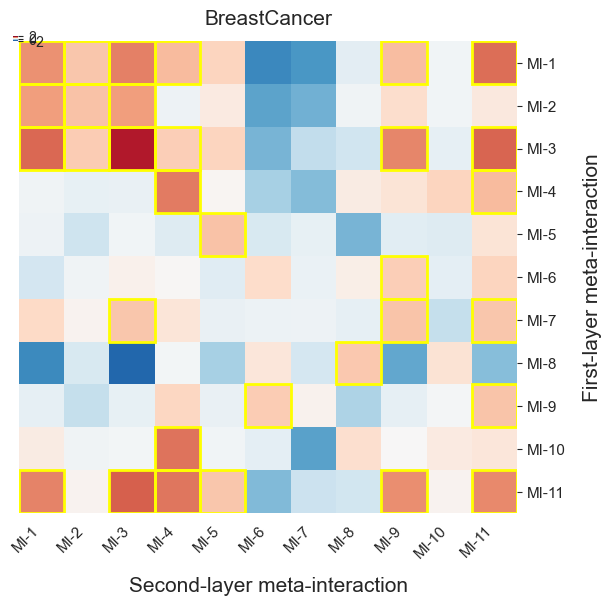

Saved heatmap: D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Heatmap_Zscore_Colocalization_Count_BreastCancer.png


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\2653409574.py:68: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  g.fig.tight_layout()


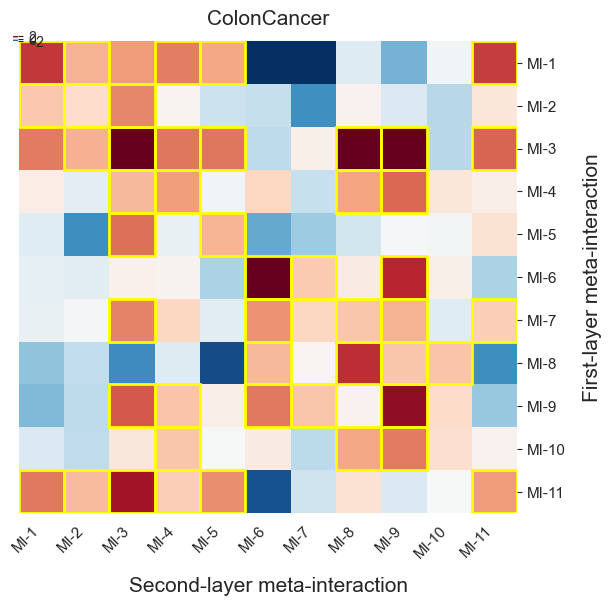

Saved heatmap: D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Heatmap_Zscore_Colocalization_Count_ColonCancer.png


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\2653409574.py:68: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  g.fig.tight_layout()


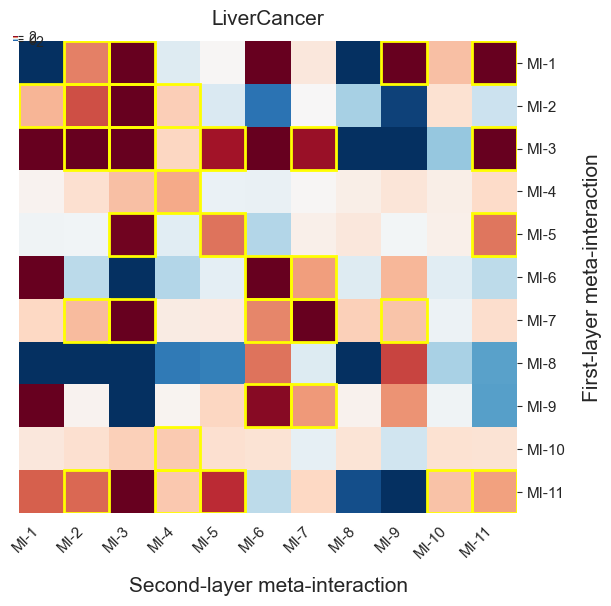

Saved heatmap: D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Heatmap_Zscore_Colocalization_Count_LiverCancer.png


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\2653409574.py:68: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  g.fig.tight_layout()


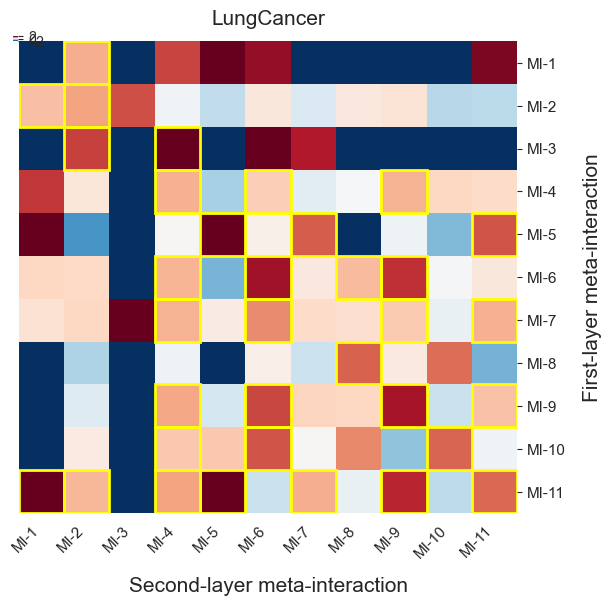

Saved heatmap: D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Heatmap_Zscore_Colocalization_Count_LungCancer.png


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\2653409574.py:68: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  g.fig.tight_layout()


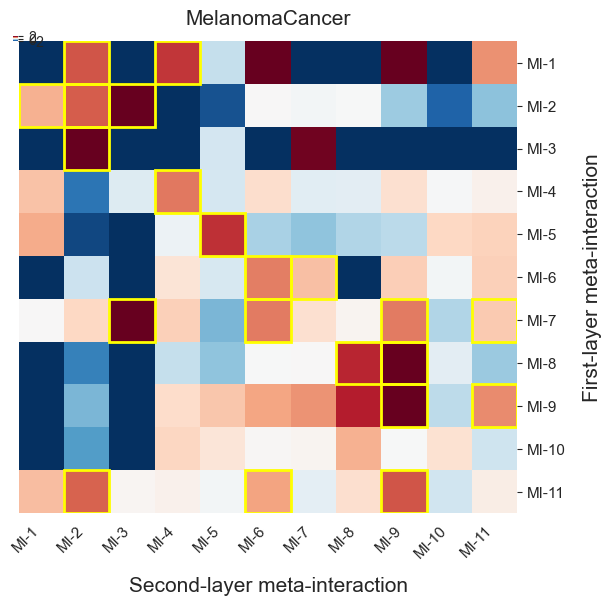

Saved heatmap: D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Heatmap_Zscore_Colocalization_Count_MelanomaCancer.png


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\2653409574.py:68: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  g.fig.tight_layout()


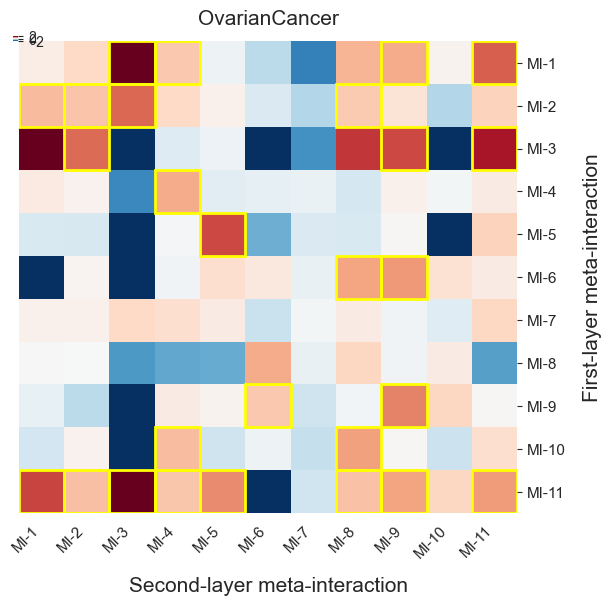

Saved heatmap: D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Heatmap_Zscore_Colocalization_Count_OvarianCancer.png


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\2653409574.py:68: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  g.fig.tight_layout()


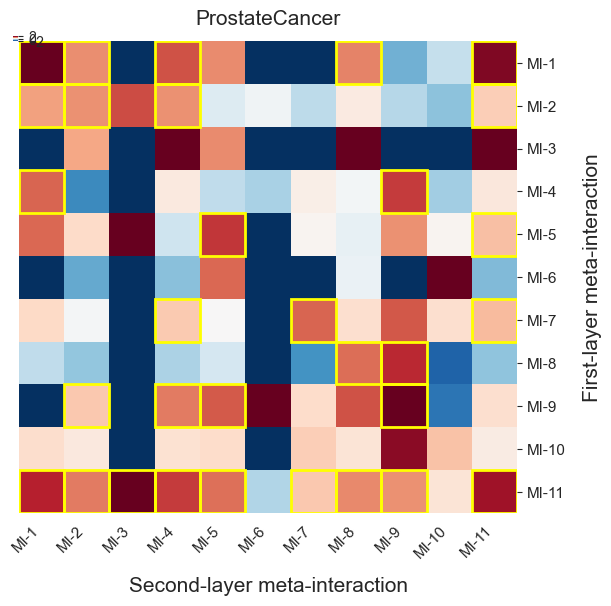

Saved heatmap: D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Heatmap_Zscore_Colocalization_Count_ProstateCancer.png


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\2653409574.py:68: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  g.fig.tight_layout()


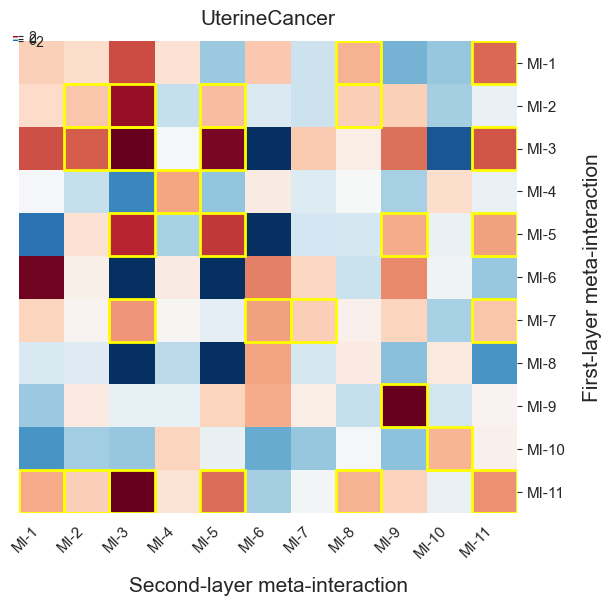

Saved heatmap: D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Heatmap_Zscore_Colocalization_Count_UterineCancer.png
Saved yellow-box count matrix:
D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//MI_MI_yellow_box_cancer_count.csv
Saved yellow-box cancer-type detail matrix:
D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//MI_MI_yellow_box_cancer_types.csv


,MI-1,MI-2,MI-3,MI-4,MI-5,MI-6,MI-7,MI-8,MI-9,MI-10,MI-11
MI-1,3,6,3,5,1,0,0,2,3,0,6
MI-2,7,7,6,2,1,0,0,2,0,0,1
MI-3,1,7,4,3,3,0,1,1,3,0,5
MI-4,1,0,1,7,0,1,0,1,3,0,1
MI-5,0,0,3,0,8,0,1,0,1,0,4
MI-6,0,0,0,1,0,4,3,2,4,0,0
MI-7,0,1,5,2,0,5,3,1,5,0,6
MI-8,0,0,0,0,0,1,0,5,3,1,0
MI-9,0,1,1,3,1,5,2,0,6,0,3
MI-10,0,0,0,5,0,1,0,2,1,2,0


In [12]:
# =========================================
# Fixed-order heatmaps of MI-MI colocalization Z-scores
# =========================================
heatmap_vmin = -2
heatmap_vmax = 2

def sanitize_filename(text):
    """Convert a label into a filesystem-safe filename fragment."""
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", str(text))

def plot_mi_colocalization_heatmap(zscore_df, pvalue_df, cancer_label, out_prefix,
                                   zscore_threshold, pvalue_threshold,
                                   vmin=-1, vmax=1):
    """Plot a fixed-order MI-MI colocalization heatmap without row/column clustering."""
    g = sns.clustermap(
        zscore_df,
        cmap="RdBu_r",
        center=0,
        vmin=vmin,
        vmax=vmax,
        figsize=(7, 6),
        square=False,
        row_cluster=False,
        col_cluster=False,
        dendrogram_ratio=(0.01, 0.01),
        cbar_pos=(0.92, 0.2, 0.02, 0.5),
    )

    # Hide unused dendrogram axes because clustering is disabled.
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)

    row_order = list(range(zscore_df.shape[0]))
    col_order = list(range(zscore_df.shape[1]))

    for i_new, i_old in enumerate(row_order):
        for j_new, j_old in enumerate(col_order):
            p_val = pvalue_df.iloc[i_old, j_old]
            z_val = zscore_df.iloc[i_old, j_old]
            if p_val < pvalue_threshold and z_val > np.log2(zscore_threshold):
                g.ax_heatmap.add_patch(
                    Rectangle(
                        (j_new, i_new),
                        1,
                        1,
                        fill=False,
                        edgecolor="yellow",
                        lw=2.0,
                    )
                )

    g.ax_heatmap.set_xlabel("Second-layer meta-interaction", fontsize=15, labelpad=12)
    g.ax_heatmap.set_ylabel("First-layer meta-interaction", fontsize=15, labelpad=12)
    g.ax_heatmap.set_title(f"{cancer_label}", fontsize=15, pad=12)

    g.ax_heatmap.set_xticklabels(
        g.ax_heatmap.get_xticklabels(),
        rotation=45,
        ha="right",
        fontsize=11,
    )
    g.ax_heatmap.set_yticklabels(
        g.ax_heatmap.get_yticklabels(),
        rotation=0,
        fontsize=11,
    )

    g.fig.tight_layout()
    g.fig.subplots_adjust(bottom=0.18, left=0.18, right=0.90)

    png_path = out_prefix + ".png"
    pdf_path = out_prefix + ".pdf"
    g.fig.savefig(png_path, dpi=300)
    g.fig.savefig(pdf_path, dpi=300)
    plt.show()
    plt.close(g.fig)

    print(f"Saved heatmap: {png_path}")


# ------------------------------------------------------------
# Cancer-type-specific heatmaps
# ------------------------------------------------------------
for cancer_type in cancertype_list:
    plot_mi_colocalization_heatmap(
        zscore_df=colocal_count_zscore_by_cancertype[cancer_type],
        pvalue_df=colocal_count_pvalue_by_cancertype[cancer_type],
        cancer_label=f"{cancer_type}",
        out_prefix=file_savepath_main + f"/Heatmap_Zscore_Colocalization_Count_{sanitize_filename(cancer_type)}",
        zscore_threshold=zscore_threshold,
        pvalue_threshold=pvalue_thresold,
        vmin=heatmap_vmin,
        vmax=heatmap_vmax,
    )


# ============================================================
# Count how many cancer types mark each MI-MI pair with yellow boxes
# ============================================================
def get_yellow_box_mask(zscore_df, pvalue_df, zscore_threshold, pvalue_threshold):
    """
    Return a boolean MI x MI mask indicating which entries would be highlighted
    with yellow boxes in the heatmap.
    """
    return (pvalue_df < pvalue_threshold) & (zscore_df > np.log2(zscore_threshold))


# Use the first cancer type as the reference MI order
reference_cancer = cancertype_list[0]
reference_index = colocal_count_zscore_by_cancertype[reference_cancer].index
reference_columns = colocal_count_zscore_by_cancertype[reference_cancer].columns

# Initialize count matrix
yellow_box_count_df = pd.DataFrame(
    0,
    index=reference_index,
    columns=reference_columns,
    dtype=int,
)

# Optional: record which cancer types support each MI-MI pair
yellow_box_cancer_list_df = pd.DataFrame(
    "",
    index=reference_index,
    columns=reference_columns,
    dtype=object,
)

for cancer_type in cancertype_list:
    zscore_df = colocal_count_zscore_by_cancertype[cancer_type].copy()
    pvalue_df = colocal_count_pvalue_by_cancertype[cancer_type].copy()

    # Align to the same MI order across cancer types
    zscore_df = zscore_df.loc[reference_index, reference_columns]
    pvalue_df = pvalue_df.loc[reference_index, reference_columns]

    yellow_mask = get_yellow_box_mask(
        zscore_df=zscore_df,
        pvalue_df=pvalue_df,
        zscore_threshold=zscore_threshold,
        pvalue_threshold=pvalue_thresold,
    )

    # Accumulate count
    yellow_box_count_df += yellow_mask.astype(int)

    # Optional: store supporting cancer types
    for i in reference_index:
        for j in reference_columns:
            if yellow_mask.loc[i, j]:
                if yellow_box_cancer_list_df.loc[i, j] == "":
                    yellow_box_cancer_list_df.loc[i, j] = cancer_type
                else:
                    yellow_box_cancer_list_df.loc[i, j] += f"; {cancer_type}"

# Save results
yellow_box_count_df.to_csv(
    file_savepath_main + "/MI_MI_yellow_box_cancer_count.csv"
)
yellow_box_cancer_list_df.to_csv(
    file_savepath_main + "/MI_MI_yellow_box_cancer_types.csv"
)

print("Saved yellow-box count matrix:")
print(file_savepath_main + "/MI_MI_yellow_box_cancer_count.csv")

print("Saved yellow-box cancer-type detail matrix:")
print(file_savepath_main + "/MI_MI_yellow_box_cancer_types.csv")

display(yellow_box_count_df)

## 6. Enriched Celltype Triple Summary and Visualization

This section summarizes cancer-type-specific cell-type triple enrichment within significant MI cascades.
For each cancer type, cell-type triple proportions are computed using only samples from that cancer type rather than pooling all cancers together.
The final heatmap displays only cancer-cell-related triples, and columns are organized as cancer-type-specific cell-type triples.


In [13]:
# ==============================================================
# 1. Initialize containers for cancer-type-specific results
# --------------------------------------------------------------
# For each cancer type, compute cell-type triple proportions only
# within that cancer type, using the significant MI cascades
# identified for that cancer type.
# ==============================================================
triplet_prop_by_cancertype_list = []
celltriple_index_sample_list = []


# ==============================================================
# 2. Loop over cancer types and their significant MI cascades
# ==============================================================
for cancer_type in cancertype_list:
    sample_indices_cur = cancertype_to_sample_indices[cancer_type]
    sig_pairs_cur = MI_colocal_summary_significant_by_cancertype.loc[
        MI_colocal_summary_significant_by_cancertype["CancerType"] == cancer_type
    ].reset_index(drop=True)

    print(f"Processing {cancer_type}: {len(sample_indices_cur)} samples, {sig_pairs_cur.shape[0]} significant MI cascades")

    if sig_pairs_cur.empty:
        continue

    for idx in range(sig_pairs_cur.shape[0]):
        MI_first = int(sig_pairs_cur.iloc[idx]["MI_first"])
        MI_second = int(sig_pairs_cur.iloc[idx]["MI_second"])
        MI_first_idx, MI_second_idx = MI_first - 1, MI_second - 1

        all_summary_tables = []
        celltriple_index_all = []

        # --------------------------------------------------------------
        # 2.1 Compute cell-type triples for each sample within this
        #     cancer type
        # --------------------------------------------------------------
        for sample_index in sample_indices_cur:
            F = Factor_envir_norm_list[sample_index]      # (E, d)
            A = hyper_edge_adj_list[sample_index]         # (E, E) sparse adjacency
            edge_index = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()
            adata_cur = adata_list[sample_index]
            celltypes = adata_cur.obs['celltype_final'].values[edge_index]
            F_cut = (F > MI_threshold).astype(int)

            rel_first = np.where(F_cut[:, MI_first_idx])[0]
            rel_second = np.where(F_cut[:, MI_second_idx])[0]
            if (len(rel_first) == 0) or (len(rel_second) == 0):
                continue

            A_sub = A[rel_first, :][:, rel_second].toarray()
            a_i, a_j = np.where(A_sub == 1)
            if len(a_i) == 0:
                continue

            paired_idx = np.vstack([rel_first[a_i], rel_second[a_j]]).T

            pair_first = edge_index[paired_idx[:, 0], :]
            pair_second = edge_index[paired_idx[:, 1], :]
            celltriple_index = np.hstack([pair_first, pair_second[:, 1][:, None]])
            celltriple_index_all.append(celltriple_index)

            triple_ct = np.asarray(adata_cur.obs['celltype_final'].values[celltriple_index])
            if triple_ct.shape[0] == 0:
                continue

            triple_label = (
                triple_ct[:, 0] + " -> " +
                triple_ct[:, 1] + " -> " +
                triple_ct[:, 2]
            )

            triple_counts = pd.Series(triple_label).value_counts().reset_index()
            triple_counts.columns = ["Celltype_triple", "Count"]
            if triple_counts.empty:
                continue

            parts = triple_counts["Celltype_triple"].str.split("->", expand=True)
            triple_counts["ctp_MI_first"] = parts[0].str.strip() + " -> " + parts[1].str.strip()
            triple_counts["ctp_MI_second"] = parts[1].str.strip() + " -> " + parts[2].str.strip()
            triple_counts["Sample"] = adata_cur.obs["SampleID"].unique()[0]
            triple_counts["CancerType"] = cancer_type
            triple_counts["MI_first"] = MI_first
            triple_counts["MI_second"] = MI_second

            # Within-sample proportion is kept for reference.
            triple_counts["prop_within_sample"] = triple_counts["Count"] / triple_counts["Count"].sum()

            def calc_ratio(row):
                ctp1, ctp2, cnt = row["ctp_MI_first"], row["ctp_MI_second"], row["Count"]
                ct1a, ct1b = ctp1.split(" -> ")
                ct2a, ct2b = ctp2.split(" -> ")
                edge_ct = celltypes
                r1 = np.sum((edge_ct[:, 0] == ct1a) & (edge_ct[:, 1] == ct1b))
                r2 = np.sum((edge_ct[:, 0] == ct2a) & (edge_ct[:, 1] == ct2b))
                denom = (float(r1) * float(r2)) / float(F_cut.shape[0])
                return float(cnt) / denom if denom > 0 else np.nan

            triple_counts["ratio"] = triple_counts.apply(calc_ratio, axis=1)
            all_summary_tables.append(triple_counts)

        celltriple_index_sample_list.append(
            {
                "CancerType": cancer_type,
                "MI_first": MI_first,
                "MI_second": MI_second,
                "celltriple_index_all": celltriple_index_all,
            }
        )

        if len(all_summary_tables) == 0:
            continue

        # --------------------------------------------------------------
        # 2.2 Aggregate only within the current cancer type
        # --------------------------------------------------------------
        combined = pd.concat(all_summary_tables, axis=0, ignore_index=True)
        total_count_cur = combined["Count"].sum()
        if total_count_cur == 0:
            continue

        prop_avg_cur = (
            combined.groupby("Celltype_triple")["Count"]
            .sum()
            .div(total_count_cur)
            .reset_index(name="prop_within_cancertype")
        )
        prop_avg_cur["CancerType"] = cancer_type
        prop_avg_cur["MI_first"] = MI_first
        prop_avg_cur["MI_second"] = MI_second
        triplet_prop_by_cancertype_list.append(prop_avg_cur)


# ==============================================================
# 3. Merge cancer-type-specific results and build the pivot table
# --------------------------------------------------------------
# Rows in the final heatmap should use the cross-cancer union of
# significant MI pairs, so the MI-cascade label here should not
# include cancer type.
# ==============================================================
if len(triplet_prop_by_cancertype_list) == 0:
    raise ValueError("No cancer-type-specific cell-type triple summaries were generated.")

triplet_prop_by_cancertype_merge = pd.concat(
    triplet_prop_by_cancertype_list,
    axis=0,
    ignore_index=True,
)

triplet_prop_by_cancertype_merge["MI cascade union"] = (
    "MI-" + triplet_prop_by_cancertype_merge["MI_first"].astype(str) +
    " -> MI-" + triplet_prop_by_cancertype_merge["MI_second"].astype(str)
)
triplet_prop_by_cancertype_merge["CancerType | Celltype Triple"] = (
    triplet_prop_by_cancertype_merge["CancerType"] + " | " +
    triplet_prop_by_cancertype_merge["Celltype_triple"]
)

# Keep only cancer-cell-related triples for visualization.
triplet_prop_cancercell = triplet_prop_by_cancertype_merge.loc[
    triplet_prop_by_cancertype_merge["Celltype_triple"].str.contains("cancercell", case=False, na=False)
].copy()

# Use the cross-cancer union of significant MI pairs as heatmap rows.
# Each cancer-type-specific triple contributes values only to the MI
# cascades that were significant in that same cancer type.
pivot_cancercell = triplet_prop_cancercell.pivot(
    index="CancerType | Celltype Triple",
    columns="MI cascade union",
    values="prop_within_cancertype"
).fillna(0)

prop_avg_by_cancertype_filter_merge_pivot_select = pivot_cancercell.loc[
    pivot_cancercell.max(axis=1) > 5e-2,
    :
].copy()

# Save the long table and the pivot table for downstream use.
triplet_prop_by_cancertype_merge.to_csv(
    file_savepath_main + "/Celltype_triple_prop_within_cancertype_long.csv",
    index=False,
)
prop_avg_by_cancertype_filter_merge_pivot_select.to_csv(
    file_savepath_main + "/Celltype_triple_prop_within_cancertype_cancercell_pivot_unionMIs.csv"
)

print("Cancer-type-specific triplet summary completed.")
print(f"Long table shape: {triplet_prop_by_cancertype_merge.shape}")
print(f"Cancer-cell pivot shape: {prop_avg_by_cancertype_filter_merge_pivot_select.shape}")


Processing BreastCancer: 20 samples, 32 significant MI cascades
Processing ColonCancer: 20 samples, 46 significant MI cascades
Processing LiverCancer: 20 samples, 32 significant MI cascades
Processing LungCancer: 20 samples, 34 significant MI cascades
Processing MelanomaCancer: 20 samples, 21 significant MI cascades
Processing OvarianCancer: 20 samples, 27 significant MI cascades
Processing ProstateCancer: 20 samples, 31 significant MI cascades
Processing UterineCancer: 20 samples, 27 significant MI cascades
Cancer-type-specific triplet summary completed.
Long table shape: (25571, 7)
Cancer-cell pivot shape: (269, 77)


In [14]:
import pandas as pd
import re


df = prop_avg_by_cancertype_filter_merge_pivot_select.copy()


def _split_display_label(label: str):
    text = str(label)
    if " | " in text:
        return text.split(" | ", 1)
    return "", text


def _parse_triple_from_display_label(label: str):
    _, triple = _split_display_label(label)
    parts = [p.strip() for p in triple.split("->")]
    if len(parts) < 3:
        parts = parts + [""] * (3 - len(parts))
    elif len(parts) > 3:
        parts = parts[:3]
    return parts


def _is_cancercell(ct: str):
    return "cancercell" in str(ct).lower()


pair_priority = {(0, 1): 0, (1, 2): 1, (0, 2): 2}
cancertype_order = {ct: i for i, ct in enumerate(cancertype_list)}


def sort_key_triple(display_label: str):
    cancer_type, _ = _split_display_label(display_label)
    cts = _parse_triple_from_display_label(display_label)
    flags = [_is_cancercell(x) for x in cts]
    k = sum(flags)

    if k == 1:
        i = flags.index(True)
        if i == 0:
            pos_rank = pair_priority[(0, 1)]
        elif i == 1:
            pos_rank = pair_priority[(0, 1)]
        else:
            pos_rank = pair_priority[(1, 2)]
    else:
        pos_rank = 9

    return (cancertype_order.get(cancer_type, 999), -k, pos_rank, str(display_label))


def sort_key_cascade(label: str):
    cancer_type, cascade = _split_display_label(label)
    mi_numbers = re.findall(r"MI-(\d+)", cascade)
    if len(mi_numbers) >= 2:
        mi_first, mi_second = map(int, mi_numbers[:2])
    else:
        mi_first, mi_second = 999, 999
    return (cancertype_order.get(cancer_type, 999), mi_first, mi_second, str(label))


row_order = sorted(df.index, key=sort_key_triple)
col_order = sorted(df.columns, key=sort_key_cascade)

df_sorted = df.loc[row_order, col_order].copy()
prop_avg_by_cancertype_filter_merge_pivot_select = df_sorted

df_sorted



MI cascade union,MI-1 -> MI-1,MI-1 -> MI-2,MI-1 -> MI-3,MI-1 -> MI-4,MI-1 -> MI-5,MI-1 -> MI-8,MI-1 -> MI-9,MI-1 -> MI-11,MI-2 -> MI-1,MI-2 -> MI-2,...,MI-11 -> MI-2,MI-11 -> MI-3,MI-11 -> MI-4,MI-11 -> MI-5,MI-11 -> MI-6,MI-11 -> MI-7,MI-11 -> MI-8,MI-11 -> MI-9,MI-11 -> MI-10,MI-11 -> MI-11
CancerType | Celltype Triple,,,,,,,,,,,,,,,,,,,,,
BreastCancer | Breast-cancercell -> Breast-cancercell -> Breast-cancercell,0.905935,0.864895,0.779351,0.000000,0.0,0.000000,0.176420,0.105917,0.899616,0.817083,...,0.000000,0.038407,0.000000,0.000259,0.0,0.0,0.000000,0.008671,0.0,0.002255
BreastCancer | Breast-cancercell -> Breast-cancercell -> CD8_T/NK,0.006476,0.021004,0.030340,0.000000,0.0,0.000000,0.021764,0.095972,0.007086,0.023436,...,0.000000,0.001581,0.000000,0.001295,0.0,0.0,0.000000,0.000867,0.0,0.001127
BreastCancer | Breast-cancercell -> Breast-cancercell -> Fibroblast,0.008539,0.008847,0.014373,0.001873,0.0,0.000000,0.435334,0.024863,0.007831,0.008525,...,0.000000,0.000790,0.000000,0.001554,0.0,0.0,0.000000,0.015175,0.0,0.001127
BreastCancer | Breast-cancercell -> Breast-cancercell -> Macrophage,0.008607,0.017566,0.041240,0.000000,0.0,0.000000,0.166391,0.011437,0.008421,0.017395,...,0.000000,0.003161,0.000000,0.008807,0.0,0.0,0.000000,0.005419,0.0,0.000000
BreastCancer | Breast-cancercell -> CD8_T/NK -> Breast-cancercell,0.004836,0.009156,0.008559,0.015605,0.0,0.000000,0.000451,0.036300,0.012348,0.031165,...,0.000000,0.020231,0.001639,0.002202,0.0,0.0,0.000000,0.000434,0.0,0.014092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UterineCancer | Uterine-cancercell -> Macrophage -> Macrophage,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000606,...,0.000000,0.000000,0.000000,0.002090,0.0,0.0,0.000000,0.000000,0.0,0.000125
UterineCancer | Fibroblast -> Fibroblast -> Uterine-cancercell,0.000000,0.000000,0.000000,0.000000,0.0,0.044248,0.000000,0.051429,0.000000,0.000042,...,0.001381,0.031847,0.000000,0.000000,0.0,0.0,0.101796,0.000000,0.0,0.054206
UterineCancer | Macrophage -> Endothelial -> Uterine-cancercell,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000002,...,0.000191,0.000000,0.000000,0.000000,0.0,0.0,0.003743,0.000000,0.0,0.005607


### Cancer-type-specific heatmap of cancer-cell-related triple enrichment


In [15]:
def plot_heatmap(data, title, xlabel, ylabel, filename, highlight_cancercell=False,
                 row_cluster=False, col_cluster=False, vmin=0, vmax=1):
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['mathtext.fontset'] = 'dejavuserif'
    plt.rcParams['font.family'] = 'arial'

    # The heatmap is drawn on data.T so that columns correspond to
    # cancer-type-specific cell-type triples.
    fig_w = max(8, 0.28 * data.shape[0] + 4)
    fig_h = max(6, 0.28 * data.shape[1] + 3)

    g = sns.clustermap(
        data.T,
        cmap="Reds",
        vmin=vmin,
        vmax=vmax,
        figsize=(fig_w, fig_h),
        square=False,
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        dendrogram_ratio=(0.08, 0.08),
        cbar_pos=(0.92, 0.2, 0.02, 0.5),
        linecolor="lightgrey",
        linewidth=0.4,
    )

    if not row_cluster:
        g.ax_row_dendrogram.set_visible(False)
    if not col_cluster:
        g.ax_col_dendrogram.set_visible(False)

    g.ax_heatmap.set_xlabel(xlabel, fontsize=14)
    g.ax_heatmap.set_ylabel(ylabel, fontsize=14)
    g.ax_heatmap.set_title(title, fontsize=16, pad=12)

    xticklabels = g.ax_heatmap.get_xticklabels()
    for label in xticklabels:
        label_text = label.get_text()
        label.set_color("red" if ("cancercell" in label_text.lower() and highlight_cancercell) else "black")

    g.ax_heatmap.set_xticklabels(xticklabels, rotation=75, ha="right", fontsize=9)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)

    g.fig.tight_layout()
    g.fig.subplots_adjust(bottom=0.30, left=0.25, right=0.90)
    g.fig.savefig(file_savepath_main + "/" + filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(g.fig)
    print(f"✅ Saved: {filename}")



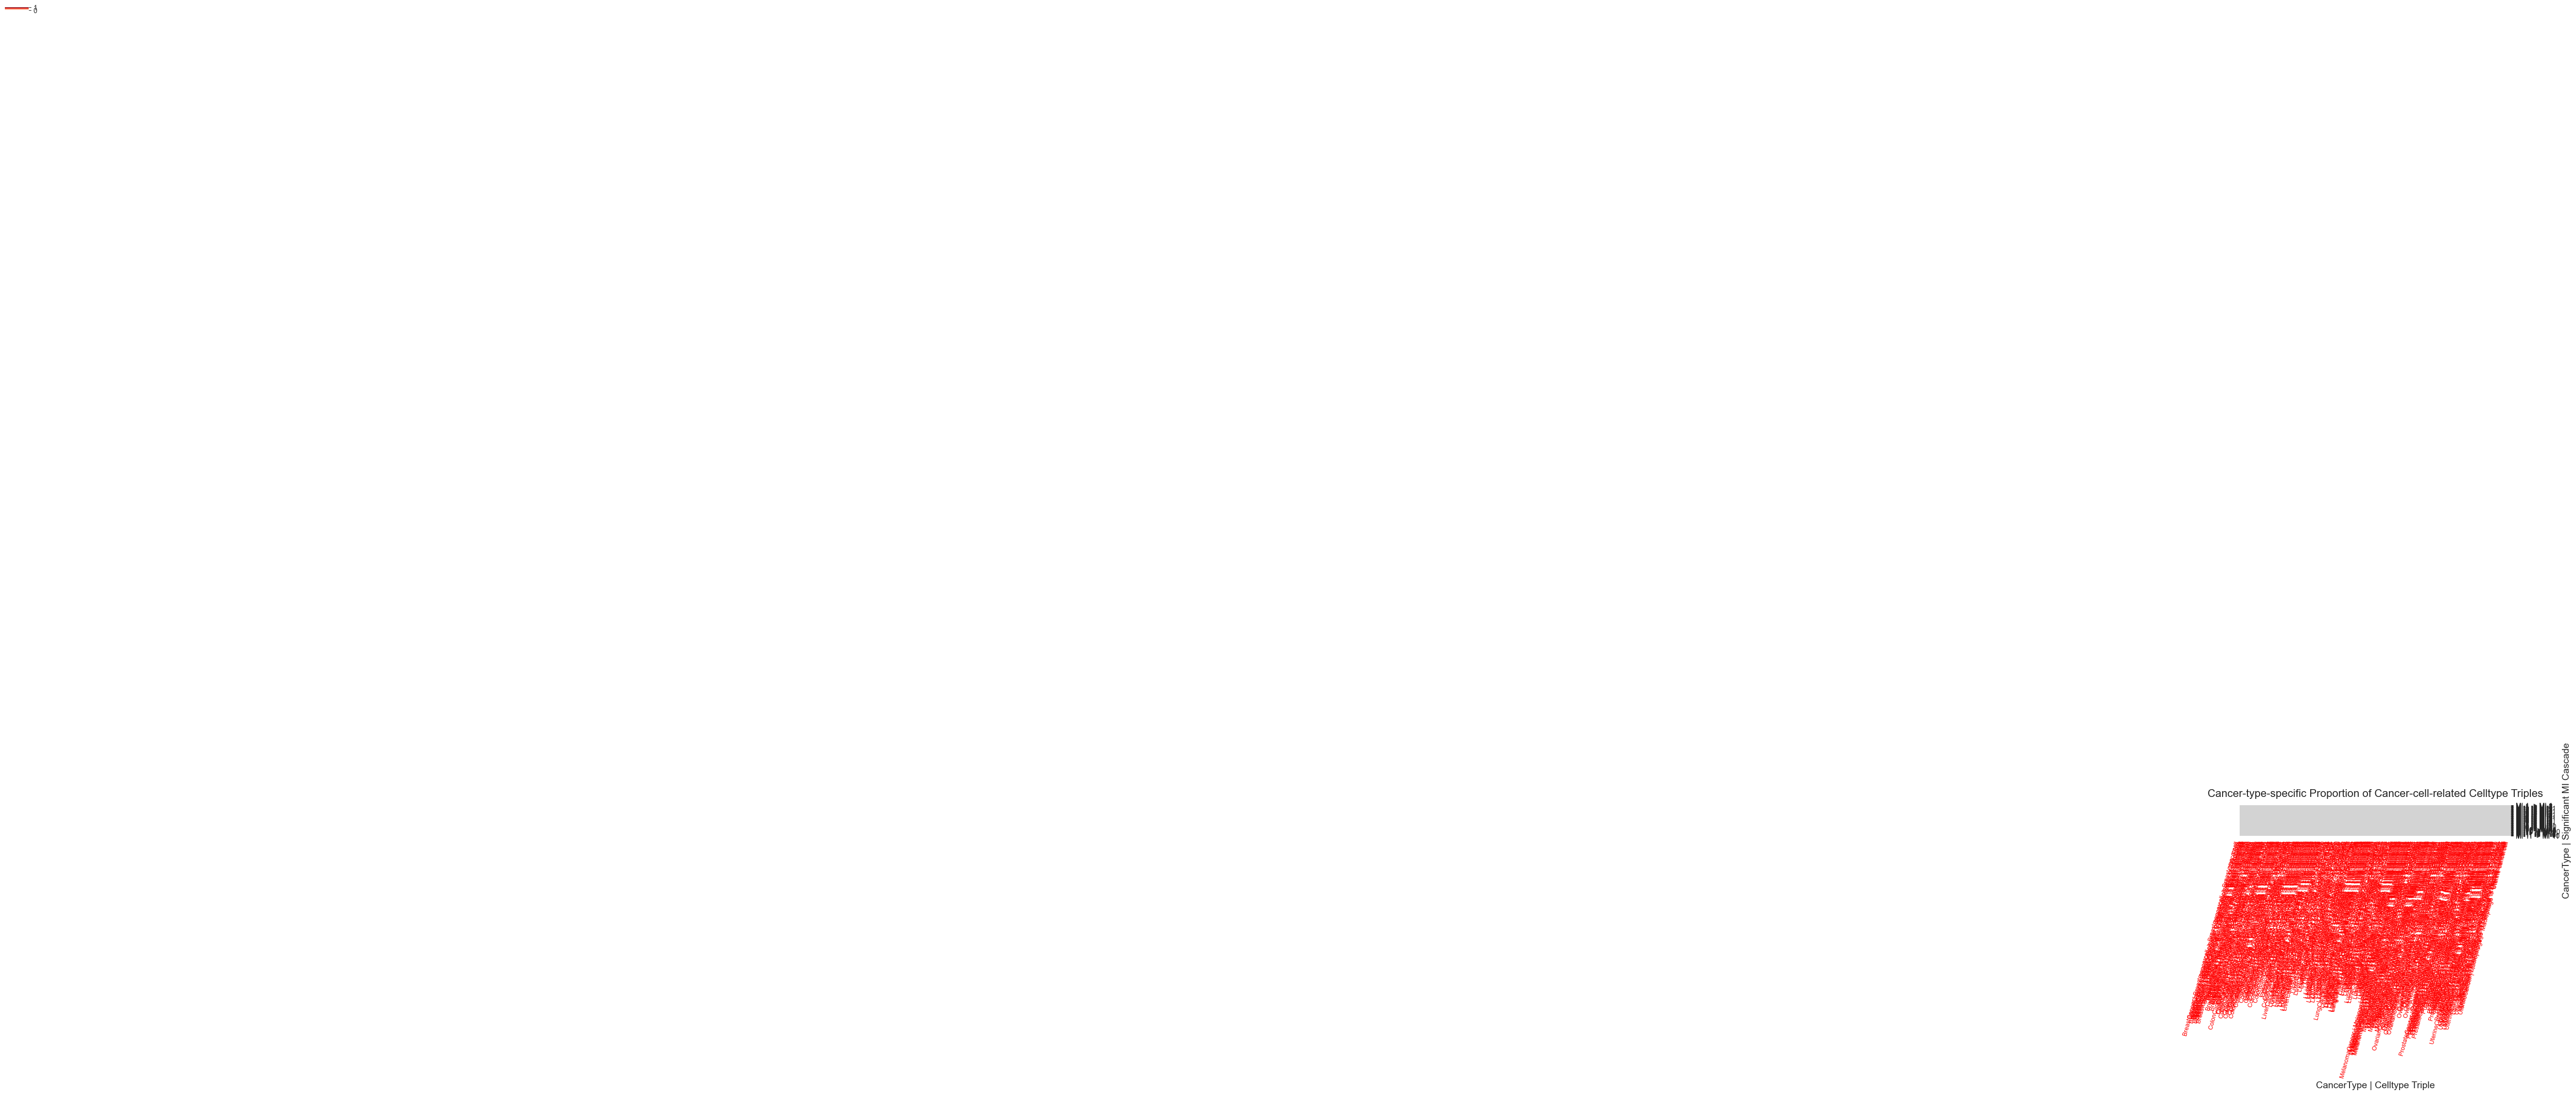

✅ Saved: Heatmap_prop_Celltype_triple_within_cancertype_cancercell.pdf


In [16]:
# ==============================================================
# Heatmap of cancer-cell-related cell-type triples only
# --------------------------------------------------------------
# Proportions are computed within each cancer type, and both rows
# and columns retain cancer-type-specific identities.
# ============================================================== 
plot_heatmap(
    prop_avg_by_cancertype_filter_merge_pivot_select,
    title="Cancer-type-specific Proportion of Cancer-cell-related Celltype Triples",
    xlabel="CancerType | Celltype Triple",
    ylabel="CancerType | Significant MI Cascade",
    filename="Heatmap_prop_Celltype_triple_within_cancertype_cancercell.pdf",
    highlight_cancercell=True,
    row_cluster=False,
    col_cluster=False,
    vmin=0, vmax=1
)



In [17]:
# ==============================================================
# Directly get per-cancer-type prop results for MI-11 -> MI-2
# ==============================================================

target_MI_first = 11
target_MI_second = 2
target_pair_label = f"MI-{target_MI_first} -> MI-{target_MI_second}"

# Record whether MI-11 -> MI-2 is significant in each cancer type
sig_lookup = set(
    zip(
        MI_colocal_summary_significant_by_cancertype["CancerType"].astype(str),
        MI_colocal_summary_significant_by_cancertype["MI_first"].astype(int),
        MI_colocal_summary_significant_by_cancertype["MI_second"].astype(int),
    )
)

prop_rows = []

for cancer_type in cancertype_list:
    sample_indices_cur = cancertype_to_sample_indices[cancer_type]
    MI_first_idx = target_MI_first - 1
    MI_second_idx = target_MI_second - 1

    triple_counts_all_samples_cur = []

    for sample_index in sample_indices_cur:
        F = Factor_envir_norm_list[sample_index]                      # (E, d)
        A = hyper_edge_adj_list[sample_index]                        # (E, E) sparse adjacency
        edge_index = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()
        adata_cur = adata_list[sample_index]

        # celltypes_edge = adata_cur.obs["celltype_final"].values[edge_index]   # (E, 2)
        celltype_values = adata_cur.obs["celltype_final"].astype(str).to_numpy()
        celltypes_edge = celltype_values[edge_index]
        F_cut = (F > MI_threshold).astype(int)

        rel_first = np.where(F_cut[:, MI_first_idx])[0]
        rel_second = np.where(F_cut[:, MI_second_idx])[0]

        if (len(rel_first) == 0) or (len(rel_second) == 0):
            continue

        A_sub = A[rel_first, :][:, rel_second]
        a_i, a_j = A_sub.nonzero()

        if len(a_i) == 0:
            continue

        paired_idx = np.vstack([rel_first[a_i], rel_second[a_j]]).T

        pair_first = edge_index[paired_idx[:, 0], :]
        pair_second = edge_index[paired_idx[:, 1], :]
        celltriple_index = np.hstack([pair_first, pair_second[:, 1][:, None]])
        
        celltype_values = adata_cur.obs["celltype_final"].astype(str).to_numpy()
        triple_ct = celltype_values[celltriple_index]
        
        triple_label = np.array([
            f"{a} -> {b} -> {c}"
            for a, b, c in triple_ct
        ], dtype=object)

        triple_counts = pd.Series(triple_label).value_counts().reset_index()
        triple_counts.columns = ["Celltype_triple", "Count"]

        if triple_counts.shape[0] == 0:
            continue

        triple_counts["Sample"] = adata_cur.obs["SampleID"].unique()[0]
        triple_counts_all_samples_cur.append(triple_counts)

    # If this MI pair does not appear in this cancer type, fill with empty table
    if len(triple_counts_all_samples_cur) == 0:
        continue

    combined_cur = pd.concat(triple_counts_all_samples_cur, axis=0)

    prop_cur = (
        combined_cur.groupby("Celltype_triple", as_index=False)["Count"]
        .sum()
        .sort_values("Count", ascending=False)
        .reset_index(drop=True)
    )

    total_count_cur = prop_cur["Count"].sum()
    prop_cur["prop_within_cancertype"] = prop_cur["Count"] / total_count_cur

    prop_cur["CancerType"] = cancer_type
    prop_cur["MI_first"] = target_MI_first
    prop_cur["MI_second"] = target_MI_second
    prop_cur["MI cascade union"] = target_pair_label
    prop_cur["CancerType | Celltype Triple"] = (
        prop_cur["CancerType"] + " | " + prop_cur["Celltype_triple"]
    )

    is_sig_cur = (cancer_type, target_MI_first, target_MI_second) in sig_lookup
    prop_cur["is_significant_in_this_cancertype"] = is_sig_cur

    # This is the value that matches the final union-row heatmap logic:
    # keep the proportion only if this MI pair is significant in this cancer type,
    # otherwise set it to 0.
    prop_cur["prop_for_union_heatmap"] = np.where(
        prop_cur["is_significant_in_this_cancertype"],
        prop_cur["prop_within_cancertype"],
        0.0
    )

    prop_rows.append(prop_cur)

# --------------------------------------------------------------
# Merge results
# --------------------------------------------------------------
prop_MI11_MI2_by_cancertype = pd.concat(prop_rows, axis=0).reset_index(drop=True)

# All triplets
# display(prop_MI11_MI2_by_cancertype.head(20))

# --------------------------------------------------------------
# Cancer-cell-related triplets only
# --------------------------------------------------------------
prop_MI11_MI2_by_cancertype_cancercell = prop_MI11_MI2_by_cancertype.loc[
    prop_MI11_MI2_by_cancertype["Celltype_triple"].str.contains("cancercell", case=False, na=False)
].copy()

# Sort by the real within-cancer-type proportion
prop_MI11_MI2_by_cancertype_cancercell = prop_MI11_MI2_by_cancertype_cancercell.sort_values(
    ["CancerType", "prop_within_cancertype"],
    ascending=[True, False]
).reset_index(drop=True)

# display(prop_MI11_MI2_by_cancertype_cancercell)


In [18]:
##order the row of prop_MI11_MI2_by_cancertype_cancercell by "prop_within_cancertype" in descending order
prop_MI11_MI2_by_cancertype_cancercell = prop_MI11_MI2_by_cancertype_cancercell.sort_values(
    ["prop_within_cancertype"],
    ascending=[ False]
).reset_index(drop=True)
prop_MI11_MI2_by_cancertype_cancercell

,Celltype_triple,Count,prop_within_cancertype,CancerType,MI_first,MI_second,MI cascade union,CancerType | Celltype Triple,is_significant_in_this_cancertype,prop_for_union_heatmap
0,Fibroblast -> Ovarian-cancercell -> Ovarian-ca...,3312,0.573010,OvarianCancer,11,2,MI-11 -> MI-2,OvarianCancer | Fibroblast -> Ovarian-cancerce...,True,0.573010
1,Fibroblast -> Prostate-cancercell -> Prostate-...,3528,0.560979,ProstateCancer,11,2,MI-11 -> MI-2,ProstateCancer | Fibroblast -> Prostate-cancer...,True,0.560979
2,Fibroblast -> Breast-cancercell -> Breast-canc...,2000,0.406421,BreastCancer,11,2,MI-11 -> MI-2,BreastCancer | Fibroblast -> Breast-cancercell...,False,0.000000
3,Fibroblast -> Liver-cancercell -> Liver-cancer...,75,0.378788,LiverCancer,11,2,MI-11 -> MI-2,LiverCancer | Fibroblast -> Liver-cancercell -...,True,0.378788
4,Fibroblast -> Colon-cancercell -> Colon-cancer...,9935,0.286766,ColonCancer,11,2,MI-11 -> MI-2,ColonCancer | Fibroblast -> Colon-cancercell -...,True,0.286766
...,...,...,...,...,...,...,...,...,...,...
633,low_exp -> Colon-cancercell -> Macrophage,1,0.000029,ColonCancer,11,2,MI-11 -> MI-2,ColonCancer | low_exp -> Colon-cancercell -> M...,True,0.000029
634,Macrophage -> Colon-cancercell -> low_exp,1,0.000029,ColonCancer,11,2,MI-11 -> MI-2,ColonCancer | Macrophage -> Colon-cancercell -...,True,0.000029
635,Treg -> Colon-cancercell -> low_exp,1,0.000029,ColonCancer,11,2,MI-11 -> MI-2,ColonCancer | Treg -> Colon-cancercell -> low_exp,True,0.000029
636,Treg -> Fibroblast -> Colon-cancercell,1,0.000029,ColonCancer,11,2,MI-11 -> MI-2,ColonCancer | Treg -> Fibroblast -> Colon-canc...,True,0.000029


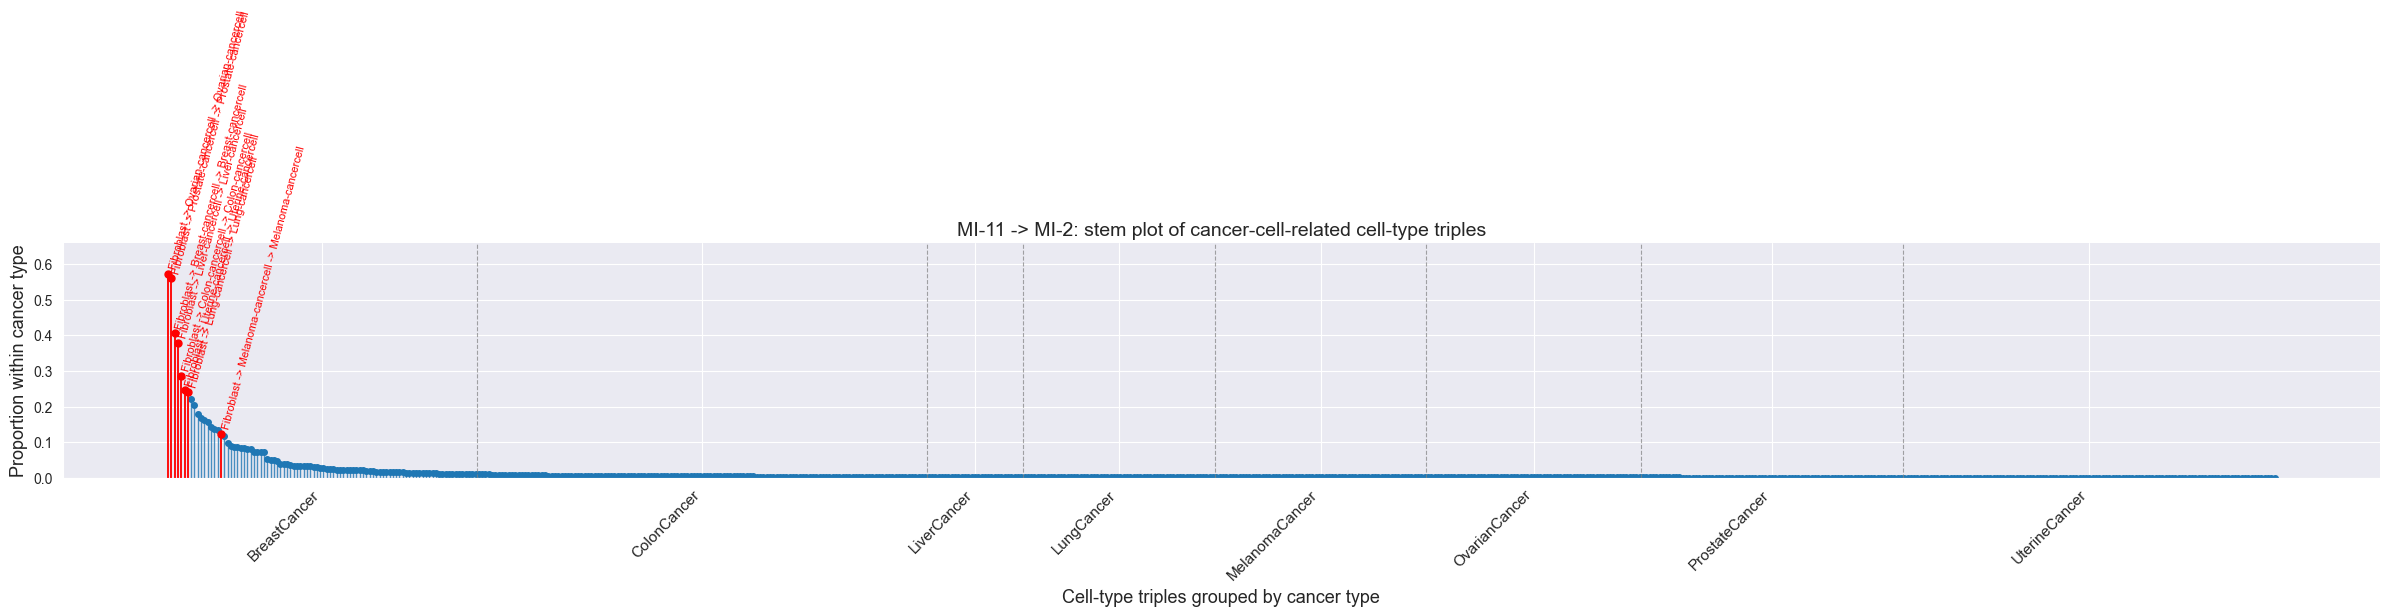

In [19]:
# ==============================================================
# Stem plot of prop_within_cancertype for MI-11 -> MI-2
# Highlight: Fibroblast -> XXX-cancercell -> XXX-cancercell
# ==============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# Copy and sort data
# --------------------------------------------------------------
plot_df = prop_MI11_MI2_by_cancertype_cancercell.copy()

plot_df = plot_df.sort_values(
    ["prop_within_cancertype"],
    ascending=[False]
).reset_index(drop=True)

# --------------------------------------------------------------
# Define the highlight pattern:
# Fibroblast -> XXX-cancercell -> XXX-cancercell
# where the 2nd and 3rd terms must be identical
# --------------------------------------------------------------
def is_fibro_to_same_cancercell_twice(triple):
    if pd.isna(triple):
        return False
    triple = str(triple).strip()
    m = re.fullmatch(r"Fibroblast -> (.+-cancercell) -> (.+-cancercell)", triple)
    if m is None:
        return False
    return m.group(1) == m.group(2)

plot_df["highlight_red"] = plot_df["Celltype_triple"].apply(is_fibro_to_same_cancercell_twice)

# --------------------------------------------------------------
# X positions
# --------------------------------------------------------------
plot_df["x"] = np.arange(len(plot_df))

# --------------------------------------------------------------
# Cancer-type boundaries for visual separation
# --------------------------------------------------------------
group_sizes = plot_df.groupby("CancerType").size()
group_names = group_sizes.index.tolist()

boundary_positions = []
group_centers = []
start = 0
for n in group_sizes.values:
    end = start + n
    group_centers.append((start + end - 1) / 2)
    boundary_positions.append(end - 0.5)
    start = end

# --------------------------------------------------------------
# Plot
# --------------------------------------------------------------
plt.close("all")
fig, ax = plt.subplots(figsize=(24, 6))

# Non-highlighted points
df_black = plot_df.loc[~plot_df["highlight_red"]].copy()
markerline1, stemlines1, baseline1 = ax.stem(
    df_black["x"],
    df_black["prop_within_cancertype"],
    linefmt="-",
    markerfmt="o",
    basefmt=" ",
)
plt.setp(stemlines1, linewidth=1.0, alpha=0.8)
plt.setp(markerline1, markersize=4)

# Highlighted red points
df_red = plot_df.loc[plot_df["highlight_red"]].copy()
markerline2, stemlines2, baseline2 = ax.stem(
    df_red["x"],
    df_red["prop_within_cancertype"],
    linefmt="-",
    markerfmt="o",
    basefmt=" ",
)
plt.setp(stemlines2, linewidth=1.4, alpha=0.95, color="red")
plt.setp(markerline2, markersize=5, color="red", markerfacecolor="red", markeredgecolor="red")

# --------------------------------------------------------------
# Add cancer-type separators
# --------------------------------------------------------------
for b in boundary_positions[:-1]:
    ax.axvline(b, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)

# --------------------------------------------------------------
# X-axis: show cancer type at group centers
# --------------------------------------------------------------
ax.set_xticks(group_centers)
ax.set_xticklabels(group_names, rotation=45, ha="right", fontsize=11)

# --------------------------------------------------------------
# Labels and title
# --------------------------------------------------------------
ax.set_ylabel("Proportion within cancer type", fontsize=13)
ax.set_xlabel("Cell-type triples grouped by cancer type", fontsize=13)
ax.set_title("MI-11 -> MI-2: stem plot of cancer-cell-related cell-type triples", fontsize=14)

# --------------------------------------------------------------
# Optional: annotate highlighted red points
# --------------------------------------------------------------
for _, row in df_red.iterrows():
    ax.text(
        row["x"],
        row["prop_within_cancertype"] + 0.01,
        row["Celltype_triple"],
        rotation=75,
        ha="left",
        va="bottom",
        fontsize=8,
        color="red"
    )

# --------------------------------------------------------------
# Style
# --------------------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, plot_df["prop_within_cancertype"].max() * 1.15)

plt.tight_layout()

# Save if needed
plt.savefig(
    file_savepath_main + "/Stemplot_MI11_to_MI2_prop_within_cancertype_cancercell.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    file_savepath_main + "/Stemplot_MI11_to_MI2_prop_within_cancertype_cancercell.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. In-situ Visualization of MI Cascades of interest (cell1-[MI-i]>cell2-[MI-j]>cell3)

### Specify the upstream and downstream MI of interest, and the cell-type triple

In [20]:
# ==============================================================
# 7. In-situ Visualization of MI Cascades of interest
# --------------------------------------------------------------
# This version iterates over ALL cancer types rather than a
# single cancer type.
# ==============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------------------
# User settings
# --------------------------------------------------------------
MI_first_of_interest = 11
MI_second_of_interest = 2

# Use a generic template. It will be resolved separately within
# each cancer type, e.g.
#   Fibroblast -> cancercell -> cancercell
# becomes
#   Fibroblast -> Ovarian-cancercell -> Ovarian-cancercell
# in OvarianCancer
celltype_triple_of_interest = "Fibroblast -> cancercell -> cancercell"

# Visualization threshold
MI_threshold_show = 0.5
# MI_threshold_show = MI_threshold


# --------------------------------------------------------------
# Helper functions
# --------------------------------------------------------------
def safe_filename(name: str) -> str:
    """Replace invalid filename characters."""
    return re.sub(r'[\\/:*?"<>|]', "_", str(name).replace(" -> ", "-"))


def cancer_type_to_cancercell_label(cancer_type):
    """
    Convert cancer type name to its corresponding cancer-cell label.
    Example:
        OvarianCancer -> Ovarian-cancercell
        ColonCancer   -> Colon-cancercell
    """
    cancer_type = str(cancer_type)
    if cancer_type.endswith("Cancer"):
        return cancer_type.replace("Cancer", "") + "-cancercell"
    return cancer_type + "-cancercell"


def resolve_triple_for_cancertype(celltype_triple, cancer_type):
    """
    Replace generic 'cancercell' tokens with the cancer-type-
    specific cancer-cell label.
    """
    cancer_cell_label = cancer_type_to_cancercell_label(cancer_type)
    parts = [x.strip() for x in str(celltype_triple).split("->")]

    if len(parts) != 3:
        raise ValueError(
            "celltype_triple_of_interest must have exactly 3 parts, "
            "for example 'Fibroblast -> cancercell -> cancercell'."
        )

    resolved_parts = [
        cancer_cell_label if p.lower() == "cancercell" else p
        for p in parts
    ]
    return " -> ".join(resolved_parts)


def plot_high_order_MI(
    spatial,
    celltypes,
    edge_first,
    edge_second,
    classes,
    color_map,
    sample_name,
    cancer_type,
    ct1,
    ct2,
    ct3,
    MI_first_id,
    MI_second_id,
    save_dir,
    triple_name="celltriple"
):
    """Plot spatial MI cascade for (ct1 -> ct2 -> ct3) within one sample."""
    plt.style.use("seaborn-v0_8-white")
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_facecolor("white")
    ax.grid(False)

    # Plot cells
    for cls in classes:
        idx = (celltypes == cls)
        if np.any(idx):
            ax.scatter(
                spatial[idx, 0],
                spatial[idx, 1],
                s=3,
                c=color_map.get(cls, "lightgrey"),
                label=cls,
                alpha=0.55,
                edgecolors="none"
            )

    # Plot first-layer MI edges
    for sender, receiver in edge_first:
        x0, y0 = spatial[sender]
        x1, y1 = spatial[receiver]
        ax.arrow(
            x0, y0, x1 - x0, y1 - y0,
            length_includes_head=True,
            lw=0.45,
            head_width=3,
            head_length=3,
            fc="#C71E64",
            ec="#C71E64",
            alpha=0.85
        )

    # Plot second-layer MI edges
    for sender, receiver in edge_second:
        x0, y0 = spatial[sender]
        x1, y1 = spatial[receiver]
        ax.arrow(
            x0, y0, x1 - x0, y1 - y0,
            length_includes_head=True,
            lw=0.45,
            head_width=3,
            head_length=3,
            fc="#4D2D8C",
            ec="#4D2D8C",
            alpha=0.85
        )

    ax.invert_yaxis()
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(
        f"{cancer_type}\n{ct1} -> {ct2} -> {ct3}\n(MI-{MI_first_id} -> MI-{MI_second_id})",
        fontsize=12
    )

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        markerscale=3,
        frameon=False
    )

    plt.tight_layout()

    out_dir = os.path.join(save_dir, "Insitu_High_order_MI_AllCancerTypes")
    os.makedirs(out_dir, exist_ok=True)

    triple_safe = safe_filename(triple_name)
    base = f"{cancer_type}_{sample_name}_{triple_safe}_MI-{MI_first_id}_MI-{MI_second_id}"

    fig.savefig(
        os.path.join(out_dir, base + ".pdf"),
        dpi=600,
        facecolor="white",
        bbox_inches="tight"
    )
    fig.savefig(
        os.path.join(out_dir, base + ".png"),
        dpi=300,
        facecolor="white",
        bbox_inches="tight"
    )
    # plt.show()
    plt.close(fig)


# --------------------------------------------------------------
# Define plotting order and colors
# --------------------------------------------------------------
classes = [
    "B cell", "CD4_T", "CD8_T/NK", "DC", "Endothelial", "Fibroblast",
    "Macrophage", "Mast cell", "Treg", "low_exp",
    "Breast-cancercell", "Colon-cancercell", "Ovarian-cancercell",
    "Prostate-cancercell", "Uterine-cancercell", "Lung-cancercell",
    "Liver-cancercell", "Melanoma-cancercell"
]

color_map = {
    "B cell": "#8894F1",
    "CD4_T": "#FF259E",
    "CD8_T/NK": "#FF52DB",
    "DC": "#2C5E1A",
    "Macrophage": "#74650F",
    "Mast cell": "#7228B8",
    "Treg": "#DE0878",
    "Endothelial": "#029991",
    "Fibroblast": "#944E13",
    "low_exp": "#BBC58F",
    "Breast-cancercell": "#7F3480",
    "Colon-cancercell": "#F7B2EF",
    "Ovarian-cancercell": "#DD0303",
    "Prostate-cancercell": "#028DCE",
    "Uterine-cancercell": "#FAB12F",
    "Lung-cancercell": "#B37166",
    "Liver-cancercell": "#FF8B6C",
    "Melanoma-cancercell": "#009D4E",
}


# --------------------------------------------------------------
# Main loop across ALL cancer types
# --------------------------------------------------------------
MI_first_index = int(MI_first_of_interest) - 1
MI_second_index = int(MI_second_of_interest) - 1

cascade_count_summary = []
cascade_sig_summary = []

for cancer_type_cur in cancertype_list:
    print("============================================================")
    print(f"Processing cancer type: {cancer_type_cur}")

    # Resolve the cancer-type-specific triple
    triple_resolved_cur = resolve_triple_for_cancertype(
        celltype_triple_of_interest,
        cancer_type_cur
    )
    ct1_cur, ct2_cur, ct3_cur = [x.strip() for x in triple_resolved_cur.split("->")]

    # Check significance in the current cancer type
    sig_match_cur = MI_colocal_summary_significant_by_cancertype.loc[
        (MI_colocal_summary_significant_by_cancertype["CancerType"] == cancer_type_cur) &
        (MI_colocal_summary_significant_by_cancertype["MI_first"].astype(int) == MI_first_of_interest) &
        (MI_colocal_summary_significant_by_cancertype["MI_second"].astype(int) == MI_second_of_interest)
    ].copy()

    is_sig_cur = sig_match_cur.shape[0] > 0

    cascade_sig_summary.append({
        "CancerType": cancer_type_cur,
        "MI_first": MI_first_of_interest,
        "MI_second": MI_second_of_interest,
        "Celltype_triple_template": celltype_triple_of_interest,
        "Celltype_triple_resolved": triple_resolved_cur,
        "Is_significant_in_this_cancertype": is_sig_cur
    })

    if is_sig_cur:
        print(
            f"Significant in {cancer_type_cur}: "
            f"MI-{MI_first_of_interest} -> MI-{MI_second_of_interest}"
        )
    else:
        print(
            f"Not significant in {cancer_type_cur}: "
            f"MI-{MI_first_of_interest} -> MI-{MI_second_of_interest}"
        )

    sample_indices_cur = cancertype_to_sample_indices[cancer_type_cur]

    for sample_index in sample_indices_cur:
        adata_cur = adata_list[sample_index]
        sample_name = samples_name_list[sample_index]
        spatial = adata_cur.obsm["spatial"]
        celltype_values = adata_cur.obs["celltype_final"].astype(str).to_numpy()

        edge_index = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()
        F_cur = Factor_envir_norm_list[sample_index]
        A_cur = hyper_edge_adj_list[sample_index]

        rel_first = np.where(F_cur[:, MI_first_index] > MI_threshold_show)[0]
        rel_second = np.where(F_cur[:, MI_second_index] > MI_threshold_show)[0]

        if (len(rel_first) == 0) or (len(rel_second) == 0):
            cascade_count_summary.append({
                "CancerType": cancer_type_cur,
                "SampleIndex": sample_index,
                "Sample": sample_name,
                "MI_first": MI_first_of_interest,
                "MI_second": MI_second_of_interest,
                "Celltype_triple_template": celltype_triple_of_interest,
                "Celltype_triple_resolved": triple_resolved_cur,
                "Is_significant_in_this_cancertype": is_sig_cur,
                "Count": 0
            })
            print(f"[Skip] {sample_name}: no MI-{MI_first_of_interest} or MI-{MI_second_of_interest} edges above threshold.")
            continue

        A_sub = A_cur[rel_first, :][:, rel_second]
        a_i, a_j = A_sub.nonzero()

        if len(a_i) == 0:
            cascade_count_summary.append({
                "CancerType": cancer_type_cur,
                "SampleIndex": sample_index,
                "Sample": sample_name,
                "MI_first": MI_first_of_interest,
                "MI_second": MI_second_of_interest,
                "Celltype_triple_template": celltype_triple_of_interest,
                "Celltype_triple_resolved": triple_resolved_cur,
                "Is_significant_in_this_cancertype": is_sig_cur,
                "Count": 0
            })
            print(f"[Skip] {sample_name}: no connected MI cascade instances.")
            continue

        paired_idx = np.vstack([rel_first[a_i], rel_second[a_j]]).T

        pair_first = edge_index[paired_idx[:, 0], :]
        pair_second = edge_index[paired_idx[:, 1], :]
        celltriple_index = np.hstack([pair_first, pair_second[:, 1][:, None]])

        if celltriple_index.max() >= len(celltype_values):
            cascade_count_summary.append({
                "CancerType": cancer_type_cur,
                "SampleIndex": sample_index,
                "Sample": sample_name,
                "MI_first": MI_first_of_interest,
                "MI_second": MI_second_of_interest,
                "Celltype_triple_template": celltype_triple_of_interest,
                "Celltype_triple_resolved": triple_resolved_cur,
                "Is_significant_in_this_cancertype": is_sig_cur,
                "Count": 0
            })
            print(f"[Skip] {sample_name}: celltriple_index out of range.")
            continue

        triple_ct = celltype_values[celltriple_index]

        mask = (
            (triple_ct[:, 0] == ct1_cur) &
            (triple_ct[:, 1] == ct2_cur) &
            (triple_ct[:, 2] == ct3_cur)
        )

        triple_edges = celltriple_index[mask]
        n_detected = triple_edges.shape[0]

        cascade_count_summary.append({
            "CancerType": cancer_type_cur,
            "SampleIndex": sample_index,
            "Sample": sample_name,
            "MI_first": MI_first_of_interest,
            "MI_second": MI_second_of_interest,
            "Celltype_triple_template": celltype_triple_of_interest,
            "Celltype_triple_resolved": triple_resolved_cur,
            "Is_significant_in_this_cancertype": is_sig_cur,
            "Count": int(n_detected)
        })

        if n_detected == 0:
            print(f"[No match] {sample_name}: 0 instances of {triple_resolved_cur}")
            continue

        edge_first = triple_edges[:, [0, 1]]
        edge_second = triple_edges[:, [1, 2]]

        print(
            f"[Plot] {sample_name}: {n_detected} instances of {triple_resolved_cur}"
        )

        plot_high_order_MI(
            spatial=spatial,
            celltypes=celltype_values,
            edge_first=edge_first,
            edge_second=edge_second,
            classes=classes,
            color_map=color_map,
            sample_name=sample_name,
            cancer_type=cancer_type_cur,
            ct1=ct1_cur,
            ct2=ct2_cur,
            ct3=ct3_cur,
            MI_first_id=MI_first_of_interest,
            MI_second_id=MI_second_of_interest,
            save_dir=file_savepath_main,
            triple_name=triple_resolved_cur
        )


# --------------------------------------------------------------
# Summary tables
# --------------------------------------------------------------
cascade_sig_summary_df = pd.DataFrame(cascade_sig_summary)
cascade_count_summary_df = pd.DataFrame(cascade_count_summary)

display(cascade_sig_summary_df)
display(cascade_count_summary_df.sort_values(
    ["CancerType", "Count", "Sample"],
    ascending=[True, False, True]
))

# --------------------------------------------------------------
# Save
# --------------------------------------------------------------
out_dir_summary = os.path.join(file_savepath_main, "Insitu_High_order_MI_AllCancerTypes")
os.makedirs(out_dir_summary, exist_ok=True)

cascade_sig_summary_df.to_csv(
    os.path.join(
        out_dir_summary,
        f"Significance_summary_{safe_filename(celltype_triple_of_interest)}_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}.csv"
    ),
    index=False
)

cascade_count_summary_df.to_csv(
    os.path.join(
        out_dir_summary,
        f"Count_summary_{safe_filename(celltype_triple_of_interest)}_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}.csv"
    ),
    index=False
)

print("Saved:")
print(
    os.path.join(
        out_dir_summary,
        f"Significance_summary_{safe_filename(celltype_triple_of_interest)}_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}.csv"
    )
)
print(
    os.path.join(
        out_dir_summary,
        f"Count_summary_{safe_filename(celltype_triple_of_interest)}_MI-{MI_first_of_interest}_MI-{MI_second_of_interest}.csv"
    )
)

Processing cancer type: BreastCancer
Not significant in BreastCancer: MI-11 -> MI-2
[Plot] HumanBreastCancerPatient1_subslice0: 120 instances of Fibroblast -> Breast-cancercell -> Breast-cancercell
[Plot] HumanBreastCancerPatient1_subslice1: 108 instances of Fibroblast -> Breast-cancercell -> Breast-cancercell
[Plot] HumanBreastCancerPatient1_subslice10: 81 instances of Fibroblast -> Breast-cancercell -> Breast-cancercell
[Plot] HumanBreastCancerPatient1_subslice11: 133 instances of Fibroblast -> Breast-cancercell -> Breast-cancercell
[Plot] HumanBreastCancerPatient1_subslice12: 90 instances of Fibroblast -> Breast-cancercell -> Breast-cancercell
[Plot] HumanBreastCancerPatient1_subslice13: 143 instances of Fibroblast -> Breast-cancercell -> Breast-cancercell
[Plot] HumanBreastCancerPatient1_subslice14: 92 instances of Fibroblast -> Breast-cancercell -> Breast-cancercell
[Plot] HumanBreastCancerPatient1_subslice15: 116 instances of Fibroblast -> Breast-cancercell -> Breast-cancercell
[

,CancerType,MI_first,MI_second,Celltype_triple_template,Celltype_triple_resolved,Is_significant_in_this_cancertype
0,BreastCancer,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Breast-cancercell -> Breast-canc...,False
1,ColonCancer,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Colon-cancercell -> Colon-cancer...,True
2,LiverCancer,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Liver-cancercell -> Liver-cancer...,True
3,LungCancer,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Lung-cancercell -> Lung-cancercell,True
4,MelanomaCancer,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Melanoma-cancercell -> Melanoma-...,True
5,OvarianCancer,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Ovarian-cancercell -> Ovarian-ca...,True
6,ProstateCancer,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Prostate-cancercell -> Prostate-...,True
7,UterineCancer,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Uterine-cancercell -> Uterine-ca...,True


,CancerType,SampleIndex,Sample,MI_first,MI_second,Celltype_triple_template,Celltype_triple_resolved,Is_significant_in_this_cancertype,Count
5,BreastCancer,5,HumanBreastCancerPatient1_subslice13,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Breast-cancercell -> Breast-canc...,False,143
3,BreastCancer,3,HumanBreastCancerPatient1_subslice11,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Breast-cancercell -> Breast-canc...,False,133
19,BreastCancer,19,HumanBreastCancerPatient1_subslice9,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Breast-cancercell -> Breast-canc...,False,124
0,BreastCancer,0,HumanBreastCancerPatient1_subslice0,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Breast-cancercell -> Breast-canc...,False,120
18,BreastCancer,18,HumanBreastCancerPatient1_subslice8,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Breast-cancercell -> Breast-canc...,False,120
...,...,...,...,...,...,...,...,...,...
147,UterineCancer,147,HumanUterineCancerPatient1_subslice15,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Uterine-cancercell -> Uterine-ca...,True,195
151,UterineCancer,151,HumanUterineCancerPatient1_subslice19,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Uterine-cancercell -> Uterine-ca...,True,180
156,UterineCancer,156,HumanUterineCancerPatient1_subslice6,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Uterine-cancercell -> Uterine-ca...,True,180
158,UterineCancer,158,HumanUterineCancerPatient1_subslice8,11,2,Fibroblast -> cancercell -> cancercell,Fibroblast -> Uterine-cancercell -> Uterine-ca...,True,171


Saved:
D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11/Insitu_High_order_MI_AllCancerTypes\Significance_summary_Fibroblast-cancercell-cancercell_MI-11_MI-2.csv
D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11/Insitu_High_order_MI_AllCancerTypes\Count_summary_Fibroblast-cancercell-cancercell_MI-11_MI-2.csv


### Summarize the number of detected cascades across cancer types

In [21]:
# ==============================================================
# Count the number of significant MI cascades for each slice/sample
# using cancer-type-specific significant MI cascades
# ==============================================================

import numpy as np
import pandas as pd

# --------------------------------------------------------------
# Build sample index -> cancer type mapping
# --------------------------------------------------------------
sampleindex_to_cancertype = {}
for cancer_type, sample_indices in cancertype_to_sample_indices.items():
    for sample_index in sample_indices:
        sampleindex_to_cancertype[sample_index] = cancer_type

# --------------------------------------------------------------
# Build cancer-type-specific significant MI pair dictionary
# --------------------------------------------------------------
sig_pairs_by_cancertype = {}
for cancer_type in cancertype_list:
    sig_df_cur = MI_colocal_summary_significant_by_cancertype.loc[
        MI_colocal_summary_significant_by_cancertype["CancerType"] == cancer_type,
        ["MI_first", "MI_second"]
    ].drop_duplicates()

    sig_pairs_by_cancertype[cancer_type] = list(
        zip(
            sig_df_cur["MI_first"].astype(int),
            sig_df_cur["MI_second"].astype(int)
        )
    )

# --------------------------------------------------------------
# Count, for each sample, how many cancer-type-specific significant
# MI cascades are actually present in that sample
# --------------------------------------------------------------
num_MIcascade_rows = []

for sample_index, sample_name in enumerate(samples_name_list):
    cancer_type_cur = sampleindex_to_cancertype[sample_index]
    sig_pairs_cur = sig_pairs_by_cancertype.get(cancer_type_cur, [])

    F_cur = Factor_envir_norm_list[sample_index]   # (E, d)
    A_cur = hyper_edge_adj_list[sample_index]      # (E, E), sparse adjacency

    num_cascades_cur = 0

    for mi_first, mi_second in sig_pairs_cur:
        mi_first_idx = int(mi_first) - 1
        mi_second_idx = int(mi_second) - 1

        rel_first = np.where(F_cur[:, mi_first_idx] > MI_threshold)[0]
        rel_second = np.where(F_cur[:, mi_second_idx] > MI_threshold)[0]

        if (len(rel_first) == 0) or (len(rel_second) == 0):
            continue

        A_sub = A_cur[rel_first, :][:, rel_second]

        # Count this MI cascade if there is at least one connected instance
        if A_sub.nnz > 0:
            num_cascades_cur += 1

    num_MIcascade_rows.append({
        "SampleIndex": sample_index,
        "Sample": sample_name,
        "CancerType": cancer_type_cur,
        "Num_Cascades": int(num_cascades_cur)
    })

num_MIcascade_df = pd.DataFrame(num_MIcascade_rows)

display(num_MIcascade_df)

,SampleIndex,Sample,CancerType,Num_Cascades
0,0,HumanBreastCancerPatient1_subslice0,BreastCancer,32
1,1,HumanBreastCancerPatient1_subslice1,BreastCancer,32
2,2,HumanBreastCancerPatient1_subslice10,BreastCancer,32
3,3,HumanBreastCancerPatient1_subslice11,BreastCancer,32
4,4,HumanBreastCancerPatient1_subslice12,BreastCancer,32
...,...,...,...,...
155,155,HumanUterineCancerPatient1_subslice5,UterineCancer,26
156,156,HumanUterineCancerPatient1_subslice6,UterineCancer,24
157,157,HumanUterineCancerPatient1_subslice7,UterineCancer,25
158,158,HumanUterineCancerPatient1_subslice8,UterineCancer,24


,CancerType,Num_Cascades
0,ColonCancer,818
1,LiverCancer,420
2,ProstateCancer,523
3,BreastCancer,640
4,UterineCancer,514
5,OvarianCancer,467
6,LungCancer,545
7,MelanomaCancer,248


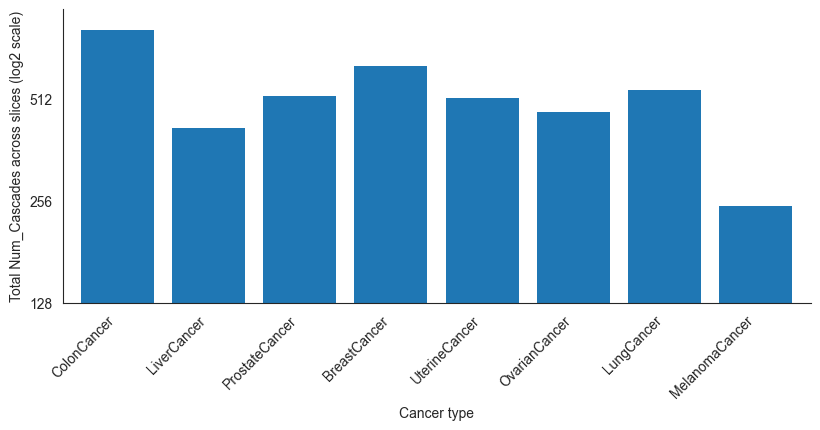

In [22]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ---------------------------
# Nature-style + Illustrator-friendly
# ---------------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,   # editable text in Illustrator
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

# ---------------------------
# Aggregate total Num_Cascades within each cancer type
# ---------------------------
CancerType_order = [
    "ColonCancer", "LiverCancer", "ProstateCancer", "BreastCancer",
    "UterineCancer", "OvarianCancer", "LungCancer", "MelanomaCancer"
]

sum_df = (
    num_MIcascade_df
    .groupby("CancerType", as_index=False)["Num_Cascades"]
    .sum()
)

sum_df["CancerType"] = pd.Categorical(
    sum_df["CancerType"],
    categories=CancerType_order,
    ordered=True
)
sum_df = sum_df.sort_values("CancerType").reset_index(drop=True)

display(sum_df)

# ---------------------------
# Barplot on log2 scale
# ---------------------------
fig, ax = plt.subplots(figsize=(8.5, 4.2))

x = np.arange(len(sum_df))
y = sum_df["Num_Cascades"].to_numpy(dtype=float)

if np.any(y <= 0):
    raise ValueError("Num_Cascades contains non-positive values, which cannot be plotted on a log2 axis.")

ax.bar(x, y, linewidth=0)

ax.set_xlabel("Cancer type")
ax.set_ylabel("Total Num_Cascades across slices (log2 scale)")

# log2 axis
ax.set_yscale("log", base=2)

# lock x-limits so artists are guaranteed inside the axes box
ax.set_xlim(-0.6, len(x) - 0.4)

# lock y-limits in log space with padding
ymin = y.min()
ymax = y.max()
pmin_data = np.log2(ymin)
pmax_data = np.log2(ymax)
pad = 0.20

# ticks: only within data range
pmin = int(np.floor(pmin_data))
pmax = int(np.ceil(pmax_data))
ticks = [2 ** p for p in range(pmin, pmax + 1)]
ax.set_yticks(ticks)
ax.set_yticklabels([f"{int(t)}" if float(t).is_integer() else f"{t:g}" for t in ticks])
ax.yaxis.set_minor_locator(mticker.NullLocator())

ax.set_ylim(ticks[0], 2 ** (pmax_data + pad))

# x tick labels
ax.set_xticks(x)
ax.set_xticklabels(sum_df["CancerType"], rotation=45, ha="right")

# Nature-like spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# A bit of breathing room
ax.margins(x=0.00, y=0.00)
fig.subplots_adjust(left=0.11, right=0.99, bottom=0.28, top=0.98)

# ---------------------------
# Save for Illustrator
# ---------------------------
outdir = Path(file_savepath_main)
outdir.mkdir(parents=True, exist_ok=True)

pdf_path = outdir / "Total_Num_Cascades_by_CancerType_log2.pdf"
svg_path = outdir / "Total_Num_Cascades_by_CancerType_log2.svg"

fig.savefig(pdf_path, format="pdf")
fig.savefig(svg_path, format="svg")

plt.show()

## 8. Differential Gene, Ligand–Receptor, and Functional State Analysis between Cascaded and Non-Cascaded Triplets

The following sections preserve the main downstream comparisons from the original Pancancer analysis. The code defines pathway and gene-state panels, constructs triplet groups such as `BothPos`, `OnlyMIfirst`, `OnlyMIsecond`, and `BothNeg`, and compares these groups at multiple molecular levels.

### Step 1. Define pathway-induced LR programs and supporting gene-state panels

In [23]:
###############################################################
# 1. Initialization and Preprocessing
###############################################################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import ranksums

# -----------------------------
# Define pathways
# -----------------------------
pathway1_chose, pathway2_chose = ["CDH1","LAMININ","COLLAGEN","PDGF"], ["CDH1","NCAM"]
pathway1_chose_merge, pathway2_chose_merge = "+".join(pathway1_chose), "+".join(pathway2_chose)

def expand_genes(genes):
    """Split combined gene symbols like 'COL1A1_COL1A2'."""
    expanded = []
    for g in genes:
        expanded.extend(g.split("_")) if "_" in g else expanded.append(g)
    return np.unique(expanded)


def cancer_type_to_cancercell_label(cancer_type):
    """Convert a cancer type name to its corresponding cancer-cell label."""
    cancer_type = str(cancer_type)
    if cancer_type.endswith("Cancer"):
        return cancer_type.replace("Cancer", "") + "-cancercell"
    return cancer_type + "-cancercell"


def resolve_triple_for_cancertype(celltype_triple, cancer_type):
    """Replace generic 'cancercell' tokens with the cancer-type-specific label."""
    cancer_cell_label = cancer_type_to_cancercell_label(cancer_type)
    parts = [x.strip() for x in str(celltype_triple).split("->")]
    if len(parts) != 3:
        raise ValueError(
            "celltype_triple_of_interest must have exactly 3 parts, "
            "for example 'Fibroblast -> cancercell -> cancercell'."
        )
    return [cancer_cell_label if p.lower() == "cancercell" else p for p in parts]


# -----------------------------
# Resolve the template triple (used for file names / labels)
# -----------------------------
ct1_template, ct2_template, ct3_template = [
    x.strip() for x in str(celltype_triple_of_interest).split("->")
]

# Keep these aliases so downstream cells that use ct1_cur/ct2_cur/ct3_cur
# in file names remain compatible with the updated notebook.
ct1_cur, ct2_cur, ct3_cur = ct1_template, ct2_template, ct3_template

# Determine fibroblast position in the template triplet.
# This position is shared across cancer types because only the generic
# 'cancercell' token is resolved differently.
fibroblast_relindex_triple = {
    'Fibroblast': [ct1_template, ct2_template, ct3_template].index('Fibroblast')
} if 'Fibroblast' in [ct1_template, ct2_template, ct3_template] else np.nan

# -----------------------------
# Build sample_index -> cancer_type mapping
# -----------------------------
if 'sampleindex_to_cancertype' not in globals():
    sampleindex_to_cancertype = {}

    if 'cancertype_to_sample_indices' in globals():
        for _ct, _indices in cancertype_to_sample_indices.items():
            for _si in _indices:
                sampleindex_to_cancertype[int(_si)] = str(_ct)
    elif 'sample_metadata_df' in globals() and {'SampleID', 'CancerType'}.issubset(set(sample_metadata_df.columns)):
        sampleid_to_cancertype = dict(
            zip(sample_metadata_df['SampleID'].astype(str), sample_metadata_df['CancerType'].astype(str))
        )
        for _si, _adata in enumerate(adata_list):
            _sample_id = str(_adata.obs['SampleID'].iloc[0])
            sampleindex_to_cancertype[_si] = sampleid_to_cancertype.get(_sample_id, _sample_id.split('_')[0])
    else:
        for _si, _adata in enumerate(adata_list):
            _sample_id = str(_adata.obs['SampleID'].iloc[0])
            sampleindex_to_cancertype[_si] = _sample_id.split('_')[0]

print('Template triplet:', f'{ct1_template} -> {ct2_template} -> {ct3_template}')
print('Fibroblast position in triplet:', fibroblast_relindex_triple)
print('Example sample_index_to_cancertype:', list(sampleindex_to_cancertype.items())[:5])

# -----------------------------
# Load LR metadata
# -----------------------------
LR_meta = pd.read_csv(file_savepath_main + "LR_meta_incellchatdb.csv")

def get_pathway_indices(pathway_list):
    idx = np.where(LR_meta['pathway_name'].isin(pathway_list))[0]
    ligands = expand_genes(np.unique(LR_meta.loc[idx, 'ligand']))
    receptors = expand_genes(np.unique(LR_meta.loc[idx, 'receptor']))
    return idx, ligands, receptors

LRindex_pathway1, ligand_pathway1, receptor_pathway1 = get_pathway_indices(pathway1_chose)
LRindex_pathway2, ligand_pathway2, receptor_pathway2 = get_pathway_indices(pathway2_chose)

def get_gene_indices(adata, genes):
    return np.where(np.isin(adata.var_names, genes))[0]

ligand_pathway1_geneindex = get_gene_indices(adata_list[0], ligand_pathway1)
receptor_pathway1_geneindex = get_gene_indices(adata_list[0], receptor_pathway1)
ligand_pathway2_geneindex = get_gene_indices(adata_list[0], ligand_pathway2)
receptor_pathway2_geneindex = get_gene_indices(adata_list[0], receptor_pathway2)

# -----------------------------
# Normalize LR pair matrix
# -----------------------------
cellpair_LRpair_neigh_merge = np.vstack([
    SpiderNet_data_pyg_list[i]['cellpair_LRpair_neigh'].cpu().numpy()
    for i in range(nsample)
])
cellpair_LRpair_neigh_merge_max = np.max(cellpair_LRpair_neigh_merge, axis=0)

# -----------------------------
# Expression data normalization
# -----------------------------
exp_data_all = np.vstack([
    adata.X.toarray() if hasattr(adata.X, 'toarray') else np.asarray(adata.X)
    for adata in adata_list
])
print(exp_data_all.shape)
exp_data_all_max = np.max(exp_data_all, axis=0)


Template triplet: Fibroblast -> cancercell -> cancercell
Fibroblast position in triplet: {'Fibroblast': 0}
Example sample_index_to_cancertype: [(0, 'BreastCancer'), (1, 'BreastCancer'), (2, 'BreastCancer'), (3, 'BreastCancer'), (4, 'BreastCancer')]
(4707751, 500)


In [24]:
fibroblast_relindex_triple

{'Fibroblast': 0}

In [25]:
# 2. CAF markers and Functional states
###############################################################
caf_modules = {
    "myCAF": ["ACTA2","TAGLN","MYL9","TPM2","CNN1","CALD1","COL1A1","COL1A2"],
    "iCAF": ["IL6","CXCL12","CXCL14","LIF","CCL2","PTGS2"],
    "apCAF": ["HLA-DRA","HLA-DRB1","CD74","CIITA"],
    "meCAF": ["COL11A1","THBS2","MMP11","ITGA11","FN1","VCAN","SPARC","SULF1","LOX","PLOD2"],
    "periCAF": ["RGS5","PDGFRB","MCAM","NOTCH3","TAGLN"],
    "prolCAF": ["MKI67","TOP2A","PCNA"]
}
caf_genes_inadata = np.unique([g for m in caf_modules.values() for g in m if g in adata_list[0].var_names])
caf_genes_inadata_geneindex = get_gene_indices(adata_list[0], caf_genes_inadata)
print(f"The number of CAF genes in data: {len(caf_genes_inadata_geneindex)}")

The number of CAF genes in data: 17
Angiogenesis: 8 genes
Cell Cycle: 17 genes
Differentiation: 5 genes
DNA damage: 13 genes
DNA repair: 18 genes
EMT: 5 genes
Hypoxia: 17 genes
Inflammation: 19 genes
Invasion: 8 genes
Metastasis: 15 genes
Proliferation: 9 genes
Quiescence: 6 genes
Stemness: 3 genes


### Step 2. Initialize analysis containers and bookkeeping objects

In [26]:
###############################################################
# 3. Initialize Analysis Containers
###############################################################
triplet_groups = ["BothPos","OnlyMIfirst","OnlyMIsecond","BothNeg"]
# triplet_groups = ["BothPos","OnlyMIsecond"]
pathways = ["pathway1","pathway2"]

def init_nested_dict(levels, leaf_type=list):
    if len(levels)==1: return {k: leaf_type() for k in levels[0]}
    return {k: init_nested_dict(levels[1:], leaf_type) for k in levels[0]}

LRStrength_pathwayagg_all = init_nested_dict([pathways, triplet_groups])
Ligandexpression_pathwayagg_all = init_nested_dict([pathways, triplet_groups])
Receptorexpression_pathwayagg_all = init_nested_dict([pathways, triplet_groups])
CAFscore_all = {k: [] for k in triplet_groups}
Functionalstate_all = {
    k: {term: [] for term in functional_geneset_choose_geneindex_dict.keys()}
    for k in triplet_groups
}
celltype_alignment_all = {k: [] for k in triplet_groups}

##Record the cancer type
LRStrength_pathwayagg_all_cancertype = init_nested_dict([pathways, triplet_groups])
Ligandexpression_pathwayagg_all_cancertype = init_nested_dict([pathways, triplet_groups])
Receptorexpression_pathwayagg_all_cancertype = init_nested_dict([pathways, triplet_groups])
CAFscore_all_cancertype = {k: [] for k in triplet_groups}
Functionalstate_all_cancertype = {
    k: {term: [] for term in functional_geneset_choose_geneindex_dict.keys()}
    for k in triplet_groups
}
celltype_alignment_all_cancertype = {k: [] for k in triplet_groups}
##
mal_cells_records = {k: [] for k in triplet_groups}
CACHE_EXPR_FOR_DEG = False
mal_expr_cache = {k: [] for k in triplet_groups}  # list of np.ndarray or sparse matrices (per sample chunk)

### Step 3. Run the core triplet-group analysis loop

In [27]:
###############################################################
# 4. Core Analysis Loop
###############################################################
import numpy as np
from scipy.spatial.distance import cdist

MI_threshold_use = 0.5

def extract_triplets(F_cut, A, edge_index, cell_types, cond_first, cond_second, ct1, ct2, ct3):
    """Strict: require exact (ct1, ct2, ct3) match."""
    r1 = np.where(cond_first)[0]
    r2 = np.where(cond_second)[0]
    if (len(r1) == 0) or (len(r2) == 0):
        return np.zeros((0, 3), dtype=int)

    A_sel = A[r1, :][:, r2]
    rows, cols = A_sel.nonzero()
    if len(rows) == 0:
        return np.zeros((0, 3), dtype=int)

    pairs = np.vstack([r1[rows], r2[cols]]).T
    triplets = np.hstack([edge_index[pairs[:, 0]], edge_index[pairs[:, 1], 1][:, None]])

    ct_trip = cell_types[triplets]
    mask = (ct_trip[:, 0] == ct1) & (ct_trip[:, 1] == ct2) & (ct_trip[:, 2] == ct3)
    return triplets[mask]


def extract_triplets_extend(F_cut, A, edge_index, cell_types, cond_first, cond_second, ct1, ct2, ct3):
    """
    Loose: allow substring match, e.g. ct1="Fibro" matches "Fibroblast".
    This is robust when cell-type labels contain suffix/prefix variants.
    """
    r1 = np.where(cond_first)[0]
    r2 = np.where(cond_second)[0]
    if (len(r1) == 0) or (len(r2) == 0):
        return np.zeros((0, 3), dtype=int)

    A_sel = A[r1, :][:, r2]
    rows, cols = A_sel.nonzero()
    if len(rows) == 0:
        return np.zeros((0, 3), dtype=int)

    pairs = np.vstack([r1[rows], r2[cols]]).T
    triplets = np.hstack([edge_index[pairs[:, 0]], edge_index[pairs[:, 1], 1][:, None]])

    ct_trip = cell_types[triplets]
    mask = np.array([
        (ct1 in str(a)) and (ct2 in str(b)) and (ct3 in str(c))
        for a, b, c in ct_trip
    ], dtype=bool)
    return triplets[mask]


def get_rel_indices(triplets, edge_index, pathway):
    """
    Return unique edge indices in edge_index that correspond to (node_i -> node_j)
    for the two edges in a triplet:
      pathway1 uses (0->1), pathway2 uses (1->2)
    """
    if triplets is None or len(triplets) == 0:
        return np.array([], dtype=int)

    if pathway == "pathway1":
        u = triplets[:, 0]
        v = triplets[:, 1]
    else:
        u = triplets[:, 1]
        v = triplets[:, 2]

    src_all = edge_index[:, 0]
    dst_all = edge_index[:, 1]

    edge_map = {}
    for idx_e in range(edge_index.shape[0]):
        key = (int(src_all[idx_e]), int(dst_all[idx_e]))
        if key not in edge_map:
            edge_map[key] = idx_e

    rel = []
    for uu, vv in zip(u, v):
        key = (int(uu), int(vv))
        if key in edge_map:
            rel.append(edge_map[key])

    if len(rel) == 0:
        return np.array([], dtype=int)
    return np.unique(np.asarray(rel, dtype=int))


def _get_expr_matrix(adata, prefer_layer="counts"):
    """Return expression matrix for DEG caching; prefer counts layer if it exists."""
    if prefer_layer is not None and hasattr(adata, "layers") and prefer_layer in adata.layers:
        return adata.layers[prefer_layer]
    return adata.X


for sample_index, adata in enumerate(adata_list):

    print(f"Processing sample {sample_index+1}/{nsample}...")

    F = (Factor_envir_norm_list[sample_index] > MI_threshold_use).astype(int)
    A = hyper_edge_adj_list[sample_index]
    edge_index = SpiderNet_data_pyg_list[sample_index].edge_index.numpy()

    # Use string labels to avoid categorical edge cases.
    cell_types = adata.obs["celltype_final"].astype(str).to_numpy()

    # expression / LR normalization
    X_cur = adata.X.toarray() if hasattr(adata.X, 'toarray') else np.asarray(adata.X)
    exp_norm = X_cur / (exp_data_all_max + 1e-8)
    lr_norm = (
        SpiderNet_data_pyg_list[sample_index]["cellpair_LRpair_neigh"].cpu().numpy()
        / (cellpair_LRpair_neigh_merge_max + 1e-8)
    )

    # Determine the cancer type from the explicit sample->cancer mapping.
    cancertype = str(sampleindex_to_cancertype.get(sample_index, str(adata.obs["SampleID"].iloc[0]).split("_")[0]))

    # Resolve the template triple separately for each cancer type.
    ct1_sample, ct2_sample, ct3_sample = resolve_triple_for_cancertype(
        celltype_triple_of_interest,
        cancertype
    )

    conds = {
        "BothPos":      (F[:, MI_first_index] == 1, F[:, MI_second_index] == 1),
        "OnlyMIfirst":  (F[:, MI_first_index] == 1, F[:, MI_second_index] == 0),
        "OnlyMIsecond": (F[:, MI_first_index] == 0, F[:, MI_second_index] == 1),
        "BothNeg":      (F[:, MI_first_index] == 0, F[:, MI_second_index] == 0),
    }

    # Exclude malignant cells already in BothPos.
    mal_idx_BothPos = np.array([], dtype=int)

    for group, (c1, c2) in conds.items():

        triples = extract_triplets_extend(
            F, A, edge_index, cell_types,
            c1, c2, ct1_sample, ct2_sample, ct3_sample
        )

        rel_p1 = get_rel_indices(triples, edge_index, "pathway1")
        rel_p2 = get_rel_indices(triples, edge_index, "pathway2")

        # fibroblast indices in triplets (pathway1 edges)
        if len(rel_p1) > 0:
            fb_idx = edge_index[rel_p1, fibroblast_relindex_triple["Fibroblast"]]
            fb_idx = np.unique(fb_idx)
        else:
            fb_idx = np.array([], dtype=int)

        # malignant indices in triplets (pathway2 edges; receiver is col=1 by this setup)
        if len(rel_p2) > 0:
            mal_idx = edge_index[rel_p2, 1]
            mal_idx = np.unique(mal_idx)
        else:
            mal_idx = np.array([], dtype=int)

        if group == "BothPos":
            mal_idx_BothPos = mal_idx.copy()
        else:
            if mal_idx_BothPos is not None and len(mal_idx_BothPos) > 0:
                mal_idx = np.setdiff1d(mal_idx, mal_idx_BothPos)

        # -------------------------
        # record malignant cells
        # -------------------------
        if len(mal_idx) > 0:
            mal_idx_uniq = np.unique(mal_idx)

            celltype_alignment_all[group].extend(cell_types[mal_idx_uniq].tolist())
            celltype_alignment_all_cancertype[group].extend([cancertype] * len(mal_idx_uniq))

            mal_cell_ids = adata.obs_names[mal_idx_uniq].tolist()
            mal_cell_cts = cell_types[mal_idx_uniq].tolist()
            for cid, ctt in zip(mal_cell_ids, mal_cell_cts):
                mal_cells_records[group].append(
                    {
                        "sample_index": sample_index,
                        "cell_id": cid,
                        "celltype_final": ctt,
                        "cancertype": cancertype
                    }
                )

            if CACHE_EXPR_FOR_DEG:
                X_deg = _get_expr_matrix(adata, prefer_layer="counts")
                mal_chunk = X_deg[mal_idx_uniq, :]
                mal_expr_cache[group].append(mal_chunk.copy() if hasattr(mal_chunk, "copy") else mal_chunk)

        # -------------------------
        # LR strength aggregation
        # -------------------------
        for p, lr_idx in zip(pathways, [LRindex_pathway1, LRindex_pathway2]):
            rel_idx = rel_p1 if p == "pathway1" else rel_p2
            if len(rel_idx) > 0:
                LRStrength_pathwayagg_all[p][group].extend(lr_norm[:, lr_idx].mean(1)[rel_idx].tolist())
                LRStrength_pathwayagg_all_cancertype[p][group].extend([cancertype] * len(rel_idx))

        # -------------------------
        # ligand / receptor expression aggregation
        # -------------------------
        for p, (lig_idx, rec_idx, rel_idx) in zip(
            pathways,
            [
                (ligand_pathway1_geneindex, receptor_pathway1_geneindex, rel_p1),
                (ligand_pathway2_geneindex, receptor_pathway2_geneindex, rel_p2),
            ]
        ):
            if len(rel_idx) == 0:
                continue

            lig_exp = exp_norm[np.unique(edge_index[rel_idx, 0]), :][:, lig_idx].mean(1)
            rec_exp = exp_norm[np.unique(edge_index[rel_idx, 1]), :][:, rec_idx].mean(1)

            Ligandexpression_pathwayagg_all[p][group].extend(lig_exp.tolist())
            Receptorexpression_pathwayagg_all[p][group].extend(rec_exp.tolist())

            Ligandexpression_pathwayagg_all_cancertype[p][group].extend([cancertype] * len(lig_exp))
            Receptorexpression_pathwayagg_all_cancertype[p][group].extend([cancertype] * len(rec_exp))

        # -------------------------
        # CAF score (fibroblast)
        # -------------------------
        if len(fb_idx) > 0:
            CAFscore_all[group].extend(exp_norm[fb_idx, :][:, caf_genes_inadata_geneindex].mean(1).tolist())
            CAFscore_all_cancertype[group].extend([cancertype] * len(fb_idx))

        # -------------------------
        # functional state (malignant)
        # -------------------------
        for term, idx in functional_geneset_choose_geneindex_dict.items():
            if len(mal_idx) > 0:
                Functionalstate_all[group][term].extend(exp_norm[mal_idx, :][:, idx].mean(1).tolist())
                Functionalstate_all_cancertype[group][term].extend([cancertype] * len(mal_idx))


Processing sample 1/160...
Processing sample 2/160...
Processing sample 3/160...
Processing sample 4/160...
Processing sample 5/160...
Processing sample 6/160...
Processing sample 7/160...
Processing sample 8/160...
Processing sample 9/160...
Processing sample 10/160...
Processing sample 11/160...
Processing sample 12/160...
Processing sample 13/160...
Processing sample 14/160...
Processing sample 15/160...
Processing sample 16/160...
Processing sample 17/160...
Processing sample 18/160...
Processing sample 19/160...
Processing sample 20/160...
Processing sample 21/160...
Processing sample 22/160...
Processing sample 23/160...
Processing sample 24/160...
Processing sample 25/160...
Processing sample 26/160...
Processing sample 27/160...
Processing sample 28/160...
Processing sample 29/160...
Processing sample 30/160...
Processing sample 31/160...
Processing sample 32/160...
Processing sample 33/160...
Processing sample 34/160...
Processing sample 35/160...
Processing sample 36/160...
P

### Step 4. Build the DEG AnnData and perform DEG on downstream malignant cells

In [28]:
import scanpy as sc

def build_deg_adata_for_groups(
    adata_list,
    mal_cells_records,
    groups=("BothPos", "OnlyMIsecond"),
    prefer_layer="counts",
    normalize_log1p=True
):
    """
    Return a concatenated AnnData with obs['group'] indicating which group each
    cell belongs to. Cells are selected via mal_cells_records[group], which now
    stores sample_index, cell_id, celltype_final, and cancertype.
    """
    adata_chunks = []

    for g in groups:
        recs = mal_cells_records.get(g, [])
        if len(recs) == 0:
            continue

        df = pd.DataFrame(recs).copy()
        if df.shape[0] == 0:
            continue

        # Deduplicate within each sample/group in case the same malignant cell
        # is encountered multiple times.
        df = df.drop_duplicates(subset=["sample_index", "cell_id"]).reset_index(drop=True)

        for si, sub in df.groupby("sample_index"):
            si = int(si)
            ad = adata_list[si]
            sub = sub.copy()
            ids = sub["cell_id"].astype(str).tolist()

            # Keep only cells that are present in the AnnData index.
            ids = [cid for cid in ids if cid in ad.obs_names]
            if len(ids) == 0:
                continue

            sub = sub[sub["cell_id"].astype(str).isin(ids)].drop_duplicates(subset=["cell_id"])
            id_order = sub["cell_id"].astype(str).tolist()

            ad_sub = ad[id_order].copy()
            ad_sub.obs["group"] = g
            ad_sub.obs["sample_index"] = si

            # Preserve the cancer type and selected cell-type annotation directly
            # from the per-sample records rather than re-deriving them from SampleID.
            record_map_ct = dict(zip(sub["cell_id"].astype(str), sub["cancertype"].astype(str)))
            record_map_celltype = dict(zip(sub["cell_id"].astype(str), sub["celltype_final"].astype(str)))

            ad_sub.obs["cancertype"] = [record_map_ct.get(str(idx), np.nan) for idx in ad_sub.obs_names]
            ad_sub.obs["celltype_final_selected"] = [record_map_celltype.get(str(idx), np.nan) for idx in ad_sub.obs_names]

            if prefer_layer is not None and prefer_layer in ad_sub.layers:
                ad_sub.X = ad_sub.layers[prefer_layer].copy()

            adata_chunks.append(ad_sub)

    if len(adata_chunks) == 0:
        return None

    adata_deg = sc.concat(adata_chunks, join="outer", label="batch", keys=None, index_unique=None)

    if normalize_log1p:
        sc.pp.normalize_total(adata_deg, target_sum=1e4)
        sc.pp.log1p(adata_deg)

    return adata_deg


# ---- build and DEG ----
adata_deg = build_deg_adata_for_groups(
    adata_list=adata_list,
    mal_cells_records=mal_cells_records,
    groups=("BothPos", "OnlyMIsecond"),
    prefer_layer="counts",
    normalize_log1p=True
)


In [37]:
mal_cells_records

{'BothPos': [{'sample_index': 0,
   'cell_id': 'HumanBreastCancerPatient1_454747',
   'celltype_final': 'Breast-cancercell',
   'cancertype': 'BreastCancer'},
  {'sample_index': 0,
   'cell_id': 'HumanBreastCancerPatient1_454859',
   'celltype_final': 'Breast-cancercell',
   'cancertype': 'BreastCancer'},
  {'sample_index': 0,
   'cell_id': 'HumanBreastCancerPatient1_455102',
   'celltype_final': 'Breast-cancercell',
   'cancertype': 'BreastCancer'},
  {'sample_index': 0,
   'cell_id': 'HumanBreastCancerPatient1_455162',
   'celltype_final': 'Breast-cancercell',
   'cancertype': 'BreastCancer'},
  {'sample_index': 0,
   'cell_id': 'HumanBreastCancerPatient1_455818',
   'celltype_final': 'Breast-cancercell',
   'cancertype': 'BreastCancer'},
  {'sample_index': 0,
   'cell_id': 'HumanBreastCancerPatient1_28778',
   'celltype_final': 'Breast-cancercell',
   'cancertype': 'BreastCancer'},
  {'sample_index': 0,
   'cell_id': 'HumanBreastCancerPatient1_29702',
   'celltype_final': 'Breast-ca

In [31]:
# adata_deg.obs['cancertype'] = [
#     str(sample0).split("_")[0]
#     for sample0 in adata_deg.obs['SampleID']
# ]

In [32]:
if adata_deg is not None:
    # Keep the cancer-type annotation recorded during triplet extraction.
    if "cancertype" not in adata_deg.obs.columns or adata_deg.obs["cancertype"].isna().all():
        if "sample_index" in adata_deg.obs.columns:
            adata_deg.obs["cancertype"] = [
                sampleindex_to_cancertype.get(int(si), np.nan)
                for si in adata_deg.obs["sample_index"]
            ]
        else:
            adata_deg.obs["cancertype"] = [
                str(sample0).split("_")[0]
                for sample0 in adata_deg.obs["SampleID"]
            ]

    print("Unique cancer types in adata_deg:", np.unique(adata_deg.obs["cancertype"].astype(str)))
    if "CELL_TYPE" in adata_deg.obs.columns:
        print("Unique CELL_TYPE labels in adata_deg:", np.unique(adata_deg.obs["CELL_TYPE"].astype(str))[:20])


Unique cancer types in adata_deg: ['BreastCancer' 'ColonCancer' 'LiverCancer' 'LungCancer' 'MelanomaCancer'
 'OvarianCancer' 'ProstateCancer' 'UterineCancer']
Unique CELL_TYPE labels in adata_deg: ['Breast-cancercell' 'Colon-cancercell' 'Liver-cancercell'
 'Lung-cancercell' 'Melanoma-cancercell' 'Ovarian-cancercell'
 'Prostate-cancercell' 'Uterine-cancercell']


In [33]:
if adata_deg is None:
    print("No cells for DEG.")
else:
    # DEG: BothPos vs OnlyMIsecond
    sc.tl.rank_genes_groups(
        adata_deg,
        groupby="group",
        groups=["BothPos"],
        reference="OnlyMIsecond",
        method="wilcoxon",
        pts=True
    )

    # Save the DEG table
    deg_df = sc.get.rank_genes_groups_df(adata_deg, group="BothPos")
    deg_save_path = f"{file_savepath_main}/DEG_mal_cells_BothPos_vs_OnlyMIsecond_{ct1_cur}-{ct2_cur}-{ct3_cur}.csv"
    deg_df.to_csv(deg_save_path, index=False)
    print(f"[Saved DEG] {deg_save_path}")

[Saved DEG] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//DEG_mal_cells_BothPos_vs_OnlyMIsecond_Fibroblast-cancercell-cancercell.csv


In [34]:
#Call DEG for each cancer type
cancertype_unique = np.unique(adata_deg.obs['cancertype'])
for ct in cancertype_unique:
    print(f"Processing cancer type: {ct}...")
    adata_deg_ct = adata_deg[adata_deg.obs['cancertype']==ct].copy()
    if adata_deg_ct.n_obs < 10:
        print(f"❗ Not enough cells ({adata_deg_ct.n_obs}) for DEG in {ct}, skipping.")
        continue
    sc.tl.rank_genes_groups(
        adata_deg_ct,
        groupby="group",
        groups=["BothPos"],
        reference="OnlyMIsecond",
        method="wilcoxon",
        pts=True
    )
    deg_df_ct = sc.get.rank_genes_groups_df(adata_deg_ct, group="BothPos")
    deg_save_path_ct = f"{file_savepath_main}/DEG_mal_cells_BothPos_vs_OnlyMIsecond_{ct1_cur}-{ct2_cur}-{ct3_cur}_{ct}.csv"
    deg_df_ct.to_csv(deg_save_path_ct, index=False)
    print(f"[Saved DEG] {deg_save_path_ct}")

Processing cancer type: BreastCancer...
[Saved DEG] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//DEG_mal_cells_BothPos_vs_OnlyMIsecond_Fibroblast-cancercell-cancercell_BreastCancer.csv
Processing cancer type: ColonCancer...
[Saved DEG] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//DEG_mal_cells_BothPos_vs_OnlyMIsecond_Fibroblast-cancercell-cancercell_ColonCancer.csv
Processing cancer type: LiverCancer...
[Saved DEG] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//DEG_mal_cells_BothPos_vs_OnlyMIsecond_Fibroblast-cancercell-cancercell_LiverCancer.csv
Processing cancer type: LungCancer...
[Saved DEG] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//DEG_mal_cells_BothPos_vs_OnlyMIsecond_Fibroblast-cancercell-cancercell_LungCancer.csv
Processing cancer type: MelanomaCancer...
[Saved DEG] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//DEG_mal_cells_BothPos_vs_OnlyMIsecond_Fibroblast-cancercell-cancercell_MelanomaCancer.csv
Processing can

### Step 5. GO enrichment for downstream malignant cells

The next cells run GO enrichment first for the pooled comparison and then separately for each cancer type.

#Upregulated genes in BothPos: 32
[Saved GO results] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_enrichment_up_BothPos_Fibroblast-cancercell-cancercell.csv


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\735423371.py:50: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


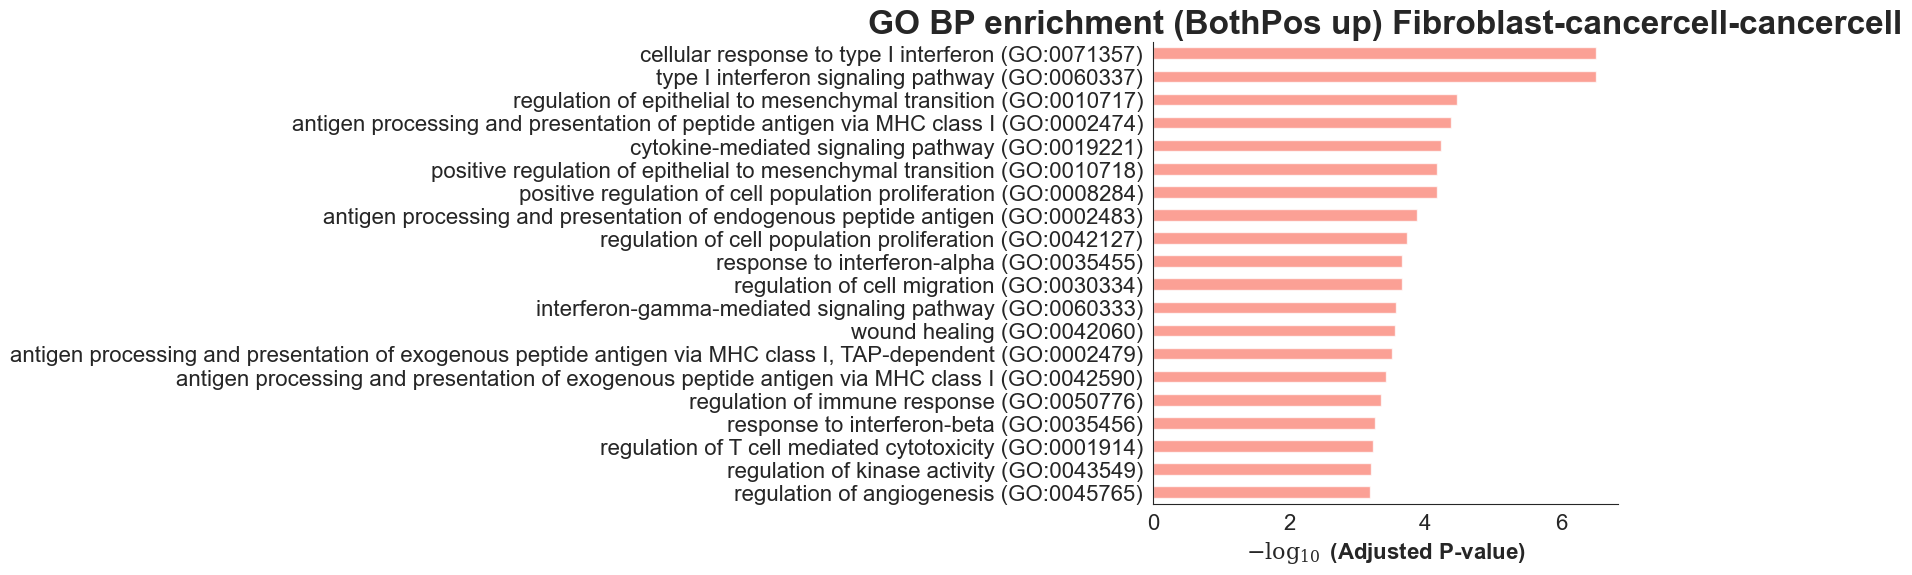

[Saved plot] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_barplot_up_BothPos_Fibroblast-cancercell-cancercell.png


In [36]:
##GO enrichment
# ------------------------
# Step 1) Read the DEG results and filter genes upregulated in BothPos.
# ------------------------
deg_df = pd.read_csv(deg_save_path)

# Common filter: genes upregulated in BothPos with significant adjusted p-values.
# deg_up = deg_df[(deg_df["logfoldchanges"] > 0) & (deg_df["pvals_adj"] < 0.05)].copy()
deg_up = deg_df[(deg_df["logfoldchanges"] > 0.3) & (deg_df["pvals_adj"] < 0.05)].copy()


# Optional: add an effect-size threshold for a more conservative selection.
# deg_up = deg_up[deg_up["logfoldchanges"] > 0.25]

up_genes = deg_up["names"].dropna().astype(str).unique().tolist()
print(f"#Upregulated genes in BothPos: {len(up_genes)}")

import gseapy as gp

# Organism: use Human here; switch to Mouse for mouse datasets.
organism = "human"

outdir = f"{file_savepath_main}/GO_enrichment_up_BothPos_{ct1_cur}-{ct2_cur}-{ct3_cur}"

enr = gp.enrichr(
    gene_list=up_genes,
    gene_sets=["GO_Biological_Process_2021"],  # alternatively use "GO_Molecular_Function_2021" or "GO_Cellular_Component_2021"
    organism=organism,
    outdir=outdir,
    cutoff=0.05
)

# Result table
go_res = enr.results.sort_values("Adjusted P-value")
go_path = f"{file_savepath_main}/GO_enrichment_up_BothPos_{ct1_cur}-{ct2_cur}-{ct3_cur}.csv"
go_res.to_csv(go_path, index=False)
print(f"[Saved GO results] {go_path}")


import matplotlib.pyplot as plt

# Built-in gseapy barplot
gp.barplot(
    enr.res2d,
    column="Adjusted P-value",
    title=f"GO BP enrichment (BothPos up) {ct1_cur}-{ct2_cur}-{ct3_cur}",
    top_term=20,
    figsize=(6, 6)
)
plt.tight_layout()
fig_path = f"{file_savepath_main}/GO_barplot_up_BothPos_{ct1_cur}-{ct2_cur}-{ct3_cur}.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print(f"[Saved plot] {fig_path}")

#### Optional inspection: list the genes contributing to the top GO terms from the current enrichment result

In [38]:
import pandas as pd
import numpy as np

# go_res: this should already be available above as enr.results.sort_values("Adjusted P-value").
# If not, define it here:
# go_res = enr.results.sort_values("Adjusted P-value").copy()

top_term = 20
go_top = go_res.head(top_term).copy()

# ------------------------
# Find the gene-list column name (it may be Genes / genes depending on the version).
# ------------------------
gene_col = None
for c in ["Genes", "genes", "Gene", "gene"]:
    if c in go_top.columns:
        gene_col = c
        break

if gene_col is None:
    print("❗Genes column not found. Use print(go_res.columns) to inspect the available column names.")
    print("Columns:", list(go_res.columns))
else:
    # ------------------------
    # Parse the Genes string into a list.
    # Enrichr output is often formatted as "GENE1;GENE2;GENE3".
    # ------------------------
    def parse_genes(s):
        if pd.isna(s):
            return []
        s = str(s).strip()
        if s == "":
            return []
        # Common separators are ;, , or /. Handle all of them for robustness.
        if ";" in s:
            parts = s.split(";")
        elif "," in s:
            parts = s.split(",")
        else:
            parts = s.split()
        return [p.strip() for p in parts if p.strip()]

    go_top["gene_list"] = go_top[gene_col].apply(parse_genes)
    go_top["n_genes_in_term"] = go_top["gene_list"].apply(len)

    # ------------------------
    # Print the genes associated with each term.
    # The term column in Enrichr is usually named Term.
    # ------------------------
    term_col = "Term" if "Term" in go_top.columns else go_top.columns[0]

    for _, row in go_top.iterrows():
        print("=" * 80)
        print(f"GO term: {row[term_col]}")
        print(f"Adjusted P: {row.get('Adjusted P-value', np.nan)}")
        print(f"Overlap: {row.get('Overlap', '')}")
        print(f"Genes ({row['n_genes_in_term']}): {', '.join(row['gene_list'])}")

    # ------------------------
    # Save a table containing term, p-value, and hit genes.
    # ------------------------
    out_df = go_top[[term_col, "Adjusted P-value", "P-value", "Overlap", gene_col, "n_genes_in_term"]].copy()
    out_df.rename(columns={gene_col: "Genes_hit"}, inplace=True)

    save_hit_path = f"{file_savepath_main}/GO_top{top_term}_term2genes_BothPosUp_{ct1_cur}-{ct2_cur}-{ct3_cur}.csv"
    out_df.to_csv(save_hit_path, index=False)
    print(f"\n[Saved term→genes] {save_hit_path}")

GO term: cellular response to type I interferon (GO:0071357)
Adjusted P: 3.111966700109358e-07
Overlap: 6/65
Genes (6): BST2, IFITM1, STAT1, HLA-B, HLA-C, IFNAR1
GO term: type I interferon signaling pathway (GO:0060337)
Adjusted P: 3.111966700109358e-07
Overlap: 6/65
Genes (6): BST2, IFITM1, STAT1, HLA-B, HLA-C, IFNAR1
GO term: regulation of epithelial to mesenchymal transition (GO:0010717)
Adjusted P: 3.388517177786743e-05
Overlap: 5/76
Genes (5): LEF1, SPRY2, AXIN2, TGFBR1, TGFBR2
GO term: antigen processing and presentation of peptide antigen via MHC class I (GO:0002474)
Adjusted P: 4.215305945812838e-05
Overlap: 4/33
Genes (4): HLA-B, TAP2, TAP1, HLA-C
GO term: cytokine-mediated signaling pathway (GO:0019221)
Adjusted P: 5.911791753129769e-05
Overlap: 9/621
Genes (9): BST2, IFITM1, MUC1, NOS2, STAT1, HLA-B, HLA-C, HLA-DRA, IFNAR1
GO term: positive regulation of epithelial to mesenchymal transition (GO:0010718)
Adjusted P: 6.745759032429304e-05
Overlap: 4/42
Genes (4): LEF1, AXIN2, 

#### GO enrichment repeated separately for each cancer type

In [40]:
##GO enrichment for each cancer type
##Up regulated genes in BothPos vs OnlyMIsecond
go_res_up_dict = {}
for ct in cancertype_unique:
    print(f"Processing GO enrichment for cancer type: {ct}...")
    deg_save_path_ct = f"{file_savepath_main}/DEG_mal_cells_BothPos_vs_OnlyMIsecond_{ct1_cur}-{ct2_cur}-{ct3_cur}_{ct}.csv"
    # ------------------------
    deg_df = pd.read_csv(deg_save_path_ct)
    
    # Common filter: genes upregulated in BothPos with significant adjusted p-values.
    # deg_up = deg_df[(deg_df["logfoldchanges"] > 0) & (deg_df["pvals_adj"] < 0.05)].copy()
    deg_up = deg_df[(deg_df["logfoldchanges"] > 0.2) & (deg_df["pvals_adj"] < 0.05)].copy()
    print(np.max(deg_up['logfoldchanges']))
    if deg_up.shape[0]==0:
        print(f"❗ No upregulated genes for BothPos in {ct}, skipping GO enrichment.")
        continue
    
    # Optional: add an effect-size threshold for a more conservative selection.
    # deg_up = deg_up[deg_up["logfoldchanges"] > 0.25]
    
    up_genes = deg_up["names"].dropna().astype(str).unique().tolist()
    print(f"#Upregulated genes in BothPos: {len(up_genes)}")
    
    import gseapy as gp
    
    # Organism: use Human here; switch to Mouse for mouse datasets.
    organism = "human"
    
    outdir = f"{file_savepath_main}/GO_enrichment_up_BothPos_{ct1_cur}-{ct2_cur}-{ct3_cur}_{ct}"
    
    enr = gp.enrichr(
        gene_list=up_genes,
        gene_sets=["GO_Biological_Process_2021"],  # alternatively use "GO_Molecular_Function_2021" or "GO_Cellular_Component_2021"
        organism=organism,
        outdir=outdir,
        cutoff=0.05
    )
    print(enr.res2d.shape)
    
    # Result table
    go_res = enr.results.sort_values("Adjusted P-value")
    go_res_up_dict[ct] = go_res
    go_path = f"{file_savepath_main}/GO_enrichment_up_BothPos_{ct1_cur}-{ct2_cur}-{ct3_cur}_{ct}.csv"
    go_res.to_csv(go_path, index=False)
    print(f"[Saved GO results] {go_path}")
    
    
    import matplotlib.pyplot as plt
    
    # Built-in gseapy barplot
    gp.barplot(
        enr.res2d,
        column="Adjusted P-value",
        title=f"GO BP enrichment (BothPos up) {ct1_cur}-{ct2_cur}-{ct3_cur}",
        top_term=50,
        figsize=(6, 6)
    )
    plt.tight_layout()
    fig_path = f"{file_savepath_main}/GO_barplot_up_BothPos_{ct1_cur}-{ct2_cur}-{ct3_cur}_{ct}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    # plt.show()
    plt.close()
    print(f"[Saved plot] {fig_path}")

Processing GO enrichment for cancer type: BreastCancer...
0.6022048
#Upregulated genes in BothPos: 9
(278, 10)
[Saved GO results] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_enrichment_up_BothPos_Fibroblast-cancercell-cancercell_BreastCancer.csv


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\3693742778.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


[Saved plot] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_barplot_up_BothPos_Fibroblast-cancercell-cancercell_BreastCancer.png
Processing GO enrichment for cancer type: ColonCancer...
0.5174806
#Upregulated genes in BothPos: 74
(1550, 10)
[Saved GO results] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_enrichment_up_BothPos_Fibroblast-cancercell-cancercell_ColonCancer.csv


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\3693742778.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


[Saved plot] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_barplot_up_BothPos_Fibroblast-cancercell-cancercell_ColonCancer.png
Processing GO enrichment for cancer type: LiverCancer...
nan
❗ No upregulated genes for BothPos in LiverCancer, skipping GO enrichment.
Processing GO enrichment for cancer type: LungCancer...
0.6883511
#Upregulated genes in BothPos: 4
(144, 10)
[Saved GO results] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_enrichment_up_BothPos_Fibroblast-cancercell-cancercell_LungCancer.csv


...

[Saved plot] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_barplot_up_BothPos_Fibroblast-cancercell-cancercell_MelanomaCancer.png
Processing GO enrichment for cancer type: OvarianCancer...
0.38731852
#Upregulated genes in BothPos: 13
(493, 10)
[Saved GO results] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_enrichment_up_BothPos_Fibroblast-cancercell-cancercell_OvarianCancer.csv


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\3693742778.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


[Saved plot] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_barplot_up_BothPos_Fibroblast-cancercell-cancercell_OvarianCancer.png
Processing GO enrichment for cancer type: ProstateCancer...
nan
❗ No upregulated genes for BothPos in ProstateCancer, skipping GO enrichment.
Processing GO enrichment for cancer type: UterineCancer...
1.0618287
#Upregulated genes in BothPos: 59
(1407, 10)
[Saved GO results] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_enrichment_up_BothPos_Fibroblast-cancercell-cancercell_UterineCancer.csv


C:\Users\junji\AppData\Local\Temp\ipykernel_19560\3693742778.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


[Saved plot] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_barplot_up_BothPos_Fibroblast-cancercell-cancercell_UterineCancer.png


### Step 6. Summarize representative GO programs across cancer types

In [41]:
## Summary the representative GO terms across cancer types
representative_GO_by_class = {

    # 1. Interferon / cytokine / inflammatory signaling axis
    "Interferon_cytokine_inflammatory": [
        "cytokine-mediated signaling pathway (GO:0019221)",
        "cellular response to cytokine stimulus (GO:0071345)",
        "cellular response to interferon-gamma (GO:0071346)",
        "interferon-gamma-mediated signaling pathway (GO:0060333)",
        "cellular response to type I interferon (GO:0071357)",
        "type I interferon signaling pathway (GO:0060337)",
        "response to interferon-alpha (GO:0035455)",
        "regulation of I-kappaB kinase/NF-kappaB signaling (GO:0043122)"
    ],

    # 2. Proliferation / cell-cycle / DNA-damage checkpoint axis
    "Proliferation_cell_cycle_DNA_damage": [
        "regulation of cell population proliferation (GO:0042127)",
        "positive regulation of cell population proliferation (GO:0008284)",
        "negative regulation of cell population proliferation (GO:0008285)",
        "regulation of cell cycle (GO:0051726)",
        "DNA replication (GO:0006260)",
        "mitotic G1 DNA damage checkpoint signaling (GO:0031571)",
        "DNA damage response, signal transduction by p53 class mediator (GO:0030330)",
        "DNA damage response, signal transduction by p53 class mediator resulting in cell cycle arrest (GO:0006977)",
        "intrinsic apoptotic signaling pathway in response to DNA damage (GO:0008630)"
    ],

    # 3. Kinase / PI3K-AKT / MAPK / signal-transduction axis
    "Kinase_PI3K_AKT_MAPK_signaling": [
        "positive regulation of intracellular signal transduction (GO:1902533)",
        "regulation of protein kinase activity (GO:0045859)",
        "positive regulation of kinase activity (GO:0033674)",
        "positive regulation of protein kinase B signaling (GO:0051897)",
        "regulation of protein kinase B signaling (GO:0051896)",
        "MAPK cascade (GO:0000165)",
        "phosphorylation (GO:0016310)",
        "protein phosphorylation (GO:0006468)",
        "phosphatidylinositol-3-phosphate biosynthetic process (GO:0036092)"
    ],

    # 4. ECM remodeling / adhesion / EMT-like remodeling axis
    "ECM_adhesion_EMT_remodeling": [
        "regulation of epithelial to mesenchymal transition (GO:0010717)",
        "positive regulation of epithelial to mesenchymal transition (GO:0010718)",
        "extracellular matrix organization (GO:0030198)",
        "extracellular structure organization (GO:0043062)",
        "external encapsulating structure organization (GO:0045229)",
        "regulation of cell adhesion (GO:0030155)",
        "negative regulation of cell adhesion (GO:0007162)",
        "actin-mediated cell contraction (GO:0070252)",
        "negative regulation of actin filament depolymerization (GO:0030835)"
    ],

    # # 5. Antigen processing / MHC-I presentation / tumor-immune interface
    # "Antigen_presentation_tumor_immune_interface": [
    #     "antigen processing and presentation of peptide antigen via MHC class I (GO:0002474)",
    #     "antigen processing and presentation of endogenous peptide antigen (GO:0002483)",
    #     "regulation of immune response (GO:0050776)"
    # ],
    # 
    # # 6. Autophagy / metabolic and stress adaptation axis
    # "Autophagy_metabolic_stress_adaptation": [
    #     "regulation of macroautophagy (GO:0016241)",
    #     "positive regulation of cellular respiration (GO:1901857)",
    #     "regulation of cellular respiration (GO:0043457)",
    #     "response to lipid (GO:0033993)",
    #     "response to prostaglandin (GO:0034694)",
    #     "negative regulation of stress-activated protein kinase signaling cascade (GO:0070303)"
    # ],
    # 
    # # 7. Context-dependent / lower-confidence terms in tumor cells
    # "Context_dependent_low_confidence_misc": [
    #     "secondary palate development (GO:0062009)",
    #     "excitatory synapse assembly (GO:1904861)",
    #     "amyloid fibril formation (GO:1990000)",
    #     "B cell differentiation (GO:0030183)",
    #     "lymphocyte differentiation (GO:0030098)",
    #     "regulation of endothelial cell apoptotic process (GO:2000351)",
    #     "response to vitamin D (GO:0033280)"
    # ]
}

In [42]:
# Flatten the representative GO terms into an ordered list while preserving the within-class order.
ordered_GO_terms = []
GO_to_class = {}

for cls, go_list in representative_GO_by_class.items():
    for go in go_list:
        ordered_GO_terms.append(go)
        GO_to_class[go] = cls

n_go = len(ordered_GO_terms)
print(f"Total representative GO terms: {n_go}")

Total representative GO terms: 35


In [49]:
import numpy as np
import pandas as pd
import gseapy as gp

# =========================
# Init result matrices
# =========================
geneRatio_mat = pd.DataFrame(
    np.nan,
    index=cancertype_unique,
    columns=ordered_GO_terms
)

pval_mat = pd.DataFrame(
    np.nan,
    index=cancertype_unique,
    columns=ordered_GO_terms
)

organism = "human"

for ct in cancertype_unique:
    print(f"Processing cancer type: {ct}")

    deg_save_path_ct = (
        f"{file_savepath_main}/DEG_mal_cells_BothPos_vs_OnlyMIsecond_"
        f"{ct1_cur}-{ct2_cur}-{ct3_cur}_{ct}.csv"
    )

    deg_df = pd.read_csv(deg_save_path_ct)

    # =========================
    # Filter upregulated genes
    # =========================
    deg_up = deg_df[
        (deg_df["logfoldchanges"] > 0.2) &
        (deg_df["pvals_adj"] < 0.05)
    ].copy()

    if deg_up.shape[0] == 0:
        print(f"❗ No upregulated genes for {ct}, skipping.")
        continue

    up_genes = (
        deg_up["names"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    n_input_genes = len(up_genes)

    # =========================
    # GO enrichment
    # =========================
    enr = gp.enrichr(
        gene_list=up_genes,
        gene_sets=["GO_Biological_Process_2021"],
        organism=organism,
        outdir=None,
        cutoff=1.0
    )

    if enr is None or enr.results is None:
        print(f"❗ Enrichr failed for {ct}")
        continue

    go_res = enr.results.copy()

    # Standardize GO term names.
    go_res["GO_term"] = go_res["Term"].str.strip()
    go_res = go_res.set_index("GO_term")

    # =========================
    # Fill matrices
    # =========================
    for go in ordered_GO_terms:
        if go not in go_res.index:
            continue

        # adjusted p-value
        pval_mat.loc[ct, go] = go_res.loc[go, "Adjusted P-value"]

        # Correct GeneRatio: overlap divided by the size of the input gene list.
        overlap_str = go_res.loc[go, "Overlap"]

        if isinstance(overlap_str, str) and "/" in overlap_str:
            num, _ = overlap_str.split("/")
            geneRatio_mat.loc[ct, go] = float(num) / n_input_genes
        else:
            geneRatio_mat.loc[ct, go] = np.nan

Processing cancer type: BreastCancer
Processing cancer type: ColonCancer
Processing cancer type: LiverCancer
❗ No upregulated genes for LiverCancer, skipping.
Processing cancer type: LungCancer
Processing cancer type: MelanomaCancer
Processing cancer type: OvarianCancer
Processing cancer type: ProstateCancer
❗ No upregulated genes for ProstateCancer, skipping.
Processing cancer type: UterineCancer


In [50]:
import numpy as np
import pandas as pd

# =========================
# 1. Long-format dataframe that preserves the full structure without dropping cancer types.
# =========================
plot_df = (
    geneRatio_mat
    .stack(dropna=False)   # Important: preserve missing values (NA).
    .reset_index()
    .rename(columns={
        "level_0": "CancerType",
        "level_1": "GO_term",
        0: "GeneRatio"
    })
)

# Add p-values.
plot_df["pval"] = (
    pval_mat
    .stack(dropna=False)
    .values
)

# Compute -log10(p) while allowing NA values.
plot_df["neglog10_pval"] = -np.log10(plot_df["pval"])

# =========================
# 2. Explicitly fix the categorical order (important).
# =========================
plot_df["CancerType"] = pd.Categorical(
    plot_df["CancerType"],
    categories=list(geneRatio_mat.index),
    ordered=True
)

plot_df["GO_term"] = pd.Categorical(
    plot_df["GO_term"],
    categories=list(geneRatio_mat.columns),
    ordered=True
)

# =========================
# 3. Data used for plotting: filter plotted points only, without removing cancer types.
# =========================
plot_df_plot = plot_df.dropna(
    subset=["GeneRatio", "neglog10_pval"]
)

# Optional check
# print(plot_df_plot.head())
# print(plot_df["CancerType"].value_counts(dropna=False))

C:\Users\junji\AppData\Local\Temp\ipykernel_19560\2667233500.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)   # Important: preserve missing values (NA).
C:\Users\junji\AppData\Local\Temp\ipykernel_19560\2667233500.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=False)


In [51]:
plot_df

,CancerType,GO_term,GeneRatio,pval,neglog10_pval
0,BreastCancer,cytokine-mediated signaling pathway (GO:0019221),0.333333,0.028102,1.551261
1,BreastCancer,cellular response to cytokine stimulus (GO:007...,0.333333,0.019433,1.711466
2,BreastCancer,cellular response to interferon-gamma (GO:0071...,NaN,NaN,NaN
3,BreastCancer,interferon-gamma-mediated signaling pathway (G...,NaN,NaN,NaN
4,BreastCancer,cellular response to type I interferon (GO:007...,0.111111,0.045787,1.339262
...,...,...,...,...,...
275,UterineCancer,external encapsulating structure organization ...,0.050847,0.059191,1.227745
276,UterineCancer,regulation of cell adhesion (GO:0030155),0.101695,0.000078,4.107910
277,UterineCancer,negative regulation of cell adhesion (GO:0007162),0.050847,0.007143,2.146135
278,UterineCancer,actin-mediated cell contraction (GO:0070252),NaN,NaN,NaN


In [52]:
# =========================
# Visual scaling parameters for the GO dotplot
# =========================
size_min = 20
size_max = 300

finite_neglog10 = plot_df["neglog10_pval"].replace([np.inf, -np.inf], np.nan).dropna()

if finite_neglog10.empty:
    vmin, vmax = 0.0, 1.0
else:
    vmin = float(finite_neglog10.quantile(0.05))
    vmax = float(finite_neglog10.quantile(0.95))
    if not np.isfinite(vmin):
        vmin = float(finite_neglog10.min())
    if not np.isfinite(vmax):
        vmax = float(finite_neglog10.max())
    if vmax <= vmin:
        vmax = vmin + 1e-6

print(f"Dot size range upper bound (size_max): {size_max}")
print(f"Color scale range: vmin = {vmin:.4f}, vmax = {vmax:.4f}")


Dot size range upper bound (size_max): 300
Color scale range: vmin = 0.6814, vmax = 9.8774


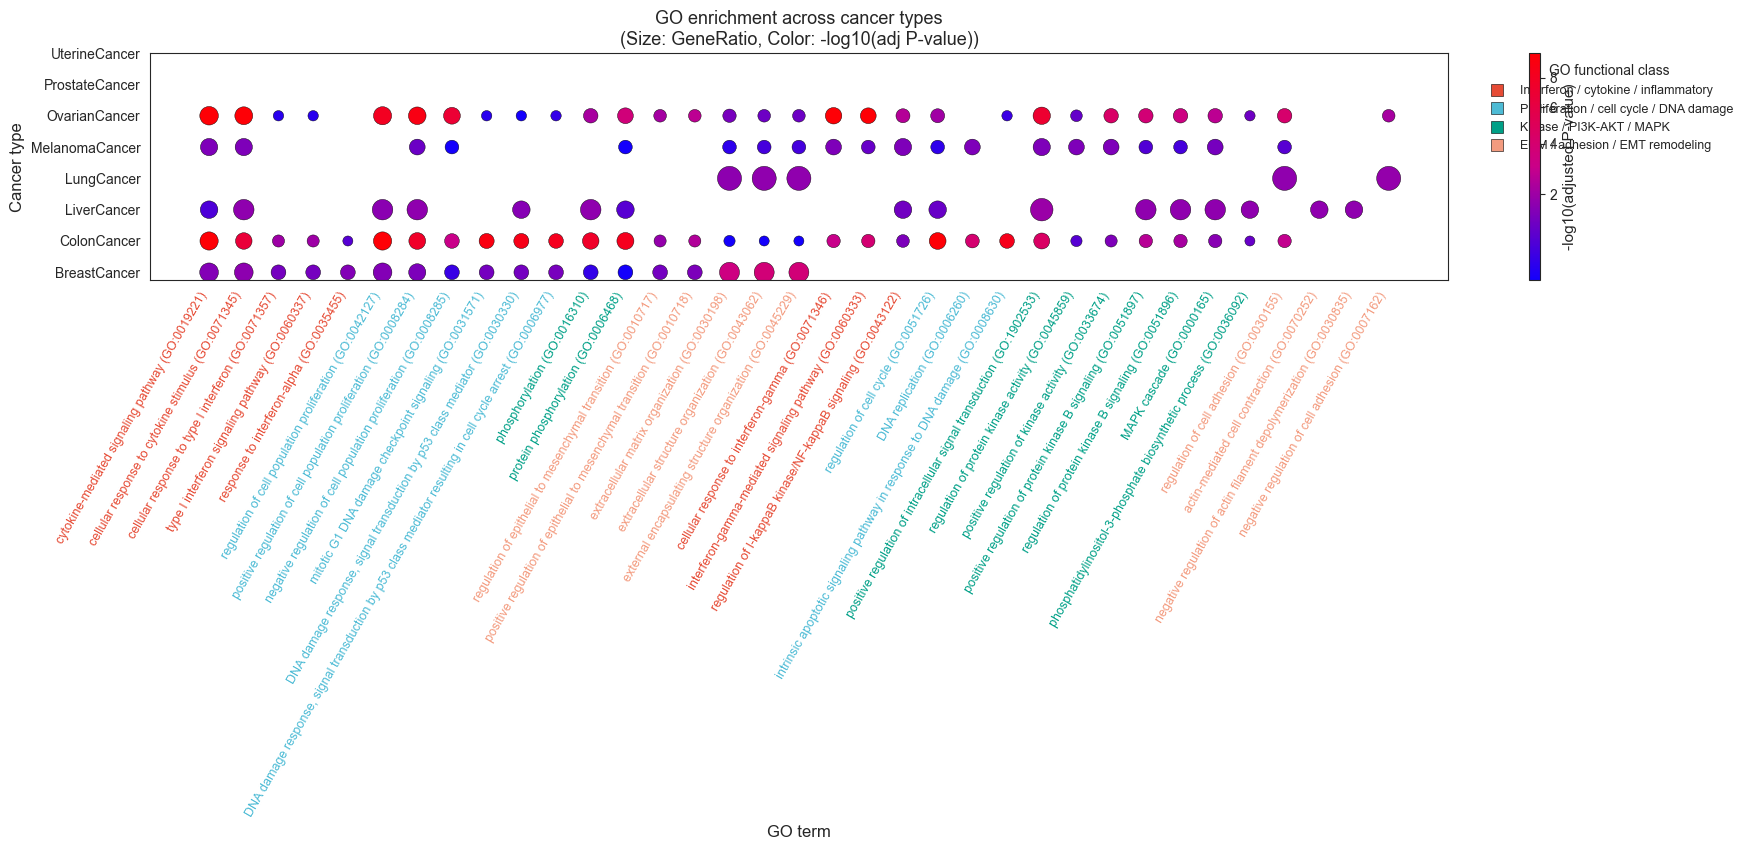

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from matplotlib.lines import Line2D

# =========================
# GO class color mapping
# =========================
class_colors = {
    "Interferon_cytokine_inflammatory": "#E64B35",    # red
    "Proliferation_cell_cycle_DNA_damage": "#4DBBD5", # blue
    "Kinase_PI3K_AKT_MAPK_signaling": "#00A087",      # green
    "ECM_adhesion_EMT_remodeling": "#F39B7F"          # orange
}

# =========================
# Build GO_term -> class mapping
# =========================
go_to_class = {}
for cls, go_list in representative_GO_by_class.items():
    for go in go_list:
        go_to_class[go] = cls

# =========================
# Custom colormap
# =========================
custom_cmap = LinearSegmentedColormap.from_list(
    "BluePurpleRed",
    ["#1400FC", "#CA0089", "#FE0006"]
)

# =========================
# Use plotting dataframe only for points
# =========================
df_plot = plot_df_plot.copy()

if df_plot.empty:
    raise ValueError("No valid GO enrichment points are available for plotting.")

# =========================
# Size scaling (sqrt, display only)
# =========================
size_vals = np.sqrt(df_plot["GeneRatio"].values)

if np.nanmax(size_vals) == 0:
    size_scaled = np.full_like(size_vals, fill_value=size_min, dtype=float)
else:
    size_scaled = size_min + (size_vals / np.nanmax(size_vals)) * (size_max - size_min)

# =========================
# Color scaling (sqrt via PowerNorm)
# =========================
norm = PowerNorm(
    gamma=0.5,
    vmin=vmin,
    vmax=vmax
)

# =========================
# Figure size based on the full structure
# =========================
fig_width = 0.4 * plot_df["GO_term"].nunique() + 4
fig_height = 0.7 * plot_df["CancerType"].nunique() + 3

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# =========================
# Scatter plot (keep original plotting logic)
# =========================
sc = ax.scatter(
    x=df_plot["GO_term"],
    y=df_plot["CancerType"],
    s=size_scaled,
    c=df_plot["neglog10_pval"],
    cmap=custom_cmap,
    norm=norm,
    edgecolor="black",
    linewidth=0.3
)

# =========================
# Colorbar
# =========================
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("-log10(adjusted P-value)", fontsize=11)

# =========================
# Axes formatting
# =========================
ax.set_yticks(np.arange(len(geneRatio_mat.index)))
ax.set_yticklabels(geneRatio_mat.index, fontsize=10)

plt.setp(ax.get_xticklabels(), rotation=60, ha="right", fontsize=9)

ax.set_xlabel("GO term", fontsize=12)
ax.set_ylabel("Cancer type", fontsize=12)
ax.set_title(
    "GO enrichment across cancer types\n"
    "(Size: GeneRatio, Color: -log10(adj P-value))",
    fontsize=13
)

# =========================
# IMPORTANT:
# Draw first, then color x-axis labels without changing order
# =========================
fig.canvas.draw()

for label in ax.get_xticklabels():
    go_name = label.get_text()
    if go_name in go_to_class:
        label.set_color(class_colors[go_to_class[go_name]])
    else:
        label.set_color("gray")

# =========================
# Legend for GO class colors
# =========================
legend_labels_pretty = {
    "Interferon_cytokine_inflammatory": "Interferon / cytokine / inflammatory",
    "Proliferation_cell_cycle_DNA_damage": "Proliferation / cell cycle / DNA damage",
    "Kinase_PI3K_AKT_MAPK_signaling": "Kinase / PI3K-AKT / MAPK",
    "ECM_adhesion_EMT_remodeling": "ECM / adhesion / EMT remodeling"
}

legend_elements = [
    Line2D(
        [0], [0],
        marker="s",
        linestyle="",
        markersize=8,
        markerfacecolor=color,
        markeredgecolor="black",
        markeredgewidth=0.4,
        label=legend_labels_pretty[cls]
    )
    for cls, color in class_colors.items()
]

ax.legend(
    handles=legend_elements,
    title="GO functional class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

# =========================
# Save and show
# =========================
plt.tight_layout()
plt.savefig(
    f"{file_savepath_main}/GO_enrichment_summary_dotplot_BothPosUp_"
    f"{ct1_cur}-{ct2_cur}-{ct3_cur}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [55]:
import os

save_dir = f"{file_savepath_main}/GO_summary_for_R"
os.makedirs(save_dir, exist_ok=True)

# =========================
# 1. Save the long-format dataframe (most important output).
# =========================
plot_df_save = plot_df.copy()

plot_df_save.to_csv(
    f"{save_dir}/plot_df_long.csv",
    index=False
)

# =========================
# 2. Save. GeneRatio matrix
# =========================
geneRatio_mat.to_csv(
    f"{save_dir}/geneRatio_mat.csv"
)

# =========================
# 3. Save. p-value matrix
# =========================
pval_mat.to_csv(
    f"{save_dir}/pval_mat.csv"
)

# =========================
# 4. Save the GO-term order (strongly recommended).
# =========================
pd.DataFrame({
    "GO_term": geneRatio_mat.columns
}).to_csv(
    f"{save_dir}/GO_term_order.csv",
    index=False
)

# =========================
# 5. Save the CancerType order (also recommended).
# =========================
pd.DataFrame({
    "CancerType": geneRatio_mat.index
}).to_csv(
    f"{save_dir}/CancerType_order.csv",
    index=False
)

print(f"✅ GO summary data saved to: {save_dir}")

✅ GO summary data saved to: D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//GO_summary_for_R


#### Optional analysis: GO enrichment of genes downregulated in the cascade group

In [ ]:
##GO enrichment for each cancer type
##Downregulated genes in BothPos versus OnlyMIsecond.
for ct in cancertype_unique:
    print(f"Processing GO enrichment for cancer type: {ct}...")
    deg_save_path_ct = f"{file_savepath_main}/DEG_mal_cells_BothPos_vs_OnlyMIsecond_{ct1_cur}-{ct2_cur}-{ct3_cur}_{ct}.csv"
    # ------------------------
    deg_df = pd.read_csv(deg_save_path_ct)
    
    # Common filter: genes upregulated in BothPos with significant adjusted p-values.
    # deg_down = deg_df[(deg_df["logfoldchanges"] > 0) & (deg_df["pvals_adj"] < 0.05)].copy()
    deg_down = deg_df[(deg_df["logfoldchanges"] < -0.2) & (deg_df["pvals_adj"] < 0.05)].copy()
    if deg_down.shape[0]==0:
        print(f"❗ No downregulated genes for BothPos in {ct}, skipping GO enrichment.")
        continue
    
    # Optional: add an effect-size threshold for a more conservative selection.
    # deg_down = deg_down[deg_down["logfoldchanges"] > 0.25]
    
    down_genes = deg_down["names"].dropna().astype(str).unique().tolist()
    print(f"#downregulated genes in BothPos: {len(down_genes)}")
    
    import gseapy as gp
    
    # Organism: use Human here; switch to Mouse for mouse datasets.
    organism = "Human"
    
    outdir = f"{file_savepath_main}/GO_enrichment_down_BothPos_{ct1_cur}-{ct2_cur}-{ct3_cur}_{ct}"
    
    enr = gp.enrichr(
        gene_list=down_genes,
        gene_sets=["GO_Biological_Process_2021"],  # alternatively use "GO_Molecular_Function_2021" or "GO_Cellular_Component_2021"
        organism=organism,
        outdir=outdir,
        cutoff=0.05
    )
    
    # Result table
    go_res = enr.results.sort_values("Adjusted P-value")
    go_path = f"{file_savepath_main}/GO_enrichment_down_BothPos_{ct1_cur}-{ct2_cur}-{ct3_cur}_{ct}.csv"
    go_res.to_csv(go_path, index=False)
    print(f"[Saved GO results] {go_path}")
    
    
    import matplotlib.pyplot as plt
    
    # Built-in gseapy barplot
    gp.barplot(
        enr.res2d,
        column="Adjusted P-value",
        title=f"GO BP enrichment (BothPos down) {ct1_cur}-{ct2_cur}-{ct3_cur}",
        top_term=20,
        figsize=(6, 6)
    )
    plt.tight_layout()
    fig_path = f"{file_savepath_main}/GO_barplot_down_BothPos_{ct1_cur}-{ct2_cur}-{ct3_cur}_{ct}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    # plt.show()
    plt.close()
    print(f"[Saved plot] {fig_path}")

### Step 7. Gene-level summaries for selected representative GO programs

These cells extract genes from manually selected representative GO terms and summarize gene-level expression shifts across cancer types.

In [62]:
GO_representative_list = [
        # 1. Interferon / cytokine / inflammatory signaling axis
        "cytokine-mediated signaling pathway (GO:0019221)",
        "cellular response to cytokine stimulus (GO:0071345)",
        "interferon-gamma-mediated signaling pathway (GO:0060333)",
    
    # 2. Proliferation / cell-cycle / DNA-damage checkpoint axis
        "positive regulation of cell population proliferation (GO:0008284)",
        "mitotic G1 DNA damage checkpoint signaling (GO:0031571)",
        "DNA damage response, signal transduction by p53 class mediator (GO:0030330)",

    # 3. Kinase / PI3K-AKT / MAPK / signal-transduction axis
        "positive regulation of intracellular signal transduction (GO:1902533)",
        "regulation of protein kinase B signaling (GO:0051896)",
        "MAPK cascade (GO:0000165)",
    # 4. ECM remodeling / adhesion / EMT-like remodeling axis
        "extracellular matrix organization (GO:0030198)",
        "extracellular structure organization (GO:0043062)",
        "external encapsulating structure organization (GO:0045229)"
]

In [63]:
import matplotlib.pyplot as plt
from scipy.stats import ranksums
groups_use = ("BothPos", "OnlyMIsecond")
prefer_layer = "lognorm"          # ✅ Use lognorm for DEG / fold-change calculations.
min_cells_per_group = 10          # Skip comparisons with too few cells (adjustable).
pseudocount = 1e-12               # avoid log10(0)
top_genes_per_term = None         # Set this to 30/50 to limit the number of genes per term; None uses all genes.

# Order of cancer types (you may also use the unique order from the records).
cancer_order = [
    'Breast', 'Colon', 'Liver', 'Lung', 'Melanoma', 'Ovarian', 'Prostate', 'Uterine'
]

# -----------------------------
# 1) Extract the genes associated with each GO term from go_res.
#    Assumes go_res = enr.results.sort_values("Adjusted P-value").
# -----------------------------
def parse_genes(s):
    if pd.isna(s):
        return []
    s = str(s).strip()
    if not s:
        return []
    if ";" in s:
        parts = s.split(";")
    elif "," in s:
        parts = s.split(",")
    else:
        parts = s.split()
    return [p.strip() for p in parts if p.strip()]

def get_gene_col(df):
    for c in ["Genes", "genes", "Gene", "gene"]:
        if c in df.columns:
            return c
    return None

gene_col = get_gene_col(go_res)
assert gene_col is not None, f"Cannot find genes column in go_res. Columns: {list(go_res.columns)}"
assert "Term" in go_res.columns, f"Cannot find 'Term' column in go_res. Columns: {list(go_res.columns)}"

term2genes = {}
for term in GO_representative_list:
    hit = go_res[go_res["Term"] == term]
    if hit.shape[0] == 0:
        term2genes[term] = []
    else:
        genes = parse_genes(hit.iloc[0][gene_col])
        if top_genes_per_term is not None:
            genes = genes[:top_genes_per_term]
        term2genes[term] = genes

print("GO representative -> #genes")
for t in GO_representative_list:
    print(t, ":", len(term2genes[t]))

GO representative -> #genes
cytokine-mediated signaling pathway (GO:0019221) : 19
cellular response to cytokine stimulus (GO:0071345) : 16
interferon-gamma-mediated signaling pathway (GO:0060333) : 9
positive regulation of cell population proliferation (GO:0008284) : 15
mitotic G1 DNA damage checkpoint signaling (GO:0031571) : 1
DNA damage response, signal transduction by p53 class mediator (GO:0030330) : 1
positive regulation of intracellular signal transduction (GO:1902533) : 14
regulation of protein kinase B signaling (GO:0051896) : 6
MAPK cascade (GO:0000165) : 6
extracellular matrix organization (GO:0030198) : 4
extracellular structure organization (GO:0043062) : 3
external encapsulating structure organization (GO:0045229) : 3


In [64]:
# -----------------------------
# Comment translated to English in this reorganized notebook.
# -----------------------------
def _get_expr_matrix(adata, prefer_layer="lognorm"):
    if prefer_layer is not None and hasattr(adata, "layers") and prefer_layer in adata.layers:
        return adata.layers[prefer_layer]
    return adata.X

def collect_expr_for_group_cancer(adata_list, mal_cells_records, group, cancertype, genes, prefer_layer="lognorm"):
    """
    Return a dict mapping each gene to all cell-level expression values for the specified cancer type and group (1D numpy array).
    Assumes mal_cells_records[group] stores sample_index, cell_id, and cancertype.
    """
    recs = mal_cells_records.get(group, [])
    if len(recs) == 0:
        return {g: np.array([]) for g in genes}

    df = pd.DataFrame(recs)
    df = df[df["cancertype"] == cancertype]
    if df.shape[0] == 0:
        return {g: np.array([]) for g in genes}

    expr_by_gene = {g: [] for g in genes}

    for si, sub in df.groupby("sample_index"):
        si = int(si)
        ad = adata_list[si]
        ids = sub["cell_id"].tolist()

        # Find the genes that are present in the current sample.
        genes_present = [g for g in genes if g in ad.var_names]
        if len(genes_present) == 0:
            continue

        ad_sub = ad[ids, genes_present]
        X = _get_expr_matrix(ad_sub, prefer_layer=prefer_layer)

        # Convert to a dense matrix (appropriate here because the number of genes is small).
        if hasattr(X, "toarray"):
            X = X.toarray()

        for j, g in enumerate(genes_present):
            expr_by_gene[g].append(X[:, j].astype(float))

    # concat
    out = {}
    for g in genes:
        if len(expr_by_gene[g]) == 0:
            out[g] = np.array([])
        else:
            out[g] = np.concatenate(expr_by_gene[g], axis=0)
    return out

In [65]:
# 3) For each cancer type and gene, compute logFC and p-value.
# -----------------------------
# First collect all genes by concatenating them in GO-term order.
gene_blocks = []
for term in GO_representative_list:
    for g in term2genes[term]:
        gene_blocks.append((term, g))

# If some terms return no genes, they would create empty columns; filter them out here.
gene_blocks = [(t, g) for (t, g) in gene_blocks if g is not None and g != ""]
all_genes_ordered = [g for (_, g) in gene_blocks]

print(f"Total genes for dotplot: {len(all_genes_ordered)}")

# Cancer-type list: use the user-defined order when possible (the records may contain labels such as Breast / Colon / ...).
# If the cancertype labels in the records are values such as "Breast": 
all_cts = sorted(pd.DataFrame(mal_cells_records["BothPos"]).get("cancertype", pd.Series([])).unique().tolist())
# Sort by cancer_order and place unmatched labels at the end.
def _ct_sort_key(x):
    return (cancer_order.index(x) if x in cancer_order else 999, x)
cancertypes = sorted(list(set(all_cts)), key=_ct_sort_key)
print("Cancer types:", cancertypes)

rows = []
for ct in cancertypes:
    expr_both = collect_expr_for_group_cancer(adata_list, mal_cells_records, "BothPos", ct, all_genes_ordered, prefer_layer=prefer_layer)
    expr_only = collect_expr_for_group_cancer(adata_list, mal_cells_records, "OnlyMIsecond", ct, all_genes_ordered, prefer_layer=prefer_layer)

    for term, gene in gene_blocks:
        x = expr_both.get(gene, np.array([]))
        y = expr_only.get(gene, np.array([]))

        if (len(x) < min_cells_per_group) or (len(y) < min_cells_per_group):
            logfc = np.nan
            pval = np.nan
        else:
            # Under lognorm / log1p data, use the difference in means as logFC for a more stable estimate.
            logfc = float(np.mean(x) - np.mean(y))
            _, pval = ranksums(x, y)  # two-sided

        rows.append({
            "cancertype": ct,
            "GO_term": term,
            "gene": gene,
            "logFC": logfc,
            "pval": pval
        })

df_stats = pd.DataFrame(rows)
df_stats["neglog10p"] = -np.log10(df_stats["pval"].clip(lower=pseudocount))
stats_save = f"{file_savepath_main}/Dotplot_GOgenes_BothPos_vs_OnlyMIsecond_{ct1_cur}-{ct2_cur}-{ct3_cur}.csv"
df_stats.to_csv(stats_save, index=False)
print(f"[Saved stats] {stats_save}")

Total genes for dotplot: 97
Cancer types: ['BreastCancer', 'ColonCancer', 'LiverCancer', 'LungCancer', 'MelanomaCancer', 'OvarianCancer', 'ProstateCancer', 'UterineCancer']
[Saved stats] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Dotplot_GOgenes_BothPos_vs_OnlyMIsecond_Fibroblast-cancercell-cancercell.csv


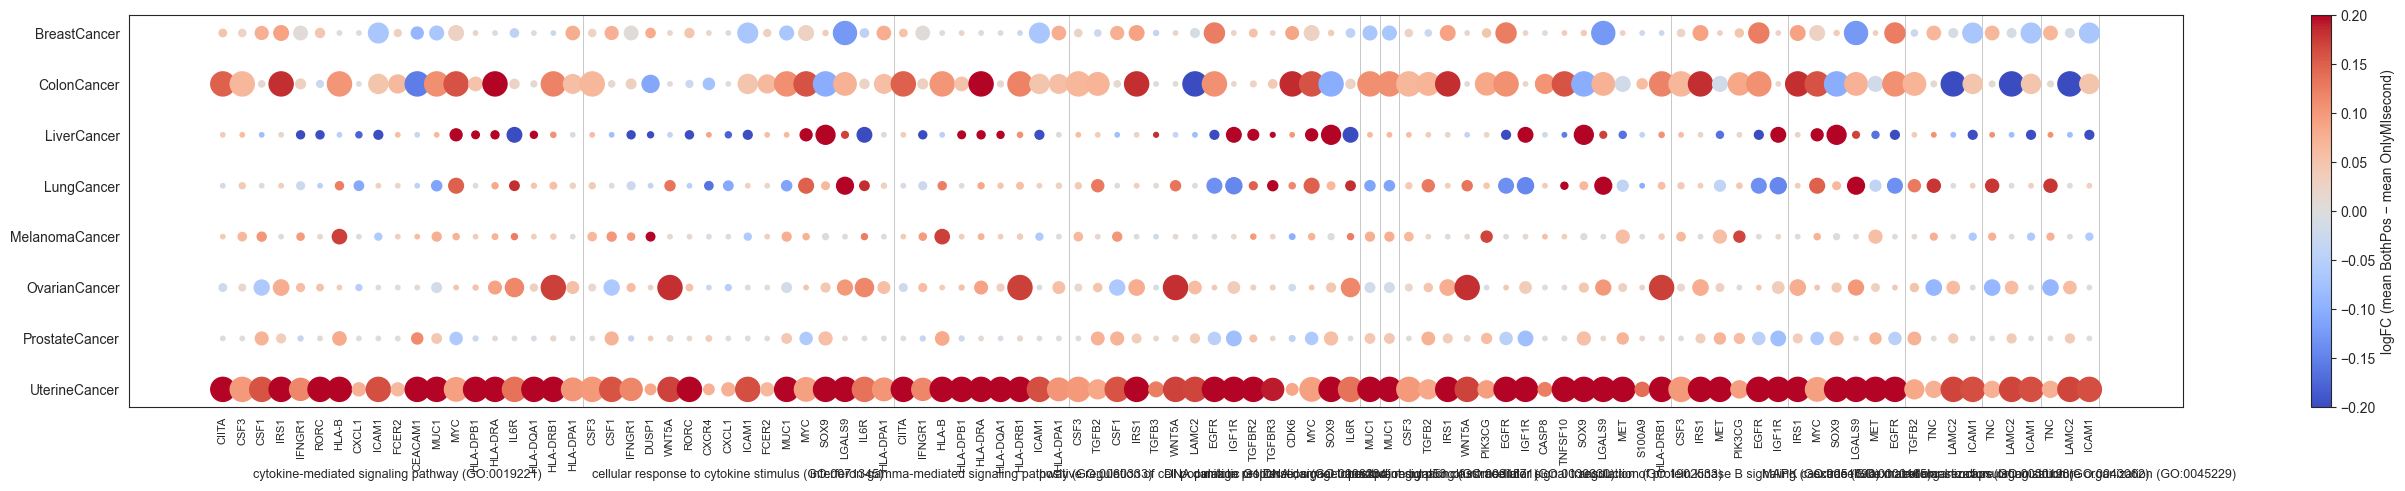

[Saved dotplot] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Dotplot_GOgenes_BothPos_vs_OnlyMIsecond_Fibroblast-cancercell-cancercell.png


In [66]:
x_blocks = [(str(t).strip(), str(g).strip()) for (t, g) in gene_blocks]
y_labels = [str(ct).strip() for ct in cancertypes]

# Remove duplicates while preserving order (rare, but safe).
x_blocks = list(dict.fromkeys(x_blocks))
y_labels = list(dict.fromkeys(y_labels))

# Comment translated to English in this reorganized notebook.
x_pos = {i: i for i in range(len(x_blocks))}
y_pos = {ct: i for i, ct in enumerate(y_labels)}

# -----------------------------
# 2) Prepare df_stats.
# -----------------------------
plot_df = df_stats.copy()
plot_df["gene"] = plot_df["gene"].astype(str).str.strip()
plot_df["GO_term"] = plot_df["GO_term"].astype(str).str.strip()
plot_df["cancertype"] = plot_df["cancertype"].astype(str).str.strip()

# Keep only the (GO_term, gene) pairs that appear in gene_blocks.
plot_df = plot_df[
    plot_df.set_index(["GO_term", "gene"]).index.isin(x_blocks) &
    plot_df["cancertype"].isin(y_labels)
][["cancertype", "GO_term", "gene", "logFC", "neglog10p"]]

# -----------------------------
# 3) Aggregate first to ensure that each (cancertype, GO_term, gene) combination is unique.
# -----------------------------
plot_df = (
    plot_df
    .groupby(["cancertype", "GO_term", "gene"], as_index=False)
    .agg(
        logFC=("logFC", "mean"),
        neglog10p=("neglog10p", "mean")
    )
)

# -----------------------------
# 4) Complete the full grid of cancer type × (GO_term, gene).
# -----------------------------
full_index = pd.MultiIndex.from_product(
    [y_labels, x_blocks],
    names=["cancertype", "xblock"]
)

plot_df = (
    plot_df
    .assign(xblock=list(zip(plot_df["GO_term"], plot_df["gene"])))
    .set_index(["cancertype", "xblock"])
    .reindex(full_index)
    .reset_index()
)

# Split the combined key back into GO_term and gene.
plot_df[["GO_term", "gene"]] = pd.DataFrame(
    plot_df["xblock"].tolist(), index=plot_df.index
)
plot_df.drop(columns="xblock", inplace=True)

# Fill missing values using the intended semantics.
plot_df["logFC"] = plot_df["logFC"].astype(float).fillna(0.0)
plot_df["neglog10p"] = plot_df["neglog10p"].astype(float).fillna(0.0)

# -----------------------------
# 5) size / color（NaN-safe）
# -----------------------------
size_scale = 25.0
plot_df["logFC_plot"] = plot_df["logFC"]
plot_df["size_plot"] = np.maximum(plot_df["neglog10p"] * size_scale, 10.0)

# -----------------------------
# 6) Map categories to numeric coordinates.
# -----------------------------
# The x coordinate is the position in x_blocks.
x_index_map = {blk: i for i, blk in enumerate(x_blocks)}
plot_df["x"] = plot_df.apply(
    lambda r: x_index_map[(r["GO_term"], r["gene"])], axis=1
)
plot_df["y"] = plot_df["cancertype"].map(y_pos)

# -----------------------------
# 7) Plot the figure.
# -----------------------------
fig_w = max(10, 0.28 * len(x_blocks))
fig_h = max(5, 0.35 * len(y_labels))
plt.figure(figsize=(fig_w, fig_h))

plt.scatter(
    plot_df["x"],
    plot_df["y"],
    c=plot_df["logFC_plot"],
    s=plot_df["size_plot"],
    cmap="coolwarm",
    vmin=-0.2,
    vmax=0.2,
    zorder=3
)

plt.colorbar(
    label="logFC (mean BothPos − mean OnlyMIsecond)"
)

# x- and y-axis labels
plt.xticks(
    range(len(x_blocks)),
    [g for (_, g) in x_blocks],
    rotation=90,
    fontsize=8
)
plt.yticks(
    range(len(y_labels)),
    y_labels,
    fontsize=10
)

# -----------------------------
# 8) GO-term block separators and labels.
# -----------------------------
boundaries = []
term_names = []
start = 0

for term in GO_representative_list:
    genes_t = [(t, g) for (t, g) in x_blocks if t == term]
    if len(genes_t) == 0:
        continue
    end = start + len(genes_t)
    boundaries.append((start, end))
    term_names.append(term)
    plt.axvline(end - 0.5, color="k", lw=0.5, alpha=0.3, zorder=1)
    start = end

for (start, end), term in zip(boundaries, term_names):
    mid = (start + end - 1) / 2
    plt.text(
        mid,
        len(y_labels) + 0.8,
        term,
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.gca().invert_yaxis()
plt.tight_layout()

# -----------------------------
# 9) Save.
# -----------------------------
dot_path = (
    f"{file_savepath_main}/"
    f"Dotplot_GOgenes_BothPos_vs_OnlyMIsecond_"
    f"{ct1_cur}-{ct2_cur}-{ct3_cur}.png"
)

plt.savefig(dot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"[Saved dotplot] {dot_path}")

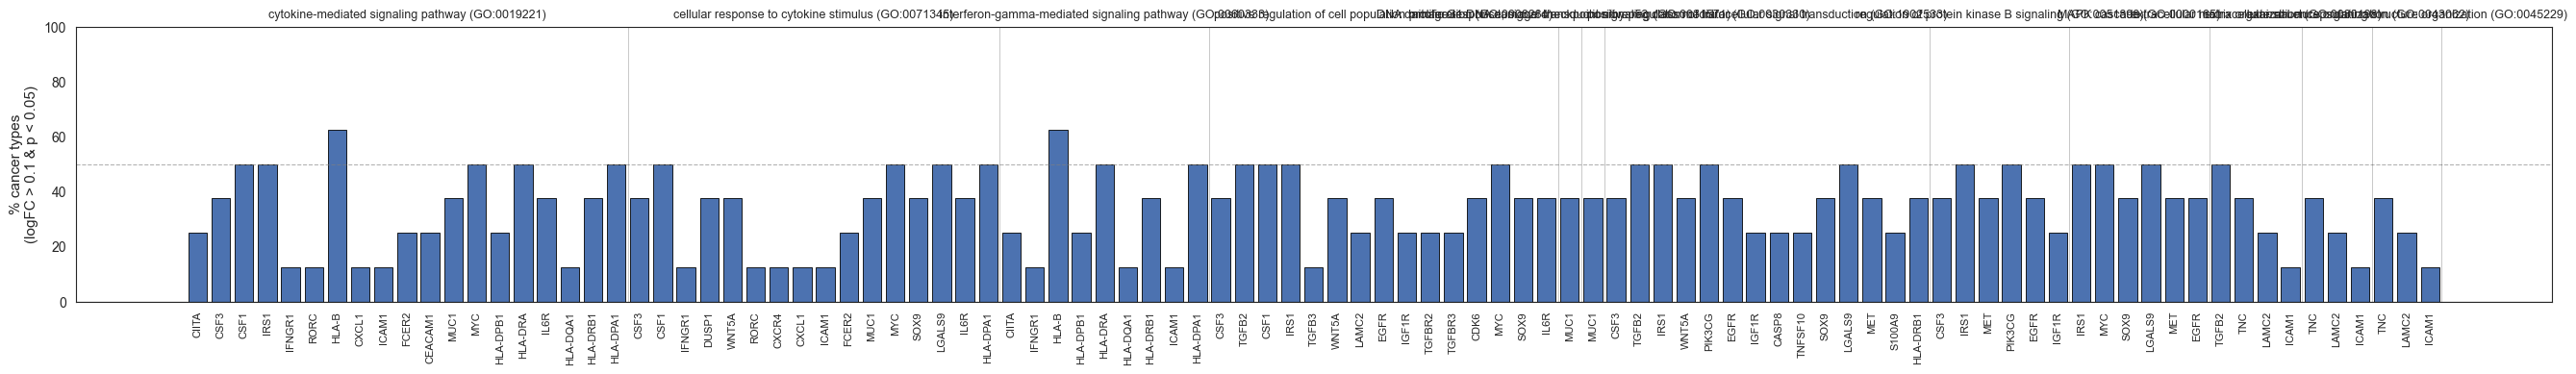

[Saved barplot] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Barplot_GOgenes_PosSigPct_Fibroblast-cancercell-cancercell.png


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Define thresholds.
# -----------------------------
# logFC_thresh = 0.1
logFC_thresh = 0.05
neglog10p_thresh = -np.log10(0.05)  # ≈ 1.301

# -----------------------------
# 2) Mark whether the effect is significantly positive.
# -----------------------------
plot_df["is_sig_pos"] = (
    (plot_df["logFC"] > logFC_thresh) &
    (plot_df["neglog10p"] > neglog10p_thresh)
)

# Total number of cancer types, used as the denominator.
n_cancer = plot_df["cancertype"].nunique()

# -----------------------------
# 3) Compute the percentage for each (GO_term, gene) pair.
# -----------------------------
summary_df = (
    plot_df
    .groupby(["GO_term", "gene"], as_index=False)
    .agg(
        n_sig=("is_sig_pos", "sum"),
        pct_sig=("is_sig_pos", lambda x: 100.0 * x.sum() / n_cancer)
    )
)

# -----------------------------
# 4) Sort by gene_blocks order to keep the same order as the dotplot.
# -----------------------------
block_order = [(str(t).strip(), str(g).strip()) for (t, g) in gene_blocks]
order_map = {blk: i for i, blk in enumerate(block_order)}

summary_df["order"] = summary_df.apply(
    lambda r: order_map.get((r["GO_term"], r["gene"]), np.nan),
    axis=1
)
summary_df = summary_df.sort_values("order")

# -----------------------------
# Comment translated to English in this reorganized notebook.
# -----------------------------
fig_w = max(10, 0.28 * len(summary_df))
fig_h = 4
plt.figure(figsize=(fig_w, fig_h))

plt.bar(
    range(len(summary_df)),
    summary_df["pct_sig"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.6
)

plt.axhline(0, color="black", lw=0.8)
plt.ylim(0, 100)

plt.ylabel("% cancer types\n(logFC > 0.1 & p < 0.05)", fontsize=11)

plt.xticks(
    range(len(summary_df)),
    summary_df["gene"],
    rotation=90,
    fontsize=8
)
##Add a line: y = 0.50 to the figure
plt.axhline(
    y=50,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.6
)


# -----------------------------
# Comment translated to English in this reorganized notebook.
# -----------------------------
boundaries = []
term_names = []
start = 0

for term in GO_representative_list:
    genes_t = [
        g for (t, g) in block_order if t == term
        if ((summary_df["GO_term"] == t) & (summary_df["gene"] == g)).any()
    ]
    if len(genes_t) == 0:
        continue
    end = start + len(genes_t)
    boundaries.append((start, end))
    term_names.append(term)
    plt.axvline(end - 0.5, color="k", lw=0.5, alpha=0.3)
    start = end

for (start, end), term in zip(boundaries, term_names):
    mid = (start + end - 1) / 2
    plt.text(
        mid,
        102,
        term,
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

# -----------------------------
# 7) Save.
# -----------------------------
bar_path = (
    f"{file_savepath_main}/"
    f"Barplot_GOgenes_PosSigPct_"
    f"{ct1_cur}-{ct2_cur}-{ct3_cur}.png"
)

plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"[Saved barplot] {bar_path}")

#### Optional sensitivity analysis after excluding selected cancer types

# cancer types used = 8
Cancer types: ['BreastCancer' 'ColonCancer' 'LiverCancer' 'LungCancer' 'MelanomaCancer'
 'OvarianCancer' 'ProstateCancer' 'UterineCancer']


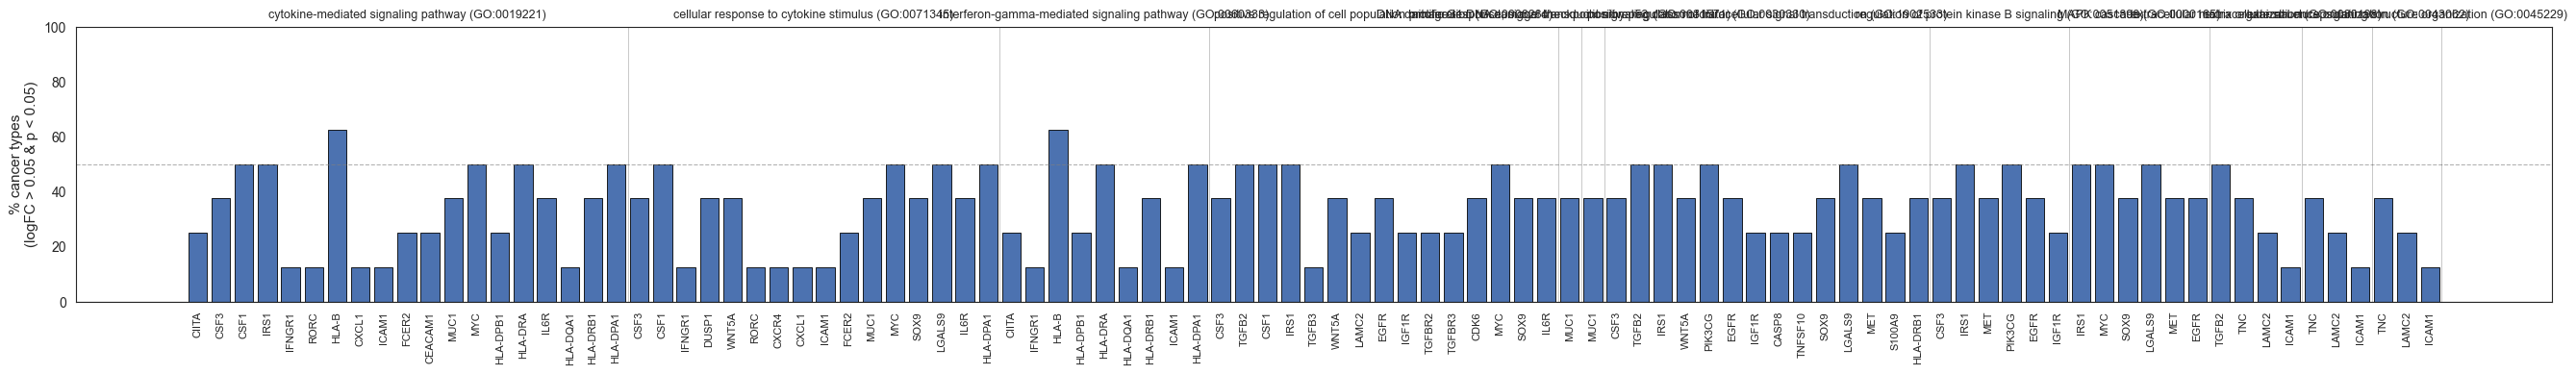

[Saved barplot] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Barplot_GOgenes_PosSigPct_Fibroblast-cancercell-cancercell_choose.png


In [68]:

# ============================================================
# Comment translated to English in this reorganized notebook.
# ============================================================
exclude_cancers = [
    "HumanLungCancerPatient1",
    "HumanMelanomaCancerPatient1"
]

plot_df = plot_df[~plot_df["cancertype"].isin(exclude_cancers)].copy()

# ============================================================
# 1) Define thresholds.
# ============================================================
logFC_thresh = 0.05
neglog10p_thresh = -np.log10(0.05)  # ≈ 1.301

# ============================================================
# 2) Mark whether the effect is significantly positive.
# ============================================================
plot_df["is_sig_pos"] = (
    (plot_df["logFC"] > logFC_thresh) &
    (plot_df["neglog10p"] > neglog10p_thresh)
)

# Comment translated to English in this reorganized notebook.
n_cancer = plot_df["cancertype"].nunique()

print(f"# cancer types used = {n_cancer}")
print("Cancer types:", plot_df["cancertype"].unique())

# ============================================================
# 3) Compute the percentage for each (GO_term, gene) pair.
# ============================================================
summary_df = (
    plot_df
    .groupby(["GO_term", "gene"], as_index=False)
    .agg(
        n_sig=("is_sig_pos", "sum"),
        pct_sig=("is_sig_pos", lambda x: 100.0 * x.sum() / n_cancer)
    )
)

# ============================================================
# 4) Sort by gene_blocks order to keep the same order as the dotplot.
# ============================================================
block_order = [(str(t).strip(), str(g).strip()) for (t, g) in gene_blocks]
order_map = {blk: i for i, blk in enumerate(block_order)}

summary_df["order"] = summary_df.apply(
    lambda r: order_map.get((r["GO_term"], r["gene"]), np.nan),
    axis=1
)
summary_df = summary_df.sort_values("order")

# ============================================================
# Comment translated to English in this reorganized notebook.
# ============================================================
fig_w = max(10, 0.28 * len(summary_df))
fig_h = 4
plt.figure(figsize=(fig_w, fig_h))

plt.bar(
    range(len(summary_df)),
    summary_df["pct_sig"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.6
)

plt.axhline(0, color="black", lw=0.8)
plt.ylim(0, 100)

plt.ylabel("% cancer types\n(logFC > 0.05 & p < 0.05)", fontsize=11)

plt.xticks(
    range(len(summary_df)),
    summary_df["gene"],
    rotation=90,
    fontsize=8
)

# ============================================================
# 5.5) Add a 50% reference line.
# ============================================================
plt.axhline(
    y=50,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.6
)

# ============================================================
# Comment translated to English in this reorganized notebook.
# ============================================================
boundaries = []
term_names = []
start = 0

for term in GO_representative_list:
    genes_t = [
        g for (t, g) in block_order if t == term
        if ((summary_df["GO_term"] == t) & (summary_df["gene"] == g)).any()
    ]
    if len(genes_t) == 0:
        continue
    end = start + len(genes_t)
    boundaries.append((start, end))
    term_names.append(term)
    plt.axvline(end - 0.5, color="k", lw=0.5, alpha=0.3)
    start = end

for (start, end), term in zip(boundaries, term_names):
    mid = (start + end - 1) / 2
    plt.text(
        mid,
        102,
        term,
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

# ============================================================
# 7) Save.
# ============================================================
bar_path = (
    f"{file_savepath_main}/"
    f"Barplot_GOgenes_PosSigPct_"
    f"{ct1_cur}-{ct2_cur}-{ct3_cur}_choose.png"
)

plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"[Saved barplot] {bar_path}")

### Step 8. Plot LR-level, CAF, and functional-state differences between triplet groups

In [69]:
###############################################################
# 5. Statistical comparison and visualization
###############################################################
from scipy.stats import ranksums
import matplotlib.pyplot as plt

def p_to_star(p):
    return "****" if p < 1e-4 else "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "n.s."

def plot_box(data_dict, ylabel, title_prefix, filename_prefix):
    for p in pathways:
        pname = pathway1_chose_merge if p == "pathway1" else pathway2_chose_merge
        groups_all = {
            "MI cascade": data_dict[p]["BothPos"],
            "MI-first only": data_dict[p]["OnlyMIfirst"],
            "MI-second only": data_dict[p]["OnlyMIsecond"],
            "No MI": data_dict[p]["BothNeg"]
        }

        groups = {
            "MI cascade model": groups_all["MI cascade"],
            # "Non-cascaded model": groups_all["MI-second only"]
            "Non-cascaded model1": groups_all["MI-second only"],
            "Non-cascaded model2": groups_all["MI-first only"],
            "No MI": groups_all["No MI"]
        }
        tick_labels, data = list(groups.keys()), list(groups.values())
        # colors = ["#FFE2E2", "#99DDCC"]
        colors = ["#FFE2E2", "#99DDCC","#FFDD99","#CCCCCC"]

        plt.figure(figsize=(3, 4))
        box = plt.boxplot(data, tick_labels=tick_labels, patch_artist=True, showfliers=False)
        [b.set_facecolor(c) for b, c in zip(box['boxes'], colors)]

        # ------------------------
        # Use the upper whisker height of each box as ymax.
        # ------------------------
        whisker_tops = []
        for i in range(0, len(box["whiskers"]), 2):
            whisker_line = box["whiskers"][i + 1]   # upper whisker
            ydata = whisker_line.get_ydata()
            whisker_tops.append(max(ydata))
        ymax = max(whisker_tops)
        ymin = min([min(d) for d in data])
        yspan = ymax - ymin if ymax > ymin else 1e-6
        plt.ylim(ymin - 0.05 * yspan, ymax + 0.25 * yspan)

        # ------------------------
        # Statistical test
        # ------------------------
        _, pval = ranksums(data[0], data[1], alternative="greater")
        sig_text = p_to_star(pval)
        plt.text(1.5, ymax + 0.1 * yspan, sig_text, ha="center", fontsize=12)
        ##
        _, pval_2 = ranksums(data[0], data[2], alternative="greater")
        sig_text_2 = p_to_star(pval_2)
        plt.text(2, ymax + 0.15 * yspan, sig_text_2, ha="center", fontsize=12)
        ##
        _, pval_3 = ranksums(data[0], data[3], alternative="greater")
        sig_text_3 = p_to_star(pval_3)
        plt.text(2.5, ymax + 0.2 * yspan, sig_text_3, ha="center", fontsize=12)

        # ------------------------
        # Style & save
        # ------------------------
        plt.ylabel(ylabel, fontsize=12)
        plt.title(f"{title_prefix}: {pname}", fontsize=12)
        plt.tight_layout()

        fname = f"{file_savepath_main}/{p}_{filename_prefix}_{pname}_{ct1_cur}-{ct2_cur}-{ct3_cur}.png"
        plt.savefig(fname, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

In [70]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
group_pos = "BothPos"
group_neg = "OnlyMIsecond"

vals_pos = np.asarray(LRStrength_pathwayagg_all["pathway2"][group_pos])
vals_neg = np.asarray(LRStrength_pathwayagg_all["pathway2"][group_neg])

ct_pos = np.asarray(LRStrength_pathwayagg_all_cancertype["pathway2"][group_pos])
ct_neg = np.asarray(LRStrength_pathwayagg_all_cancertype["pathway2"][group_neg])
cancer_types = np.unique(
    np.concatenate([ct_pos, ct_neg])
)

results = []

eps = 1e-9  #  log(0)

for ct in cancer_types:
    # Extract the data for the current cancer type.
    v_pos_ct = vals_pos[ct_pos == ct]
    v_neg_ct = vals_neg[ct_neg == ct]

    # Require at least some data.
    if (len(v_pos_ct) < 3) or (len(v_neg_ct) < 3):
        logfc = np.nan
        pval = np.nan
    else:
        # log fold change
        logfc = np.log2(
            (np.mean(v_pos_ct) + eps) /
            (np.mean(v_neg_ct) + eps)
        )

        # Wilcoxon rank-sum
        _, pval = mannwhitneyu(
            v_pos_ct,
            v_neg_ct,
            alternative="two-sided"
        )

    results.append({
        "CancerType": ct,
        "logFC": logfc,
        "pval": pval
    })
res_df = pd.DataFrame(results)

# Apply FDR correction to non-missing p-values only.
mask = res_df["pval"].notna()

res_df.loc[mask, "pval_adj"] = multipletests(
    res_df.loc[mask, "pval"],
    method="fdr_bh"
)[1]

print(res_df)

##Save the res_df as csv
res_savepath = f"{file_savepath_main}/LRStrength_pathway2_BothPos_vs_OnlyMIsecond_by_cancertype_{ct1_cur}-{ct2_cur}-{ct3_cur}.csv"
res_df.to_csv(res_savepath, index=False)


       CancerType     logFC          pval      pval_adj
0    BreastCancer  0.133834  1.476849e-04  3.938264e-04
1     ColonCancer  0.117413  1.052588e-07  4.210352e-07
2     LiverCancer  0.024388  2.368526e-01  3.158035e-01
3      LungCancer  0.468444  2.240147e-03  3.584235e-03
4  MelanomaCancer -0.157037  4.891281e-01  4.891281e-01
5   OvarianCancer  0.278201  2.052370e-15  1.641896e-14
6  ProstateCancer -0.107444  1.759520e-03  3.519041e-03
7   UterineCancer -0.022304  4.580181e-01  4.891281e-01


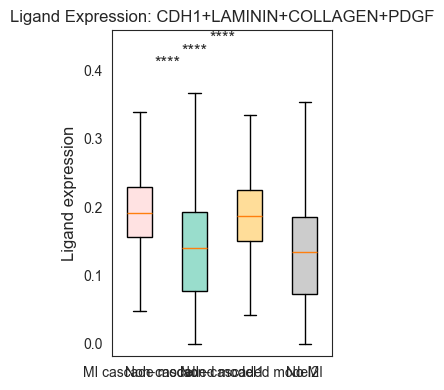

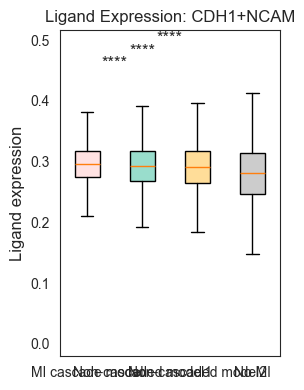

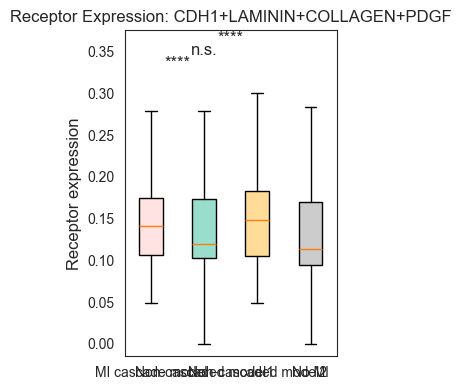

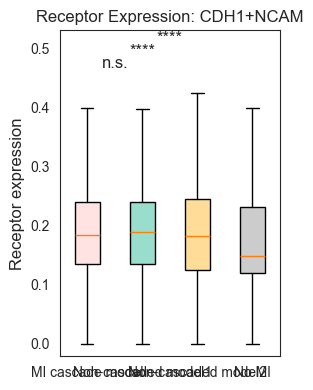

In [71]:
# Plot the ligand and receptor expression boxplots
plot_box(Ligandexpression_pathwayagg_all, "Ligand expression", "Ligand Expression", "Ligand")
plot_box(Receptorexpression_pathwayagg_all, "Receptor expression", "Receptor Expression", "Receptor")

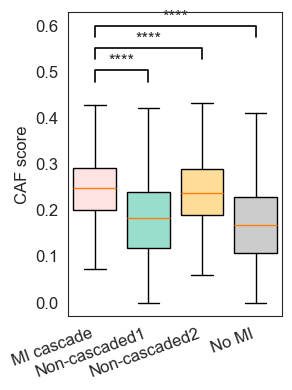

In [72]:
# Plot the CAF score boxplot
plt.figure(figsize=(3, 4))
# data = [CAFscore_all["BothPos"], CAFscore_all["OnlyMIsecond"]]
data = [CAFscore_all["BothPos"], CAFscore_all["OnlyMIsecond"],CAFscore_all["OnlyMIfirst"],CAFscore_all["BothNeg"]]
# tick_labels = ["MI cascade", "Non-cascaded"]
tick_labels = ["MI cascade", "Non-cascaded1","Non-cascaded2","No MI"]
# colors = ["#FFE2E2", "#99DDCC"]
colors = ["#FFE2E2", "#99DDCC","#FFDD99","#CCCCCC"]

# Draw the boxplot (use 'tick_labels' instead of 'labels' for Matplotlib ≥3.9)
box = plt.boxplot(data, tick_labels=tick_labels, patch_artist=True, showfliers=False, widths=0.8)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Add significance annotation
_, pval = ranksums(data[0], data[1], alternative="greater")
ymax = max([max(v) if len(v) > 0 else 0 for v in data]) * 1.05
plt.plot([1, 1, 2, 2], [ymax, ymax * 1.05, ymax * 1.05, ymax], lw=1.2, c="k")
plt.text(1.5, ymax * 1.07, p_to_star(pval), ha="center", fontsize=12)
##
_, pval_2 = ranksums(data[0], data[2], alternative="greater")
plt.plot([1, 1, 3, 3], [ymax*1.1, ymax * 1.15, ymax * 1.15, ymax*1.1], lw=1.2, c="k")
plt.text(2, ymax * 1.17, p_to_star(pval_2), ha="center", fontsize=12)
##
_, pval_3 = ranksums(data[0], data[3], alternative="greater")
plt.plot([1, 1, 4, 4], [ymax*1.2, ymax * 1.25, ymax * 1.25, ymax*1.2], lw=1.2, c="k")
plt.text(2.5, ymax * 1.27, p_to_star(pval_3), ha="center", fontsize=12)



# Axis labels and layout
plt.ylabel("CAF score", fontsize=12)
plt.xticks(fontsize=12, rotation=20, ha="right")
plt.yticks(fontsize=12)
plt.tight_layout()

# Save and display
plt.savefig(file_savepath_main + f"/CAFscore_{ct1_cur}-{ct2_cur}-{ct3_cur}.png", dpi=300)
plt.show()
plt.close()

In [73]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
group_pos = "BothPos"
group_neg = "OnlyMIsecond"

vals_pos = np.asarray(CAFscore_all[group_pos])
vals_neg = np.asarray(CAFscore_all[group_neg])

ct_pos = np.asarray(CAFscore_all_cancertype[group_pos])
ct_neg = np.asarray(CAFscore_all_cancertype[group_neg])
cancer_types = np.unique(
    np.concatenate([ct_pos, ct_neg])
)

results = []

eps = 1e-9  #  log(0)

for ct in cancer_types:
    v_pos_ct = vals_pos[ct_pos == ct]
    v_neg_ct = vals_neg[ct_neg == ct]

    if (len(v_pos_ct) < 3) or (len(v_neg_ct) < 3):
        logfc = np.nan
        pval = np.nan
    else:
        # log2 fold change (CAFscore)
        logfc = np.log2(
            (np.mean(v_pos_ct) + eps) /
            (np.mean(v_neg_ct) + eps)
        )

        # Wilcoxon rank-sum test
        _, pval = mannwhitneyu(
            v_pos_ct,
            v_neg_ct,
            alternative="two-sided"
        )

    results.append({
        "CancerType": ct,
        "logFC": logfc,
        "pval": pval
    })
res_df = pd.DataFrame(results)

mask = res_df["pval"].notna()
res_df.loc[mask, "pval_adj"] = multipletests(
    res_df.loc[mask, "pval"],
    method="fdr_bh"
)[1]

print(res_df)
##Save the res_df as csv
res_savepath = f"{file_savepath_main}/CAFscore_pathway2_BothPos_vs_OnlyMIsecond_by_cancertype_{ct1_cur}-{ct2_cur}-{ct3_cur}.csv"
print(res_savepath)
res_df.to_csv(res_savepath, index=False)

       CancerType     logFC           pval       pval_adj
0    BreastCancer  0.733391   0.000000e+00   0.000000e+00
1     ColonCancer  0.382893   0.000000e+00   0.000000e+00
2     LiverCancer  0.333659   3.779308e-09   3.779308e-09
3      LungCancer  0.687455   2.750213e-54   3.666951e-54
4  MelanomaCancer  0.479734   4.976232e-49   5.687123e-49
5   OvarianCancer  0.273633   1.932719e-85   3.092351e-85
6  ProstateCancer  0.651965   0.000000e+00   0.000000e+00
7   UterineCancer  0.241336  1.182918e-230  2.365837e-230
D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//CAFscore_pathway2_BothPos_vs_OnlyMIsecond_by_cancertype_Fibroblast-cancercell-cancercell.csv


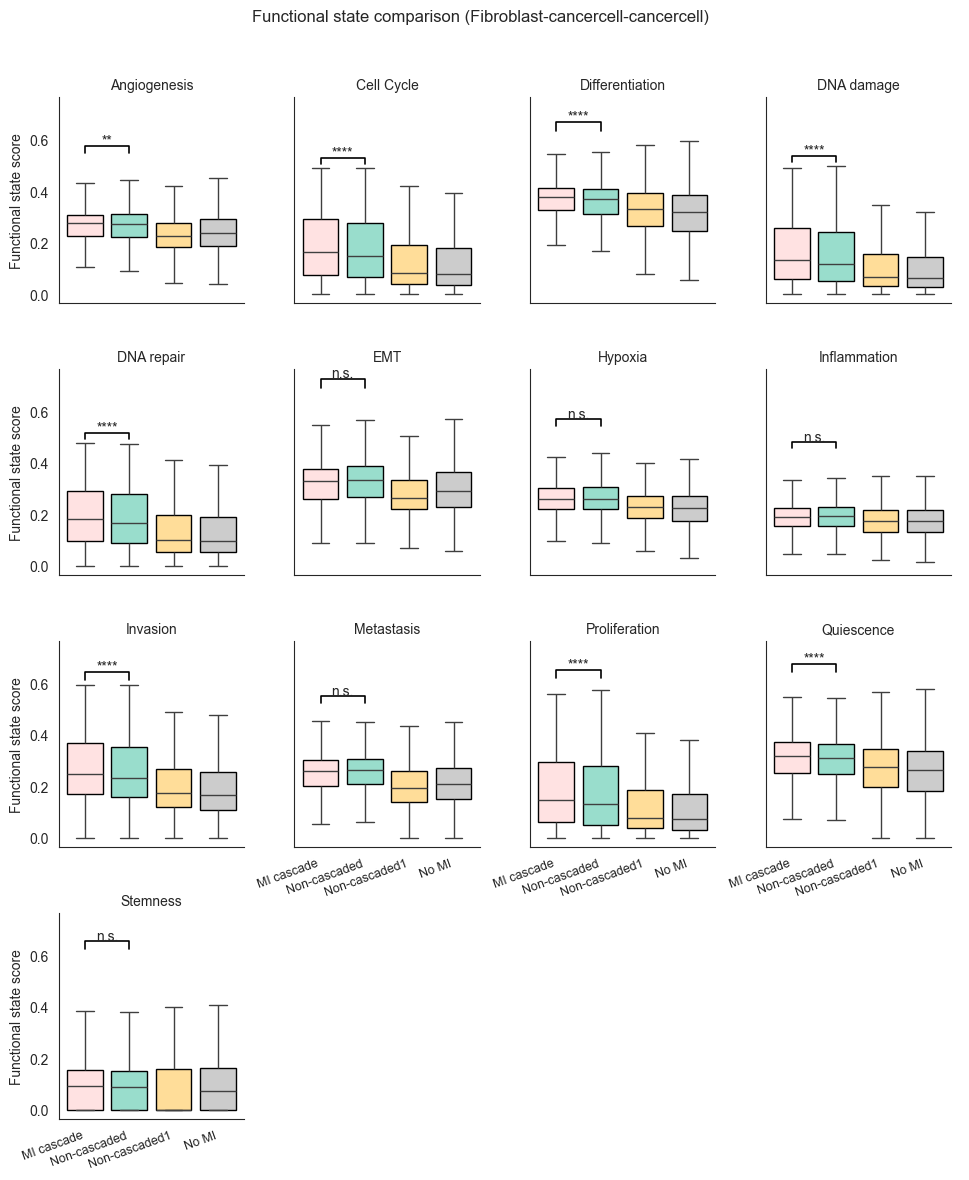

In [74]:
# ============================================
# Plot the functional state boxplots
# ============================================
records = [
    {"group": g, "geneset": gs, "value": v}
    for g, d in Functionalstate_all.items()
    for gs, vals in d.items()
    for v in vals
]
df_plot = pd.DataFrame(records)

# Define order and colors
# order = ["BothPos", "OnlyMIsecond"]
order = ["BothPos", "OnlyMIsecond","OnlyMIfirst","BothNeg"]
# pretty_labels = {"BothPos": "MI cascade", "OnlyMIsecond": "Non-cascaded"}
pretty_labels = {"BothPos": "MI cascade", "OnlyMIsecond": "Non-cascaded",
                 "OnlyMIfirst": "Non-cascaded1","BothNeg":"No MI"}
# fill_colors = ["#FFE2E2", "#99DDCC"]
fill_colors = ["#FFE2E2", "#99DDCC","#FFDD99","#CCCCCC"]

# Create facet boxplots per geneset
g = sns.catplot(
    data=df_plot, x="group", y="value", col="geneset",
    kind="box", order=order, showfliers=False,
    col_wrap=4, height=3, aspect=0.8,
    boxprops={'facecolor': 'white', 'edgecolor': 'black'}
)

# Apply consistent colors to all boxes
for ax in g.axes.flatten():
    for i, patch in enumerate(ax.patches):
        patch.set_facecolor(fill_colors[i % len(fill_colors)])

# Perform Wilcoxon tests and annotate stars
for ax, geneset in zip(g.axes.flatten(), df_plot["geneset"].unique()):
    subdf = df_plot[df_plot["geneset"] == geneset]
    vals1 = subdf.loc[subdf["group"] == "BothPos", "value"]
    vals2 = subdf.loc[subdf["group"] == "OnlyMIsecond", "value"]
    if len(vals1) > 0 and len(vals2) > 0:
        _, pval = ranksums(vals1, vals2, alternative="greater")
        stars = p_to_star(pval)
        ymax = subdf["value"].max()
        h = ymax * 0.05
        ax.plot([0, 0, 1, 1], [ymax, ymax + h, ymax + h, ymax], lw=1.2, c="k")
        ax.text(0.5, ymax + h * 1.2, stars, ha="center", fontsize=10)

    # Explicitly set both ticks and labels
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([pretty_labels[o] for o in order],
                       rotation=20, ha="right", fontsize=9)
    ax.set_title(geneset, fontsize=10)


# Set global labels and layout
g.set_axis_labels("", "Functional state score")
g.fig.suptitle(f"Functional state comparison ({ct1_cur}-{ct2_cur}-{ct3_cur})", fontsize=12)
g.fig.tight_layout(rect=[0, 0, 1, 0.96])

# Save and show the figure
save_path = file_savepath_main + f"/Functionalstate_{ct1_cur}-{ct2_cur}-{ct3_cur}_withstats.png"
g.savefig(save_path, dpi=300)
plt.show()
plt.close()

In [75]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ranksums

# -----------------------------
# Comment translated to English in this reorganized notebook.
# -----------------------------
def upper_whisker(vals):
    vals = np.asarray(vals, dtype=float)
    if vals.size == 0:
        return np.nan
    q1, q3 = np.percentile(vals, [25, 75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    return np.max(vals[vals <= upper]) if np.any(vals <= upper) else np.max(vals)

# ============================================
# Plot functional state boxplots per ct1_cur and save
# ============================================
ct1_list = [
    'Breast-cancercell', 'Colon-cancercell', 'Liver-cancercell',
    'Lung-cancercell', 'Melanoma-cancercell', 'Ovarian-cancercell',
    'Prostate-cancercell', 'Uterine-cancercell'
]

# order = ["BothPos", "OnlyMIsecond"]
order = ["BothPos", "OnlyMIsecond","OnlyMIfirst","BothNeg"]
# pretty_labels = {"BothPos": "MI cascade", "OnlyMIsecond": "Non-cascaded"}
pretty_labels = {"BothPos": "MI cascade", "OnlyMIsecond": "Non-cascaded",
                 "OnlyMIfirst": "Non-cascaded1","BothNeg":"No MI"}
# fill_colors = ["#FFE2E2", "#99DDCC"]
fill_colors = ["#FFE2E2", "#99DDCC","#FFDD99","#CCCCCC"]

# Facet order for gene sets (optional, but gives more stable output).
geneset_order = list(functional_geneset_choose_geneindex_dict.keys())

for ct1_cur_temp in ct1_list:

    # -------- build records filtered by ct1_cur_temp --------
    records = []
    for g, d in Functionalstate_all.items():
        if g not in celltype_alignment_all:
            continue
        cts = celltype_alignment_all[g]  # aligned one-to-one with the values of each term

        for gs, vals in d.items():
            # vals and cts should have the same length, which should already be guaranteed upstream.
            n = min(len(vals), len(cts))
            for v, ct in zip(vals[:n], cts[:n]):
                if ct == ct1_cur_temp:
                    records.append({"group": g, "geneset": gs, "value": v})

    if len(records) == 0:
        print(f"[Skip] {ct1_cur_temp}: no matched cells in Functionalstate_all.")
        continue

    df_plot = pd.DataFrame(records)
    # Keep only the groups to be compared.
    df_plot = df_plot[df_plot["group"].isin(order)].copy()
    if df_plot.empty:
        print(f"[Skip] {ct1_cur_temp}: no data in groups {order}.")
        continue

    # -------- facet boxplots --------
    g = sns.catplot(
        data=df_plot, x="group", y="value", col="geneset",
        kind="box", order=order, showfliers=False,
        col_order=geneset_order,
        col_wrap=4, height=3, aspect=0.8
    )

    # apply consistent colors
    for ax in g.axes.flatten():
        for i, patch in enumerate(ax.patches):
            patch.set_facecolor(fill_colors[i % len(fill_colors)])
            patch.set_edgecolor("black")

    # stats + annotate + xticks
    for ax, geneset in zip(g.axes.flatten(), g.col_names):
        subdf = df_plot[df_plot["geneset"] == geneset]
        vals1 = subdf.loc[subdf["group"] == "BothPos", "value"].values
        vals2 = subdf.loc[subdf["group"] == "OnlyMIsecond", "value"].values

        if len(vals1) > 0 and len(vals2) > 0:
            _, pval = ranksums(vals1, vals2, alternative="greater")
            stars = p_to_star(pval)

            # Use the upper whisker as ymax to avoid annotation drift when showfliers=False.
            y1 = upper_whisker(vals1)
            y2 = upper_whisker(vals2)
            ymax = np.nanmax([y1, y2])

            ymin = np.nanmin(np.concatenate([vals1, vals2]))
            yspan = (ymax - ymin) if ymax > ymin else 1e-6
            h = yspan * 0.08

            ax.plot([0, 0, 1, 1], [ymax, ymax + h, ymax + h, ymax], lw=1.2, c="k")
            ax.text(0.5, ymax + h * 1.15, stars, ha="center", fontsize=10)

            # Tighten the y-axis range for a cleaner visual appearance (optional).
            ax.set_ylim(ymin - 0.05 * yspan, ymax + 0.25 * yspan)

        ax.set_xticks(range(len(order)))
        ax.set_xticklabels([pretty_labels[o] for o in order], rotation=20, ha="right", fontsize=9)
        ax.set_title(geneset, fontsize=10)

    g.set_axis_labels("", "Functional state score")
    g.fig.suptitle(
        f"Functional state comparison ({ct1_cur_temp})  ({ct1_cur_temp}-{ct2_cur}-{ct3_cur})",
        fontsize=12
    )
    g.fig.tight_layout(rect=[0, 0, 1, 0.96])

    # save
    safe_ct = ct1_cur_temp.replace("/", "_")
    save_path = f"{file_savepath_main}/Functionalstate_{safe_ct}_{ct1_cur_temp}-{ct2_cur}-{ct3_cur}_withstats.png"
    g.savefig(save_path, dpi=300)
    plt.close(g.fig)

    print(f"[Saved] {save_path}")

[Saved] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Functionalstate_Breast-cancercell_Breast-cancercell-cancercell-cancercell_withstats.png
[Saved] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Functionalstate_Colon-cancercell_Colon-cancercell-cancercell-cancercell_withstats.png
[Saved] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Functionalstate_Liver-cancercell_Liver-cancercell-cancercell-cancercell_withstats.png
[Saved] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Functionalstate_Lung-cancercell_Lung-cancercell-cancercell-cancercell_withstats.png
[Saved] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Functionalstate_Melanoma-cancercell_Melanoma-cancercell-cancercell-cancercell_withstats.png
[Saved] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Functionalstate_Ovarian-cancercell_Ovarian-cancercell-cancercell-cancercell_withstats.png
[Saved] D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11//Functionalst